In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

import classify_plots as cp

BASE = Path("/Users/leekaijen/t7ssd/featELA/")
PATHS = {d: BASE / f"dim{d}featELA" / "ela_classification_subsample.h5"
         for d in (2, 5, 10)}

df = cp.load_results(PATHS)      # tidy: one row per (dim, strategy, size, n_inst, n_runs)
df.head()

PATHS_MODIFIED = PATHS.copy()
PATHS_MODIFIED[2] = BASE / "dim2featELA" / "ela_classification_subsample_modified.h5"
df_modified = cp.load_results(PATHS_MODIFIED)

In [2]:
df_modified['n_features'].unique()

array([41, 45])

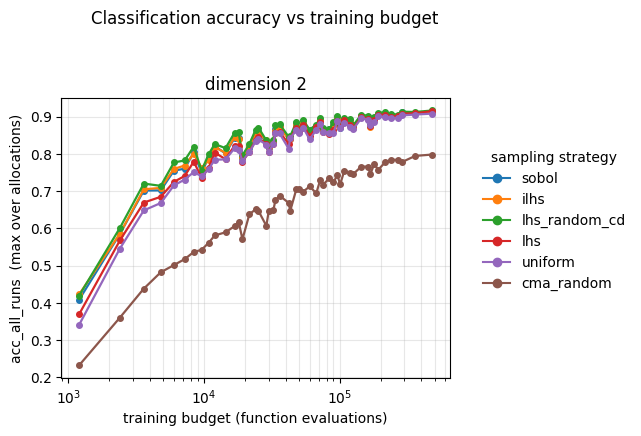

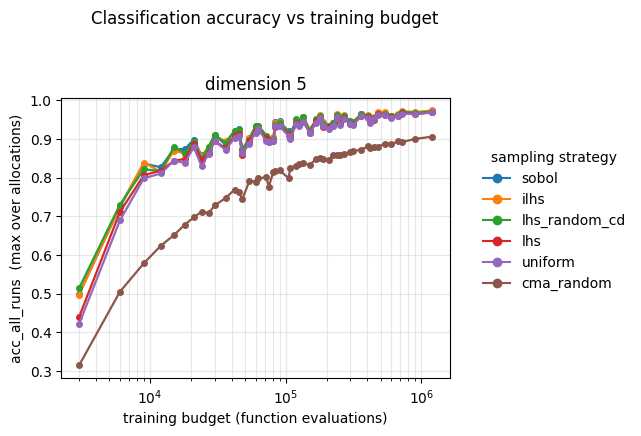

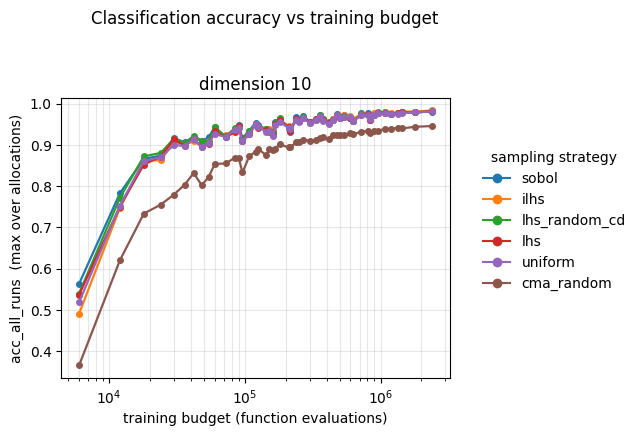

In [3]:
_ = cp.plot_accuracy_vs_budget(df, dimension=2)              # C1 — sampler comparison
_ = cp.plot_accuracy_vs_budget(df, dimension=5)
_ = cp.plot_accuracy_vs_budget(df, dimension=10)

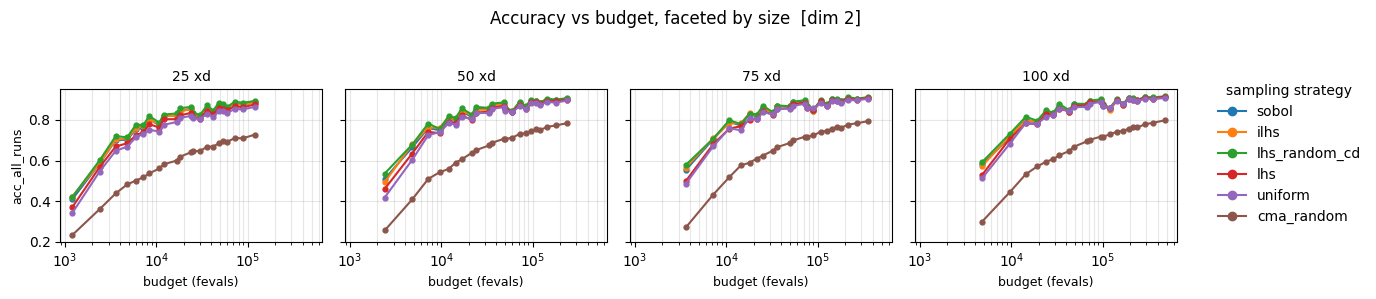

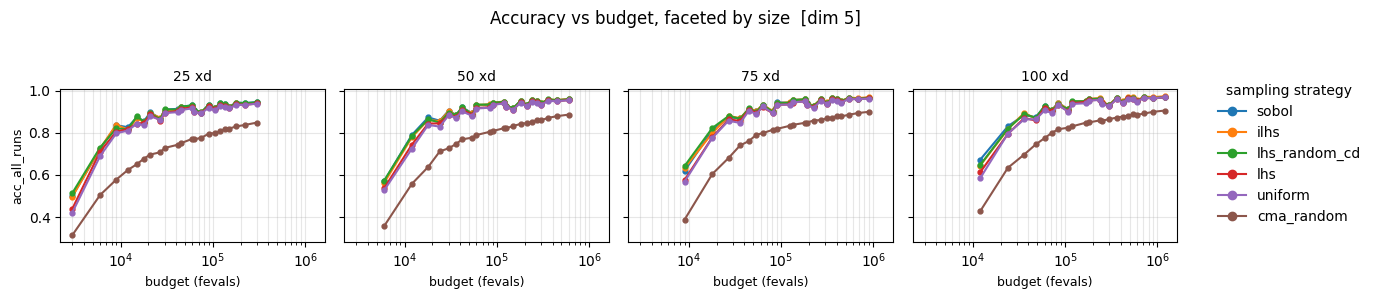

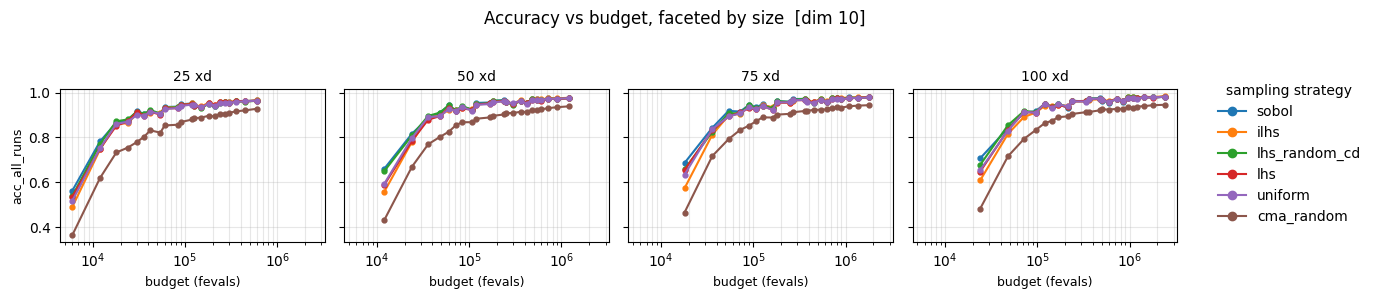

In [4]:
_ = cp.plot_accuracy_faceted(df, 2, facet_by="size")
_ = cp.plot_accuracy_faceted(df, 5, facet_by="size")
_ = cp.plot_accuracy_faceted(df, 10, facet_by="size")


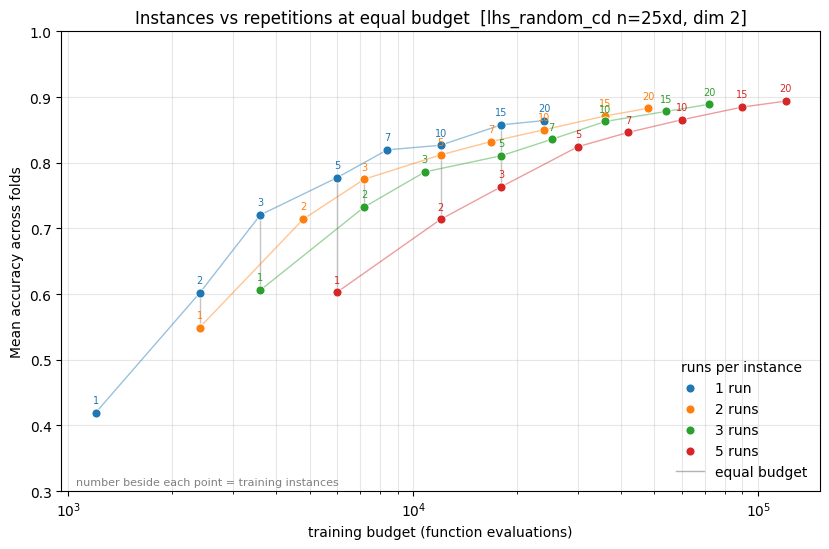

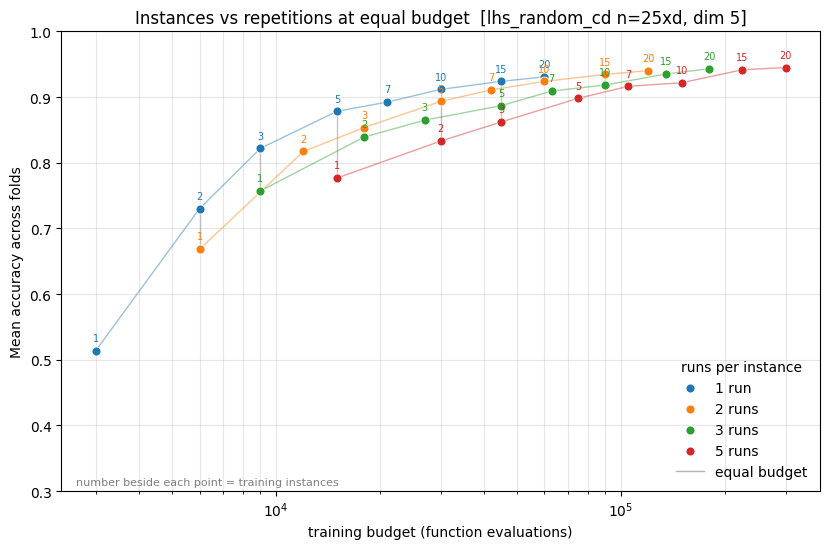

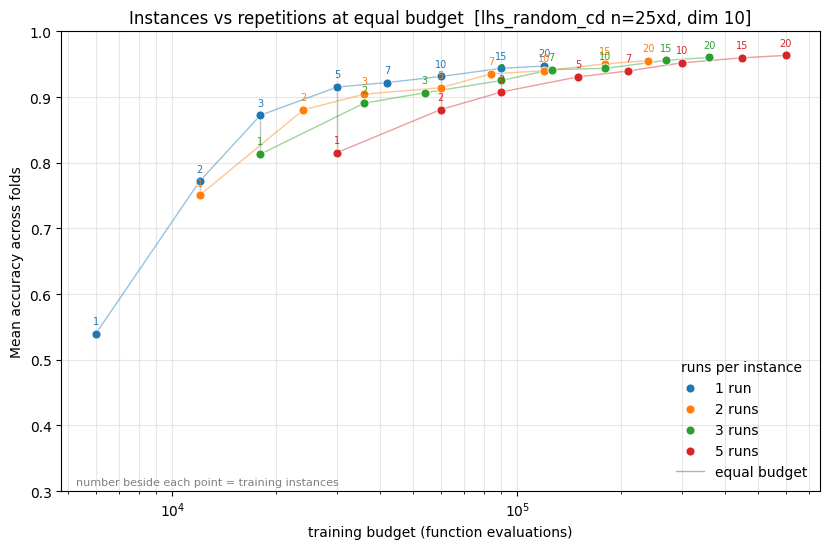

In [5]:
dimension = 10
sample_size = 25
ylim = (0.3, 1.0)

# _ = cp.plot_instances_vs_runs(df, dimension, "uniform", size=sample_size, ylim=ylim)      # C2 — THE budget question
# _ = cp.plot_instances_vs_runs(df, dimension, "sobol", size=sample_size, ylim=ylim)      # C2 — THE budget question
# _ = cp.plot_instances_vs_runs(df, dimension, "lhs", size=sample_size, ylim=ylim)      # C2 — THE budget question
# _ = cp.plot_instances_vs_runs(df, dimension, "ilhs", size=sample_size, ylim=ylim)      # C2 — THE budget question
# _ = cp.plot_instances_vs_runs(df, dimension, "lhs_random_cd", size=sample_size, ylim=ylim)      # C2 — THE budget question
# _ = cp.plot_instances_vs_runs(df, dimension, "cma_random", size=sample_size, ylim=ylim)      # C2 — THE budget question

_ = cp.plot_instances_vs_runs(df, 2, "lhs_random_cd", size=sample_size, ylim=ylim)      # C2 — THE budget question
_ = cp.plot_instances_vs_runs(df, 5, "lhs_random_cd", size=sample_size, ylim=ylim)      # C2 — THE budget question
_ = cp.plot_instances_vs_runs(df, 10, "lhs_random_cd", size=sample_size, ylim=ylim)      # C2 — THE budget question





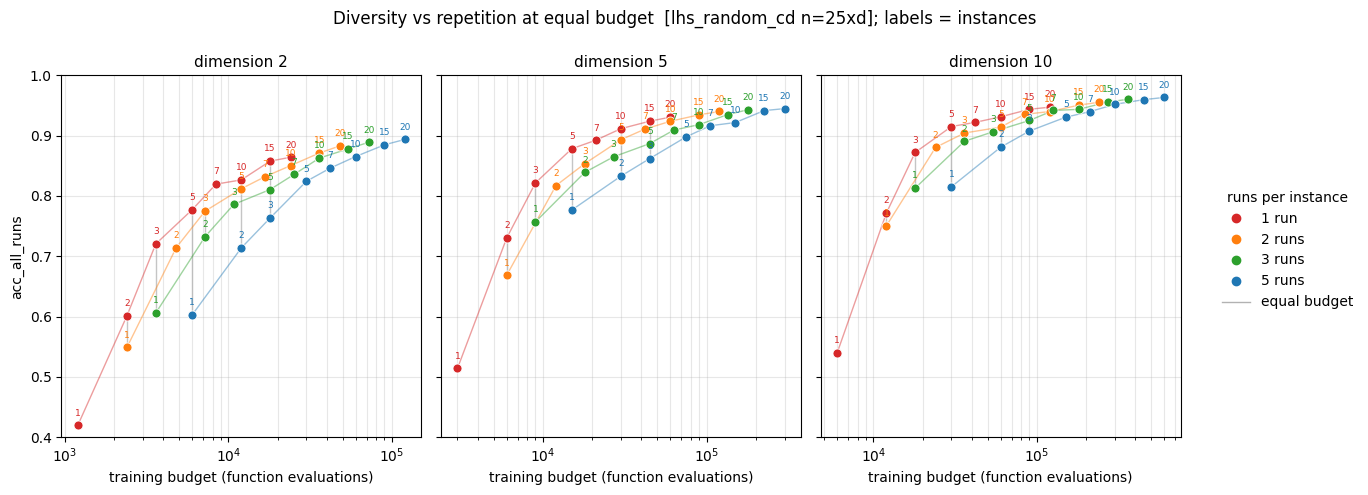

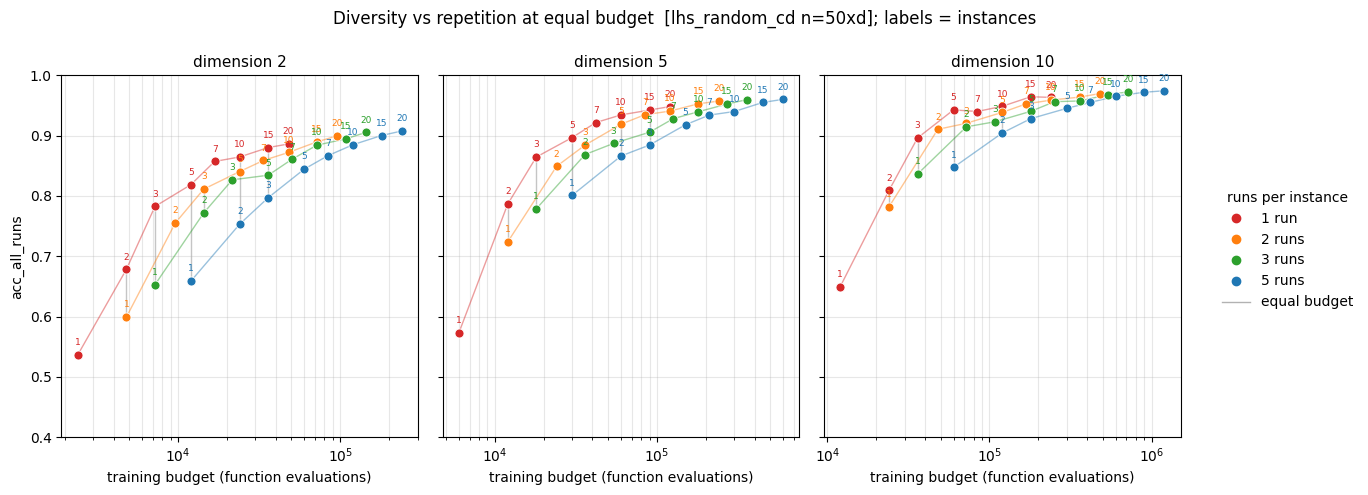

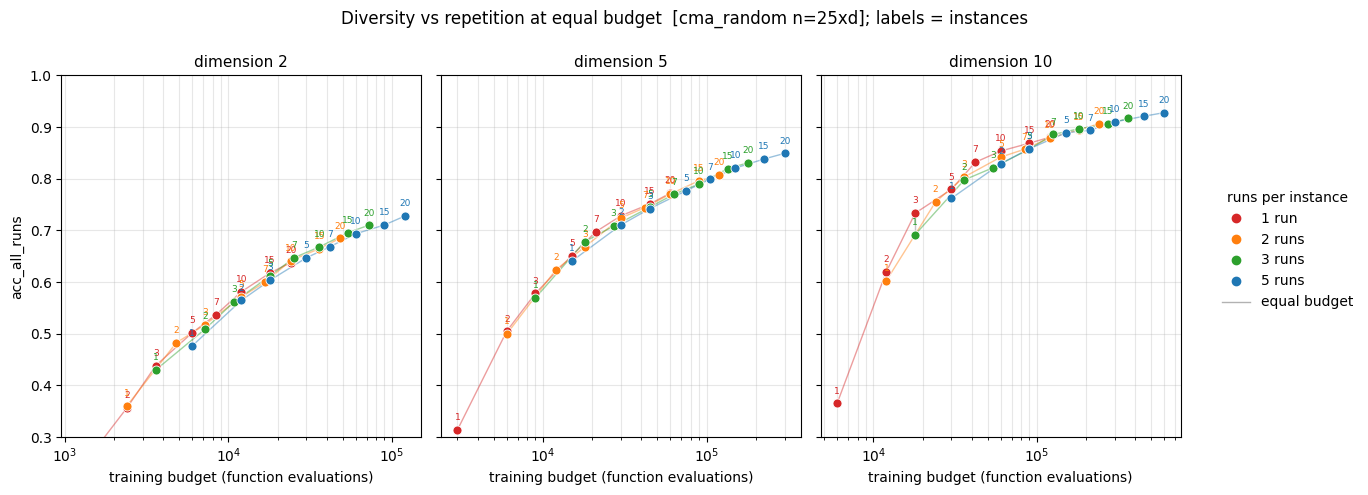

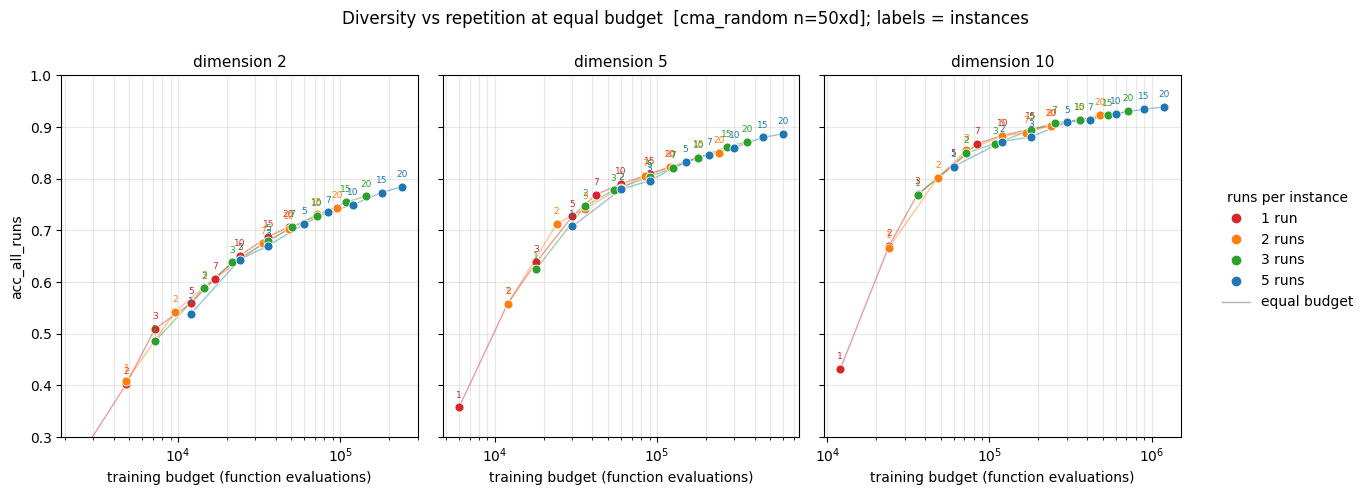

In [6]:
_ = cp.plot_instances_vs_runs_grid(df, dimensions=(2, 5, 10),
                                   strategy="lhs_random_cd",
                                   size=25, ylim=(0.4, 1.0))
_ = cp.plot_instances_vs_runs_grid(df, dimensions=(2, 5, 10),
                                   strategy="lhs_random_cd",
                                   size=50, ylim=(0.4, 1.0))

_ = cp.plot_instances_vs_runs_grid(df, dimensions=(2, 5, 10),
                                   strategy="cma_random",
                                   size=25, ylim=ylim)
_ = cp.plot_instances_vs_runs_grid(df, dimensions=(2, 5, 10),
                                   strategy="cma_random",
                                   size=50, ylim=ylim)

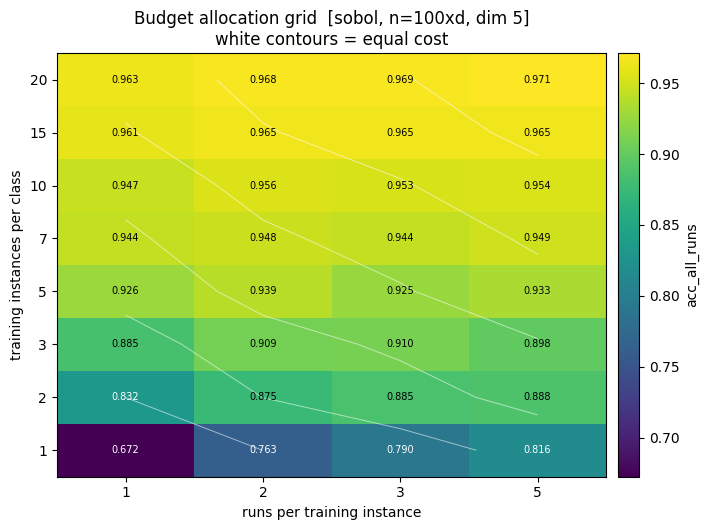

In [7]:
_ = cp.heatmap_grid(df, "sobol", 100, 5)                     # C3 — the full grid


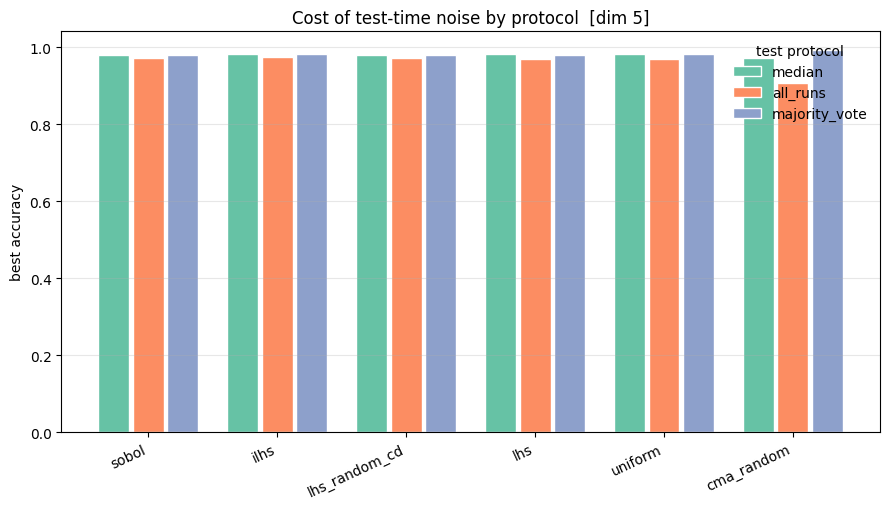

In [8]:
_ = cp.plot_protocols(df, dimension=5)                       # C4 — test-time noise cost


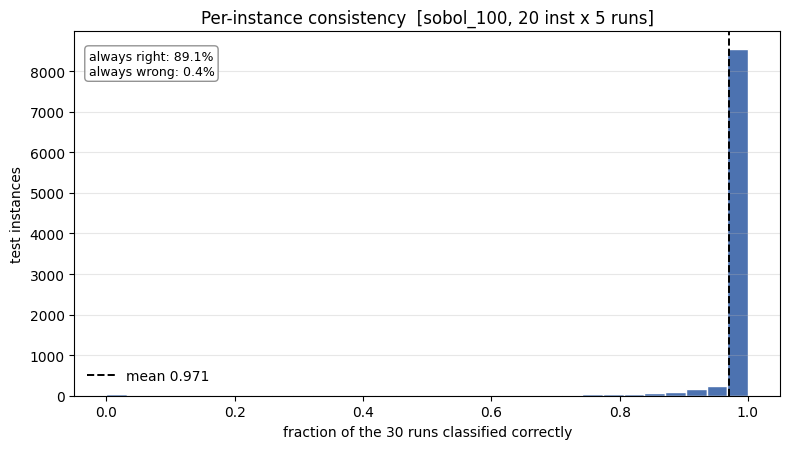

In [9]:
_ = cp.plot_consistency(PATHS[5], "sobol_100")               # C5 — per-instance detail


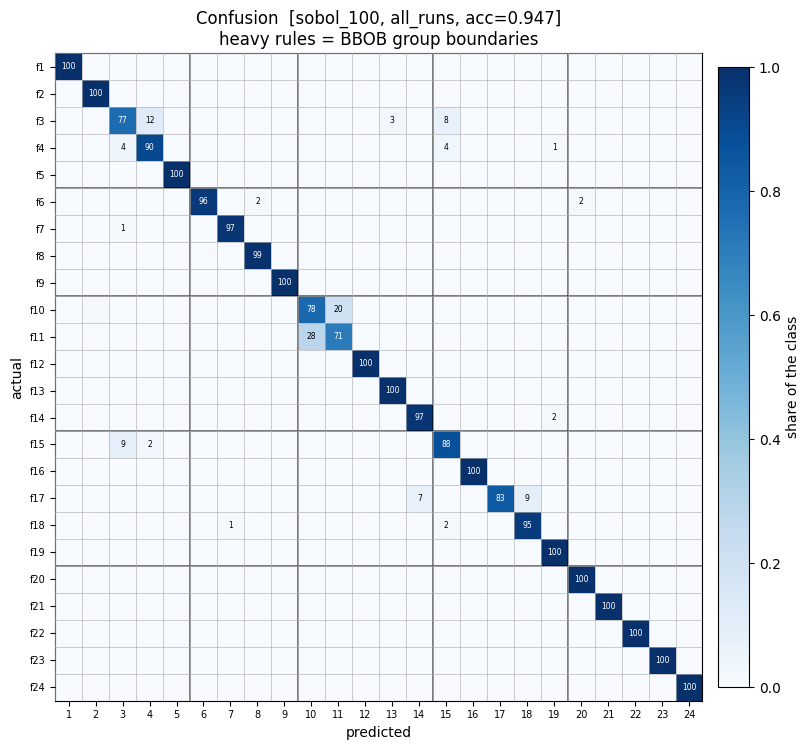

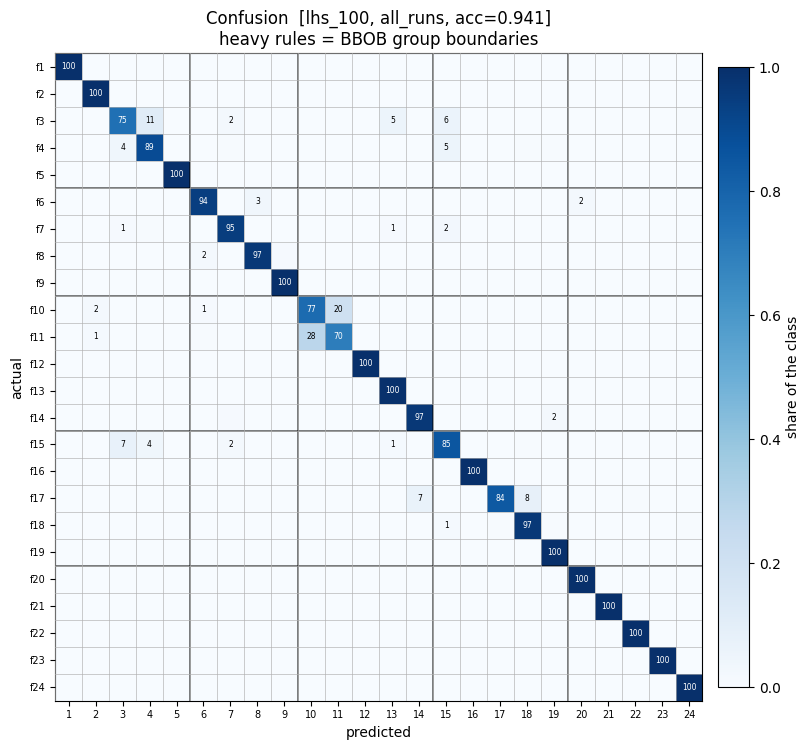

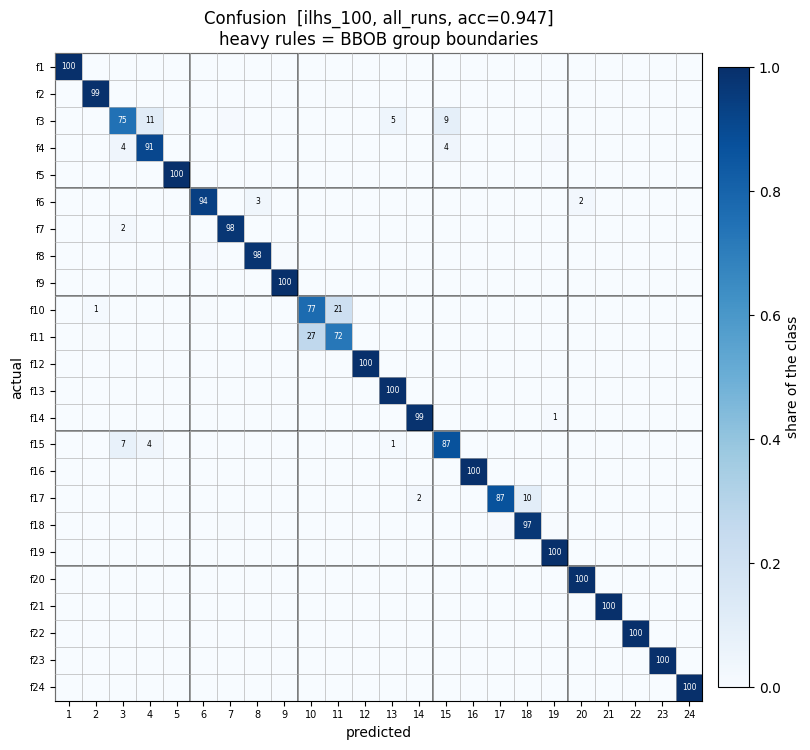

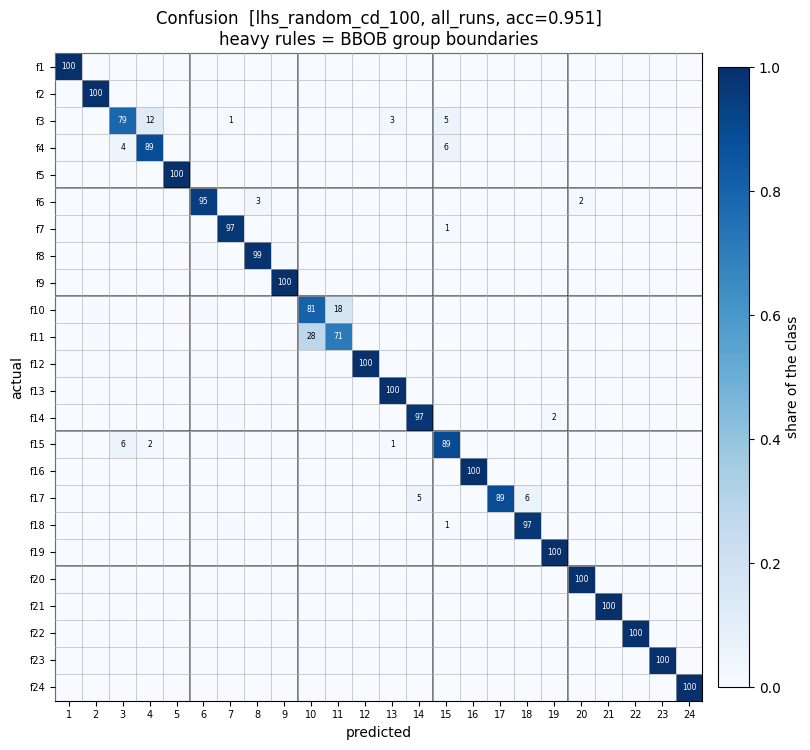

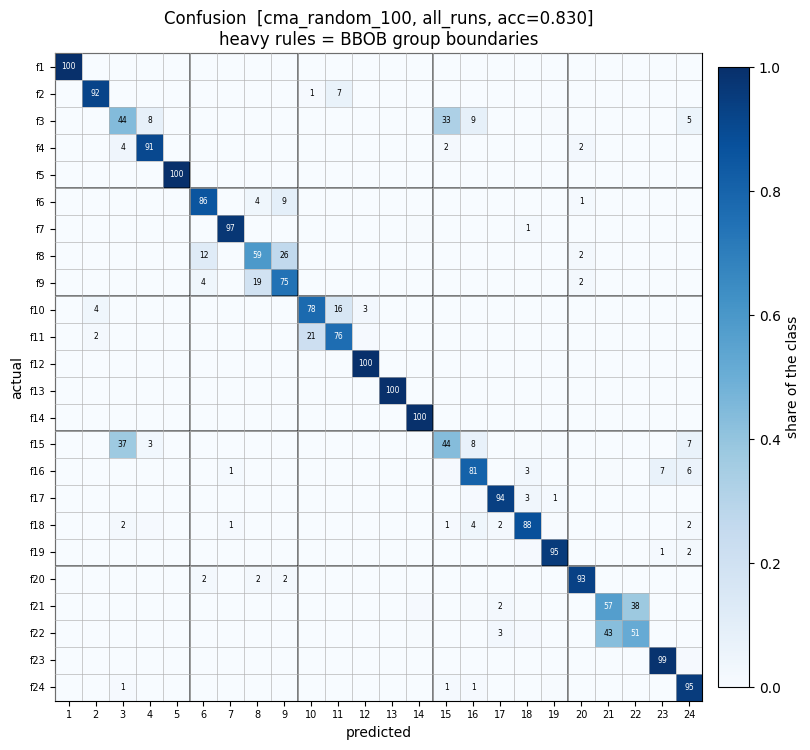

In [10]:
dim = 5
size = 100
n_inst = 10
n_runs = 1
for strat in ("sobol", "lhs", "ilhs", "lhs_random_cd", "cma_random"):
    _ = cp.plot_confusion(PATHS[dim], strat + f"_{size}", n_inst, n_runs, group_lines=True)

Variance in acc_all_runs explained (dim 5, 768 grid points)
factor                       raw   budget-controlled   levels
strategy                  19.0%              44.1%        6
size                       4.4%               2.7%        4
n_instances_train         58.6%              21.7%        8
n_runs_train               6.3%               4.3%        4
_residual                 11.7%              27.2%

  raw        = includes total budget, so the wide-range factors dominate
  controlled = log(budget) regressed out, so this is the ALLOCATION effect


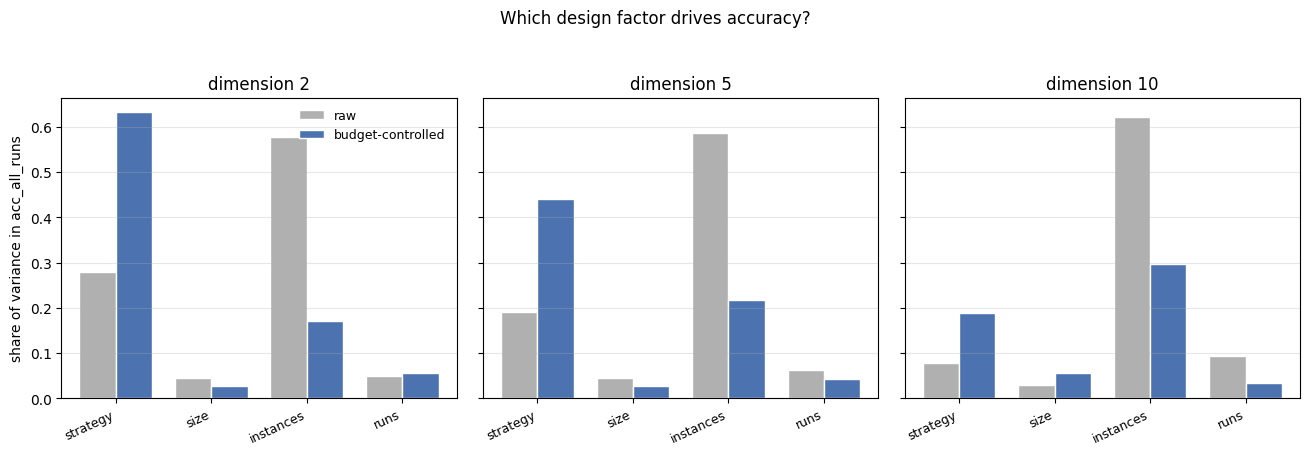

In [11]:
t = cp.factor_importance(df, dimension=5)      # prints the table
_ = cp.plot_factor_importance(df)              # C8 — both columns, per dimension

In [12]:
cp.factor_importance(df[df.strategy != "cma_random"], dimension=5)

Variance in acc_all_runs explained (dim 5, 640 grid points)
factor                       raw   budget-controlled   levels
strategy                   0.4%               1.3%        5
size                       4.4%               5.8%        4
n_instances_train         77.0%              43.7%        8
n_runs_train               5.7%              10.4%        4
_residual                 12.5%              38.8%

  raw        = includes total budget, so the wide-range factors dominate
  controlled = log(budget) regressed out, so this is the ALLOCATION effect


,factor,eta2_raw,eta2_budget_controlled,n_levels
0,strategy,0.004168,0.012978,5.0
1,size,0.044025,0.058255,4.0
2,n_instances_train,0.769680,0.436663,8.0
3,n_runs_train,0.057342,0.103615,4.0
4,_residual,0.124785,0.388490,NaN


In [13]:
for dim in (2, 5, 10):
    fr, ch = cp.budget_frontier(df, dim)
    print()


dim 2 — cheapest configuration reaching each target

 target      fevals     acc  best@cost  #cfg   strategy         size  inst  runs
    50%       2,400   0.601      0.601    18   lhs_random_cd      25     2     1
    60%       2,400   0.601      0.601    18   lhs_random_cd      25     2     1
    70%       3,600   0.720      0.720    18   lhs_random_cd      25     3     1
    80%       8,400   0.820      0.820     6   lhs_random_cd      25     7     1
    85%      16,800   0.857      0.857    12   lhs_random_cd      50     7     1
    90%      96,000   0.902      0.902    18   lhs_random_cd     100    20     1
    95% not reached

  acc = the reported configuration; best@cost = the best of the #cfg allocations
  that cost the same. Equal values mean no better use of those evaluations existed.

  frontier: 22 non-dominated of 49 distinct budgets (768 configurations)
  runs on the frontier: 1 run(s) x17, 2 run(s) x1, 3 run(s) x3, 5 run(s) x1
  sizes on the frontier: 25xd x7, 50xd x6, 7

In [14]:
fr, ch = cp.budget_frontier(df_modified, 2)
print()

tidy, cost, ratio = cp.cost_to_target(df, 2)
print()

dim 2 — cheapest configuration reaching each target

 target      fevals     acc  best@cost  #cfg   strategy         size  inst  runs
    50%       2,400   0.627      0.627    18   lhs_random_cd      25     2     1
    60%       2,400   0.627      0.627    18   lhs_random_cd      25     2     1
    70%       3,600   0.710      0.710    18   lhs_random_cd      25     3     1
    80%       8,400   0.812      0.812     6   lhs_random_cd      25     7     1
    85%      18,000   0.861      0.861    30   lhs_random_cd      25    15     1
    90%      96,000   0.903      0.903    18   lhs_random_cd     100    20     1
    95% not reached

  acc = the reported configuration; best@cost = the best of the #cfg allocations
  that cost the same. Equal values mean no better use of those evaluations existed.

  frontier: 21 non-dominated of 49 distinct budgets (768 configurations)
  runs on the frontier: 1 run(s) x14, 2 run(s) x4, 3 run(s) x2, 5 run(s) x1
  sizes on the frontier: 25xd x8, 50xd x3, 7

dim 2 — cheapest budget for each strategy to reach each target

strategy    sobol     ilhs lhs_random_cd      lhs  uniform cma_random
target                                                               
50%         2,400    2,400         2,400    2,400    2,400      6,000
60%         3,600    3,600         2,400    3,600    3,600     16,800
70%         3,600    3,600         3,600    6,000    6,000     48,000
80%         8,400    8,400         8,400   12,000   16,800          —
85%        24,000   24,000        16,800   33,600   33,600          —
90%       144,000  144,000        96,000  192,000  192,000          —
95%             —        —             —        —        —          —

relative to the cheapest strategy in each row (1.00 = winner):

strategy sobol  ilhs lhs_random_cd   lhs uniform cma_random
target                                                     
50%       1.00  1.00          1.00  1.00    1.00       2.50
60%       1.50  1.50          1.00  1.50    1.50       7.00
7

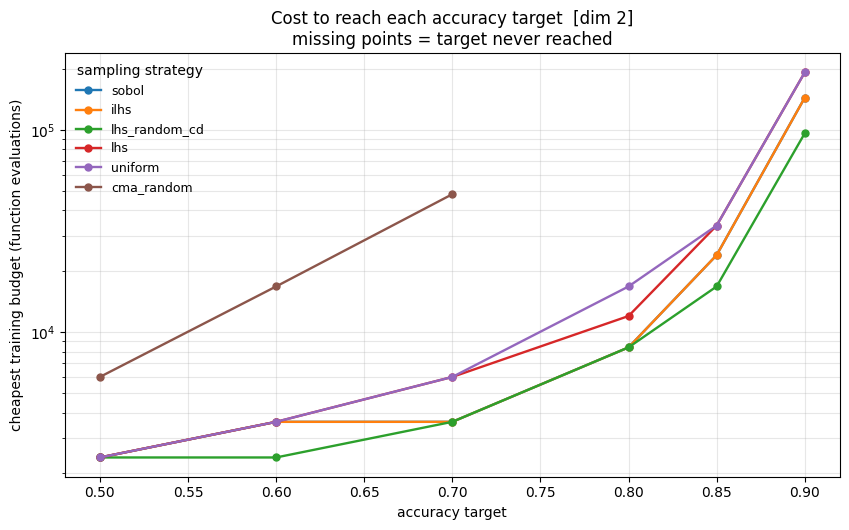

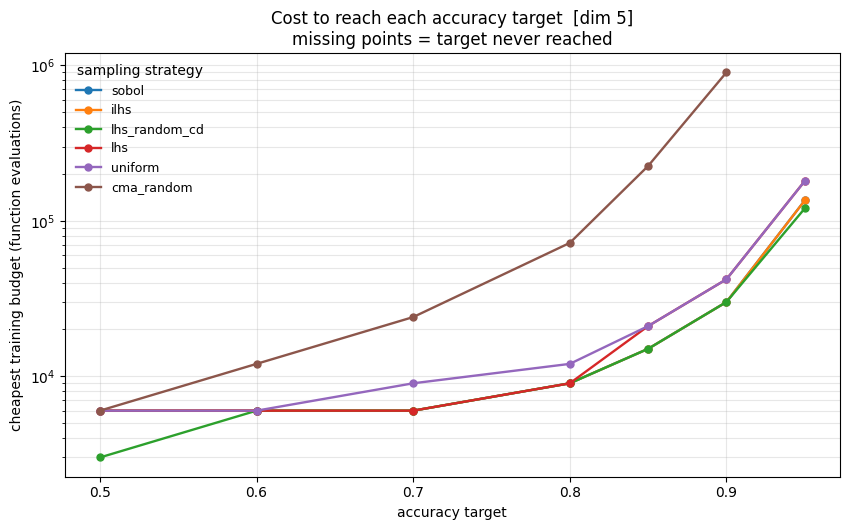

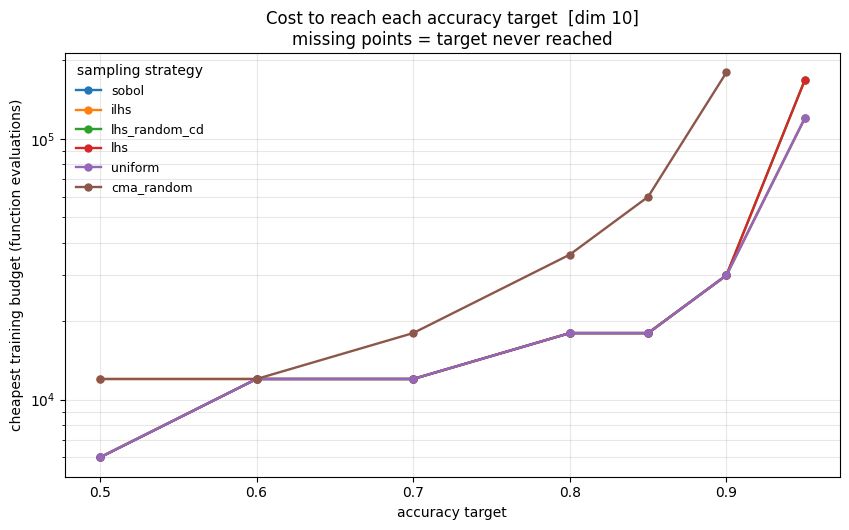

In [15]:
for dim in (2, 5, 10):
    tidy, cost, ratio = cp.cost_to_target(df, dim)
    print()
for dim in (2, 5, 10):
    _ = cp.plot_cost_to_target(df, dimension=dim)     # C10

In [16]:
tidy, cost, ratio = cp.cost_to_target(df, 10, verbose=False)
tidy["n_runs_train"].value_counts()      # is it all 1?


n_runs_train
1.0    35
2.0     6
Name: count, dtype: int64

In [17]:
tidy.pivot(index="target", columns="strategy", values="n_instances_train")


strategy,cma_random,ilhs,lhs,lhs_random_cd,sobol,uniform
target,,,,,,
0.50,2.0,2.0,1.0,1.0,1.0,1.0
0.60,2.0,2.0,2.0,2.0,2.0,1.0
0.70,3.0,2.0,2.0,2.0,2.0,1.0
0.80,3.0,3.0,3.0,3.0,3.0,3.0
0.85,10.0,3.0,3.0,3.0,3.0,3.0
0.90,5.0,5.0,5.0,5.0,5.0,5.0
0.95,NaN,20.0,7.0,7.0,10.0,5.0


In [18]:
tidy.pivot(index="target", columns="strategy", values="size")

strategy,cma_random,ilhs,lhs,lhs_random_cd,sobol,uniform
target,,,,,,
0.50,25.0,25.0,25.0,25.0,25.0,25.0
0.60,25.0,25.0,25.0,25.0,25.0,25.0
0.70,25.0,25.0,25.0,25.0,25.0,25.0
0.80,25.0,25.0,25.0,25.0,25.0,25.0
0.85,25.0,25.0,25.0,25.0,25.0,25.0
0.90,75.0,25.0,25.0,25.0,25.0,25.0
0.95,NaN,25.0,50.0,50.0,50.0,100.0


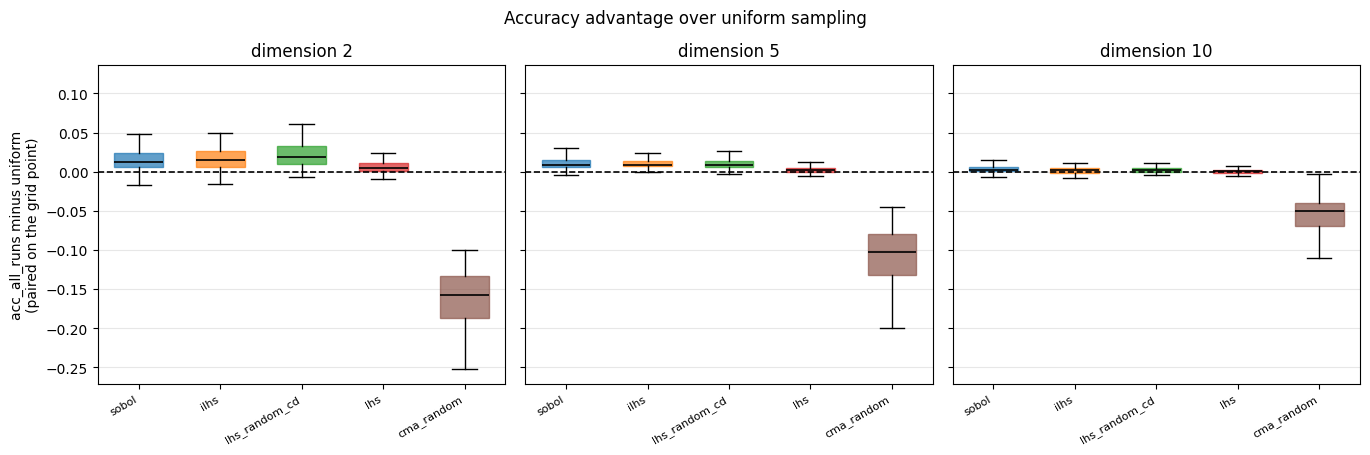

In [19]:
plot_accuracy_delta = cp.plot_accuracy_delta(df, title="Accuracy advantage over uniform sampling")

In [20]:
import numpy as np

tidy, cost, ratio = cp.cost_to_target(df, 10, verbose=False)
tidy["alloc"] = (tidy["n_feval_train"].map(lambda v: f"{v:,.0f}" if np.isfinite(v) else "—")
                 + " (" + tidy["n_instances_train"].astype("Int64").astype(str)
                 + "@" + tidy["size"].astype("Int64").astype(str)
                 + "×" + tidy["n_runs_train"].astype("Int64").astype(str)
                 + ")")
tidy.pivot(index="target", columns="strategy", values="alloc").to_markdown()

'|   target | cma_random       | ilhs              | lhs              | lhs_random_cd    | sobol             | uniform           |\n|---------:|:-----------------|:------------------|:-----------------|:-----------------|:------------------|:------------------|\n|     0.5  | 12,000 (2@25×1)  | 12,000 (2@25×1)   | 6,000 (1@25×1)   | 6,000 (1@25×1)   | 6,000 (1@25×1)    | 6,000 (1@25×1)    |\n|     0.6  | 12,000 (2@25×1)  | 12,000 (2@25×1)   | 12,000 (2@25×1)  | 12,000 (2@25×1)  | 12,000 (2@25×1)   | 12,000 (1@25×2)   |\n|     0.7  | 18,000 (3@25×1)  | 12,000 (2@25×1)   | 12,000 (2@25×1)  | 12,000 (2@25×1)  | 12,000 (2@25×1)   | 12,000 (1@25×2)   |\n|     0.8  | 36,000 (3@25×2)  | 18,000 (3@25×1)   | 18,000 (3@25×1)  | 18,000 (3@25×1)  | 18,000 (3@25×1)   | 18,000 (3@25×1)   |\n|     0.85 | 60,000 (10@25×1) | 18,000 (3@25×1)   | 18,000 (3@25×1)  | 18,000 (3@25×1)  | 18,000 (3@25×1)   | 18,000 (3@25×1)   |\n|     0.9  | 180,000 (5@75×2) | 30,000 (5@25×1)   | 30,000 (5@25×1)  | 30,000 (5@2

In [21]:
tidy, cost, ratio = cp.cost_to_target(df_modified, 2, verbose=False)
tidy["alloc"] = (tidy["n_feval_train"].map(lambda v: f"{v:,.0f}" if np.isfinite(v) else "—")
                 + " (" + tidy["n_instances_train"].astype("Int64").astype(str)
                 + "@" + tidy["size"].astype("Int64").astype(str)
                 + "×" + tidy["n_runs_train"].astype("Int64").astype(str)
                 + ")")
tidy.pivot(index="target", columns="strategy", values="alloc")

strategy,cma_random,ilhs,lhs,lhs_random_cd,sobol,uniform
target,,,,,,
0.50,"6,000 (5@25×1)","2,400 (2@25×1)","2,400 (2@25×1)","2,400 (2@25×1)","2,400 (2@25×1)","2,400 (2@25×1)"
0.60,"16,800 (7@50×1)","2,400 (2@25×1)","3,600 (3@25×1)","2,400 (2@25×1)","2,400 (2@25×1)","3,600 (3@25×1)"
0.70,"48,000 (20@50×1)","3,600 (3@25×1)","6,000 (5@25×1)","3,600 (3@25×1)","4,800 (2@25×2)","6,000 (5@25×1)"
0.80,NaN,"8,400 (7@25×1)","12,000 (10@25×1)","8,400 (7@25×1)","12,000 (10@25×1)","16,800 (7@50×1)"
0.85,NaN,"24,000 (10@50×1)","33,600 (7@100×1)","18,000 (15@25×1)","24,000 (10@50×1)","33,600 (7@100×1)"
0.90,NaN,"144,000 (20@75×2)","144,000 (20@75×2)","96,000 (20@100×1)","96,000 (20@100×1)","192,000 (20@100×2)"
0.95,NaN,NaN,NaN,NaN,NaN,NaN


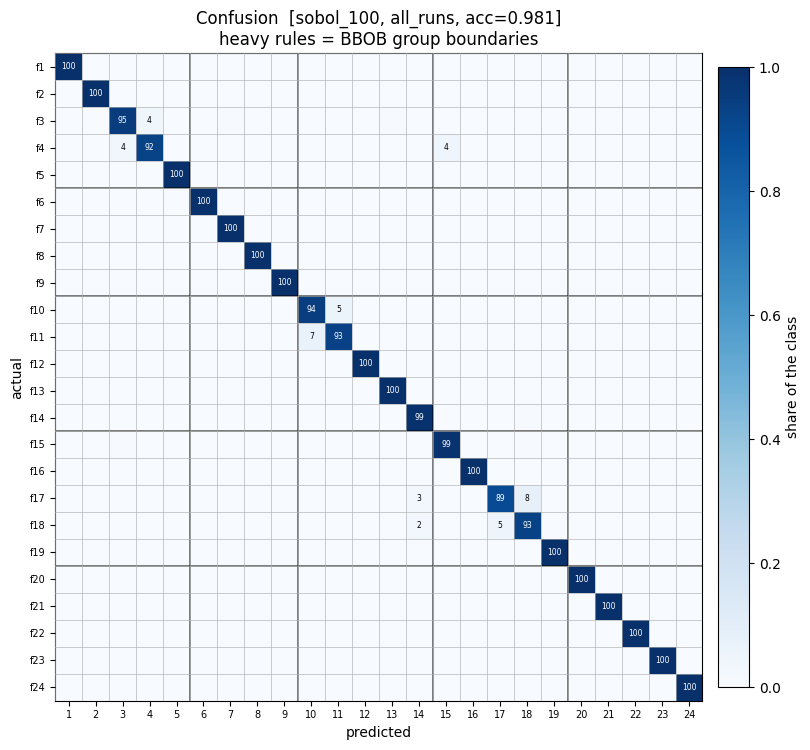

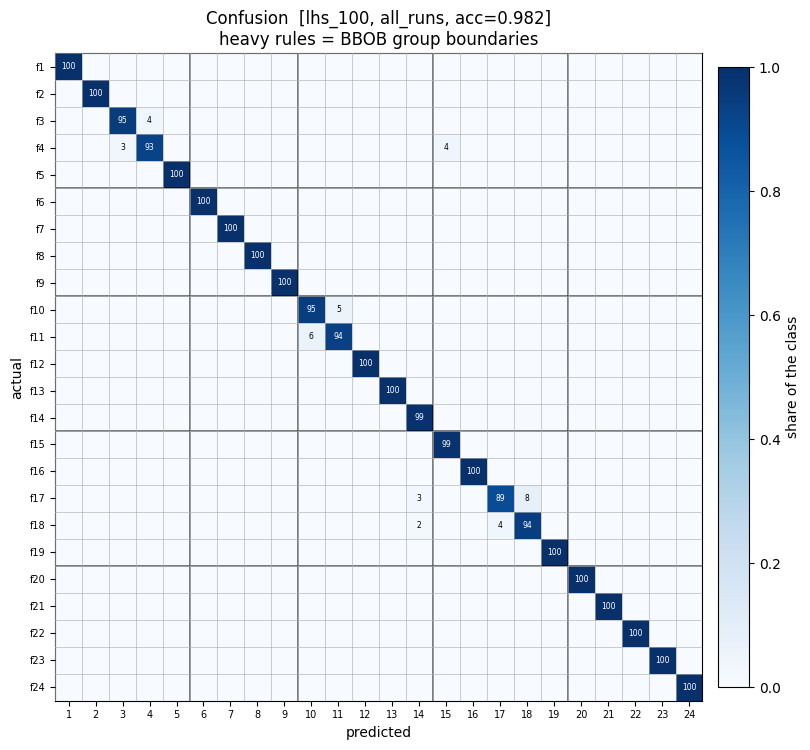

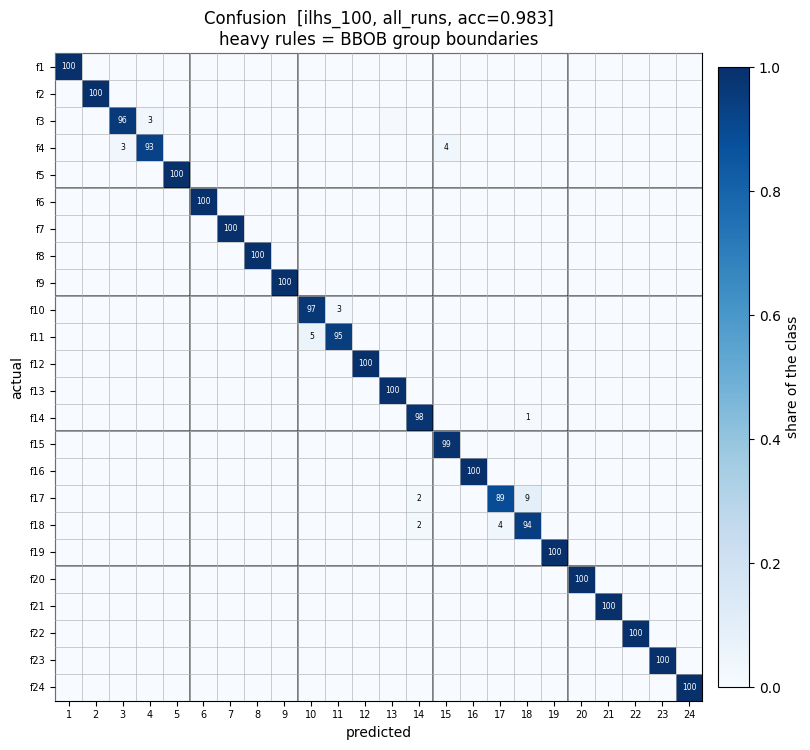

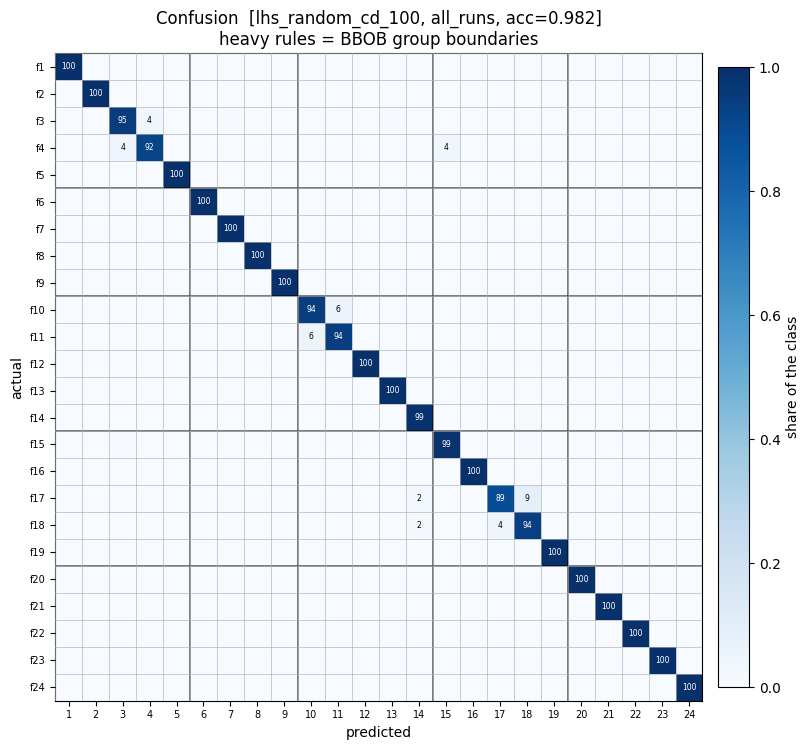

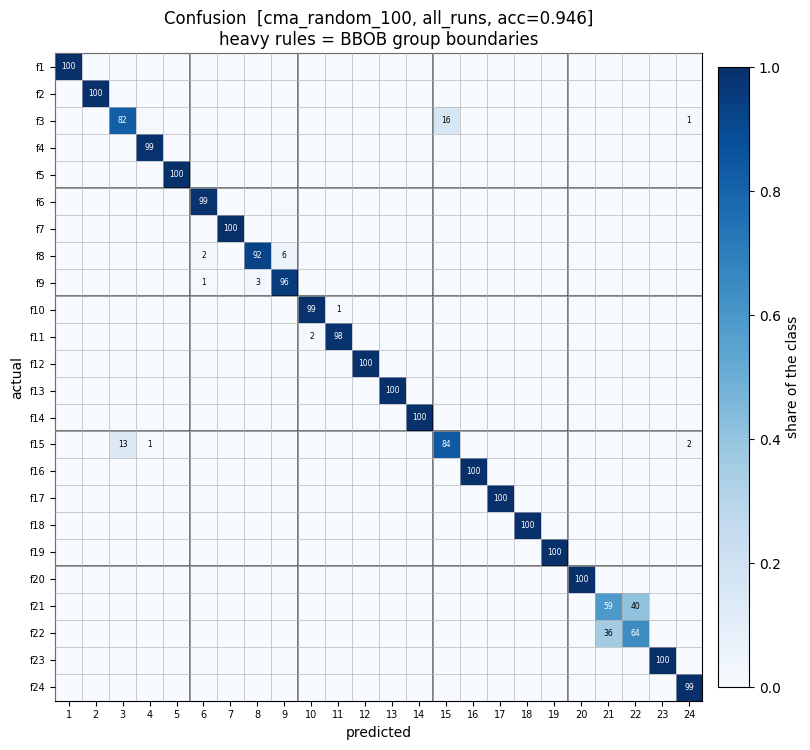

In [22]:
dim = 10
size = 100
n_inst = 20
n_runs = 5
for strat in ("sobol", "lhs", "ilhs", "lhs_random_cd", "cma_random"):
    _ = cp.plot_confusion(PATHS[dim], strat + f"_{size}", n_inst, n_runs, group_lines=True)

In [23]:
for dim in (2, 5, 10):
    cp.best_per_strategy(df_modified, dim, as_markdown=True, verbose=True)
    print()

| strategy      |   acc_all_runs |   fevals | allocation   |
|:--------------|---------------:|---------:|:-------------|
| lhs_random_cd |         0.9188 |  480,000 | 20@100×5     |
| sobol         |         0.9145 |  480,000 | 20@100×5     |
| ilhs          |         0.9137 |  480,000 | 20@100×5     |
| lhs           |         0.9137 |  480,000 | 20@100×5     |
| uniform       |         0.9103 |  480,000 | 20@100×5     |
| cma_random    |         0.7951 |  480,000 | 20@100×5     |

| strategy      |   acc_all_runs |    fevals | allocation   |
|:--------------|---------------:|----------:|:-------------|
| ilhs          |         0.974  | 1,200,000 | 20@100×5     |
| sobol         |         0.9712 | 1,200,000 | 20@100×5     |
| lhs_random_cd |         0.9711 | 1,200,000 | 20@100×5     |
| uniform       |         0.9694 | 1,200,000 | 20@100×5     |
| lhs           |         0.969  | 1,200,000 | 20@100×5     |
| cma_random    |         0.9063 | 1,200,000 | 20@100×5     |

| strategy    

In [24]:
import numpy as np
for ni, nr in [(3,1), (10,1), (20,1), (20,5)]:
    p = cp.load_predictions(PATHS[5], "sobol_100", ni, nr)
    y, pr = p["true_labels"], p["pred_runs"]
    yr = np.repeat(y, pr.shape[1]); pred = pr.ravel()
    m10 = yr == 9                      # f10 is label 9
    print(f"{ni:2d}@{nr}: f10 correct {(pred[m10]==9).mean():.3f}, "
          f"→f11 {(pred[m10]==10).mean():.3f}")

 3@1: f10 correct 0.658, →f11 0.325
10@1: f10 correct 0.779, →f11 0.204
20@1: f10 correct 0.779, →f11 0.212
20@5: f10 correct 0.783, →f11 0.214


In [25]:
MAX = {d: f"/Users/leekaijen/t7ssd/featELA/dim{d}featELA/max/ela_classification_subsample_modified.h5"
       for d in (2, 5, 10)}

out, pivot = cp.ceiling_table(MAX)                    # detailed per dimension
cp.ceiling_table(MAX, as_markdown=True, verbose=False)  # markdown pivot


dim 2 — maximum attainable (20 inst x 30 runs @ 100xd, 2,880,000 fevals)

strategy              acc  +/- fold  consistency
lhs                0.9198    0.0037       0.9198
lhs_random_cd      0.9193    0.0077       0.9193
uniform            0.9182    0.0032       0.9182
sobol              0.9168    0.0076       0.9168
ilhs               0.9148    0.0070       0.9148
cma_random         0.8397    0.0016       0.8397
  space-filling spread: 0.0050 (max fold sd 0.0077)

dim 5 — maximum attainable (20 inst x 30 runs @ 100xd, 7,200,000 fevals)

strategy              acc  +/- fold  consistency
ilhs               0.9756    0.0024       0.9756
uniform            0.9709    0.0031       0.9709
sobol              0.9704    0.0035       0.9704
lhs                0.9702    0.0033       0.9702
lhs_random_cd      0.9692    0.0043       0.9692
cma_random         0.9368    0.0008       0.9368
  space-filling spread: 0.0064 (max fold sd 0.0043)

dim 10 — maximum attainable (20 inst x 30 runs @ 100xd, 14,

(    dimension       strategy  acc_all_runs  acc_median  consistency  fold_std  \
 0           2          sobol      0.916788    0.920312     0.916788  0.007649   
 1           2           ilhs      0.914802    0.916979     0.914802  0.006952   
 2           2  lhs_random_cd      0.919340    0.921146     0.919340  0.007657   
 3           2            lhs      0.919757    0.924375     0.919757  0.003689   
 4           2        uniform      0.918188    0.924063     0.918188  0.003215   
 5           2     cma_random      0.839653    0.886042     0.839653  0.001644   
 6           5          sobol      0.970389    0.975208     0.970389  0.003486   
 7           5           ilhs      0.975580    0.982187     0.975580  0.002368   
 8           5  lhs_random_cd      0.969184    0.975000     0.969184  0.004327   
 9           5            lhs      0.970208    0.977708     0.970208  0.003255   
 10          5        uniform      0.970861    0.979688     0.970861  0.003109   
 11          5  

## Correlating with ICC and/or CV and/or Stability

In [26]:
import sys
sys.path.insert(0, "../../..")
from process_ela_icc import load_icc, components_to_dataframe

In [27]:
icc_df = components_to_dataframe(load_icc(BASE / "dim2featELA" / "ela_icc_results.pkl"))

In [28]:
sigma = (icc_df.query("dimension == 2 and size == 100 and sigma2_within > 0")
         .assign(sd_w=lambda d: d.sigma2_within**0.5))

In [29]:
import icc_analysis as ia
tab = ia.prepare(icc_df)
sc  = ia.scope_comparable(tab, mode="all")
r   = ia.component_ratios(sc)
sigma = r.query("dimension == 2 and size == 100").groupby("strategy")["ratio_w"].median()

23,040 cells | 40 features x 24 functions x 6 strategies | dims [2]
no-signal cells (sigma2_between <= 0): 12.7%
  of which raw ICC < 0: 12.7% (kept, not clipped)
scope[all]: kept 2,656 of 3,816 (function, feature, size) cells (69.6%) with detectable signal
  most cells dropped: f20 (894), f24 (844), f23 (838), f5 (739), f2 (486)


MSW (mean square within) — estimator of within-instance variation, σ²_w

Calculated per ((sampling strategy, sample size, dimension), function, feature).

For each of the function's 100 instances, take the variance of the feature
across that instance's 30 runs. MSW is the mean of those 100 variances.

σ_w = √MSW, in the feature's own units.


ratio_w = σ_w(strategy) / σ_w(uniform)

aggregated by median:   For each (strategy, size), take the median of those ratios over all ~24 functions × ~40 features.

In [30]:
r.query("dimension == 2").groupby(["strategy", "size"])["ratio_w"].median().unstack()

size,25,50,75,100
strategy,,,,
cma_random,1.525953,2.103882,2.491869,2.865743
ilhs,0.668315,0.611290,0.562535,0.558002
lhs,0.878836,0.889223,0.881626,0.891171
lhs_random_cd,0.661363,0.635658,0.606803,0.604221
sobol,0.733111,0.678873,0.650985,0.631976
uniform,1.000000,1.000000,1.000000,1.000000


In [31]:
r.query("dimension == 2").groupby(["strategy","size"])["ratio_w"].agg(
    median="median",
    geomean=lambda s: np.exp(np.log(s[s>0]).mean()),
    mean="mean")

median   geomean      mean
strategy      size                              
cma_random    25    1.525953  1.782130  3.481790
              50    2.103882  2.327525  4.457132
              75    2.491869  2.717601  5.997535
              100   2.865743  3.062264  8.090601
ilhs          25    0.668315  0.614731  0.681590
              50    0.611290  0.527870  0.645669
              75    0.562535  0.492931  0.604609
              100   0.558002  0.466713  0.646460
lhs           25    0.878836  0.796999  0.862788
              50    0.889223  0.807894  0.946258
              75    0.881626  0.788668  0.857134
              100   0.891171  0.787990  0.858077
lhs_random_cd 25    0.661363  0.447347  0.638999
              50    0.635658  0.395019  0.649766
              75    0.606803  0.350842  0.583076
              100   0.604221  0.326968  0.609141
sobol         25    0.733111  0.623128  0.678540
              50    0.678873  0.581119  0.749322
              75    0.650985  0.546519  0.771433
              100   0.631976  0.510122  0.649288
uniform       25    1.000000  1.000000  1.000000
              50    1.000000  1.000000  1.000000
              75    1.000000  1.000000  1.000000
              100   1.000000  1.000000  1.000000

In [32]:
df.query("dimension==2 and strategy=='ilhs' and n_instances_train==20")[
    ["size","n_runs_train","n_feval_train","acc_all_runs"]].sort_values("n_feval_train")

,size,n_runs_train,n_feval_train,acc_all_runs
156,25,1,24000,0.853882
157,25,2,48000,0.866517
188,50,1,48000,0.878111
158,25,3,72000,0.880875
220,75,1,72000,0.888021
189,50,2,96000,0.893542
252,100,1,96000,0.896184
159,25,5,120000,0.885712
190,50,3,144000,0.900427
221,75,2,144000,0.900563


In [33]:
icc5  = components_to_dataframe(load_icc(BASE / "dim5featELA"  / "ela_icc_results.pkl"))
icc10 = components_to_dataframe(load_icc(BASE / "dim10featELA" / "ela_icc_results.pkl"))
r5  = ia.component_ratios(ia.scope_comparable(ia.prepare(icc5),  mode="all"))
r10 = ia.component_ratios(ia.scope_comparable(ia.prepare(icc10), mode="all"))

25,920 cells | 45 features x 24 functions x 6 strategies | dims [5]
no-signal cells (sigma2_between <= 0): 13.9%
  of which raw ICC < 0: 13.9% (kept, not clipped)
scope[all]: kept 2,789 of 4,296 (function, feature, size) cells (64.9%) with detectable signal
  most cells dropped: f20 (1003), f23 (994), f24 (990), f5 (873), f16 (864)
25,920 cells | 45 features x 24 functions x 6 strategies | dims [10]
no-signal cells (sigma2_between <= 0): 13.5%
  of which raw ICC < 0: 13.5% (kept, not clipped)
scope[all]: kept 2,856 of 4,296 (function, feature, size) cells (66.5%) with detectable signal
  most cells dropped: f23 (1038), f20 (1020), f24 (1008), f16 (996), f5 (882)


In [34]:
r5['feature'].unique()

<StringArray>
[                 'ela_distr.skewness',                  'ela_distr.kurtosis',
          'ela_meta.lin_simple.adj_r2',       'ela_meta.lin_simple.intercept',
        'ela_meta.lin_simple.coef.min',        'ela_meta.lin_simple.coef.max',
      'ela_meta.lin_w_interact.adj_r2',                  'disp.ratio_mean_02',
                  'disp.ratio_mean_05',                  'disp.ratio_mean_10',
                  'disp.ratio_mean_25',                'disp.ratio_median_05',
                'disp.ratio_median_10',                'disp.ratio_median_25',
                   'disp.diff_mean_02',                   'disp.diff_mean_05',
                   'disp.diff_mean_10',                   'disp.diff_mean_25',
                 'disp.diff_median_05',                 'disp.diff_median_10',
                 'disp.diff_median_25',                  'nbc.nn_nb.sd_ratio',
                'nbc.nn_nb.mean_ratio',            'nbc.dist_ratio.coeff_var',
                  'nbc.nb_fitness.cor'

In [35]:
r5.query("dimension == 5").groupby(["strategy","size"])["ratio_w"].median().unstack()


size,25,50,75,100
strategy,,,,
cma_random,1.641122,2.350056,2.601493,2.859315
ilhs,0.794925,0.740599,0.720832,0.709138
lhs,0.953997,0.954172,0.957982,0.960200
lhs_random_cd,0.775609,0.776234,0.767418,0.768049
sobol,0.780689,0.742908,0.716728,0.699338
uniform,1.000000,1.000000,1.000000,1.000000


In [36]:
r10.query("dimension == 10").groupby(["strategy","size"])["ratio_w"].median().unstack()

size,25,50,75,100
strategy,,,,
cma_random,2.053425,2.806083,3.255996,3.354001
ilhs,1.113729,1.139394,1.158886,1.171597
lhs,0.971631,0.973306,0.974320,0.974054
lhs_random_cd,0.796272,0.815219,0.817218,0.823933
sobol,0.875267,0.855672,0.820765,0.786077
uniform,1.000000,1.000000,1.000000,1.000000


In [37]:
import numpy as np
tidy, cost, ratio = cp.cost_to_target(df, 2, verbose=False)
tidy["alloc"] = (tidy["n_feval_train"].map(lambda v: f"{v:,.0f}" if np.isfinite(v) else "—")
                 + " (" + tidy["n_instances_train"].astype("Int64").astype(str)
                 + "@" + tidy["size"].astype("Int64").astype(str) + ")")
tbl = tidy.pivot(index="target", columns="strategy", values="alloc")
tbl.index = [f"{t:.0%}" for t in tbl.index]
print(tbl.to_markdown())

|     | cma_random     | ilhs            | lhs              | lhs_random_cd   | sobol           | uniform          |
|:----|:---------------|:----------------|:-----------------|:----------------|:----------------|:-----------------|
| 50% | 6,000 (5@25)   | 2,400 (2@25)    | 2,400 (2@25)     | 2,400 (2@25)    | 2,400 (2@25)    | 2,400 (2@25)     |
| 60% | 16,800 (7@50)  | 3,600 (3@25)    | 3,600 (3@25)     | 2,400 (2@25)    | 3,600 (3@25)    | 3,600 (3@25)     |
| 70% | 48,000 (20@50) | 3,600 (3@25)    | 6,000 (5@25)     | 3,600 (3@25)    | 3,600 (3@25)    | 6,000 (5@25)     |
| 80% | nan            | 8,400 (7@25)    | 12,000 (10@25)   | 8,400 (7@25)    | 8,400 (7@25)    | 16,800 (7@50)    |
| 85% | nan            | 24,000 (20@25)  | 33,600 (7@100)   | 16,800 (7@50)   | 24,000 (10@50)  | 33,600 (7@100)   |
| 90% | nan            | 144,000 (20@75) | 192,000 (20@100) | 96,000 (20@100) | 144,000 (20@75) | 192,000 (20@100) |
| 95% | nan            | nan             | nan              | na

In [38]:
tidy, cost, ratio = cp.cost_to_target(df, 5, verbose=False)
tidy["alloc"] = (tidy["n_feval_train"].map(lambda v: f"{v:,.0f}" if np.isfinite(v) else "—")
                 + " (" + tidy["n_instances_train"].astype("Int64").astype(str)
                 + "@" + tidy["size"].astype("Int64").astype(str)
                 + "×" + tidy["n_runs_train"].astype("Int64").astype(str) + ")")
t = tidy.pivot(index="target", columns="strategy", values="alloc")
t.index = [f"{x:.0%}" for x in t.index]
print(t.to_markdown())

|     | cma_random        | ilhs              | lhs                | lhs_random_cd      | sobol             | uniform            |
|:----|:------------------|:------------------|:-------------------|:-------------------|:------------------|:-------------------|
| 50% | 6,000 (2@25×1)    | 6,000 (2@25×1)    | 6,000 (2@25×1)     | 3,000 (1@25×1)     | 6,000 (2@25×1)    | 6,000 (2@25×1)     |
| 60% | 12,000 (2@25×2)   | 6,000 (2@25×1)    | 6,000 (2@25×1)     | 6,000 (2@25×1)     | 6,000 (2@25×1)    | 6,000 (2@25×1)     |
| 70% | 24,000 (2@50×2)   | 6,000 (2@25×1)    | 6,000 (2@25×1)     | 6,000 (2@25×1)     | 6,000 (2@25×1)    | 9,000 (3@25×1)     |
| 80% | 72,000 (3@100×2)  | 9,000 (3@25×1)    | 9,000 (3@25×1)     | 9,000 (3@25×1)     | 9,000 (3@25×1)    | 12,000 (2@25×2)    |
| 85% | 225,000 (5@75×5)  | 15,000 (5@25×1)   | 21,000 (7@25×1)    | 15,000 (5@25×1)    | 15,000 (5@25×1)   | 21,000 (7@25×1)    |
| 90% | 900,000 (20@75×5) | 30,000 (10@25×1)  | 42,000 (7@50×1)    | 30,000 (10@25×

In [39]:
tidy, cost, ratio = cp.cost_to_target(df, 10, verbose=False)
tidy["alloc"] = (tidy["n_feval_train"].map(lambda v: f"{v:,.0f}" if np.isfinite(v) else "—")
                 + " (" + tidy["n_instances_train"].astype("Int64").astype(str)
                 + "@" + tidy["size"].astype("Int64").astype(str)
                 + "×" + tidy["n_runs_train"].astype("Int64").astype(str) + ")")
t = tidy.pivot(index="target", columns="strategy", values="alloc")
t.index = [f"{x:.0%}" for x in t.index]
print(t.to_markdown())

|     | cma_random       | ilhs              | lhs              | lhs_random_cd    | sobol             | uniform           |
|:----|:-----------------|:------------------|:-----------------|:-----------------|:------------------|:------------------|
| 50% | 12,000 (2@25×1)  | 12,000 (2@25×1)   | 6,000 (1@25×1)   | 6,000 (1@25×1)   | 6,000 (1@25×1)    | 6,000 (1@25×1)    |
| 60% | 12,000 (2@25×1)  | 12,000 (2@25×1)   | 12,000 (2@25×1)  | 12,000 (2@25×1)  | 12,000 (2@25×1)   | 12,000 (1@25×2)   |
| 70% | 18,000 (3@25×1)  | 12,000 (2@25×1)   | 12,000 (2@25×1)  | 12,000 (2@25×1)  | 12,000 (2@25×1)   | 12,000 (1@25×2)   |
| 80% | 36,000 (3@25×2)  | 18,000 (3@25×1)   | 18,000 (3@25×1)  | 18,000 (3@25×1)  | 18,000 (3@25×1)   | 18,000 (3@25×1)   |
| 85% | 60,000 (10@25×1) | 18,000 (3@25×1)   | 18,000 (3@25×1)  | 18,000 (3@25×1)  | 18,000 (3@25×1)   | 18,000 (3@25×1)   |
| 90% | 180,000 (5@75×2) | 30,000 (5@25×1)   | 30,000 (5@25×1)  | 30,000 (5@25×1)  | 30,000 (5@25×1)   | 30,000 (5@25×1)   |


In [40]:
import pandas as pd
r_all = pd.concat([r, r5, r10], ignore_index=True)   # your three ratio frames

for dim in (2, 5, 10):
    cp.stability_cost_table(df, r_all, dim)
    print()

### Dimension 2

| target   | cheapest                   | allocation   | sigma_w     | fevals   | min_sigma_w   | most_stable   | its_allocation   | its_fevals   |
|:---------|:---------------------------|:-------------|:------------|:---------|:--------------|:--------------|:-----------------|:-------------|
| 50%      | 5-way tie                  | 2@25x1       | 0.661–1.000 | 2,400    | 0.661         | lhs_random_cd | 1@25x2           | 2,400        |
| 60%      | lhs_random_cd              | 2@25x1       | 0.661       | 2,400    | 0.661         | lhs_random_cd | 2@25x1           | 2,400        |
| 70%      | ilhs, lhs_random_cd, sobol | 3@25x1       | 0.661–0.733 | 3,600    | 0.661         | lhs_random_cd | 3@25x1           | 3,600        |
| 80%      | ilhs, lhs_random_cd, sobol | 7@25x1       | 0.661–0.733 | 8,400    | 0.661         | lhs_random_cd | 7@25x1           | 8,400        |
| 85%      | lhs_random_cd              | 7@50x1       | 0.636       | 16,800   | 0.611        

## Budget Allocation

(<Figure size 1600x1950 with 6 Axes>,
 array([[<Axes: title={'center': 'sobol'}, ylabel='Mean Accuracy across folds'>,
         <Axes: title={'center': 'ilhs'}>],
        [<Axes: title={'center': 'lhs_random_cd'}, ylabel='Mean Accuracy across folds'>,
         <Axes: title={'center': 'lhs'}>],
        [<Axes: title={'center': 'uniform'}, xlabel='training budget (function evaluations)', ylabel='Mean Accuracy across folds'>,
         <Axes: title={'center': 'cma_random'}, xlabel='training budget (function evaluations)'>]],
       dtype=object))

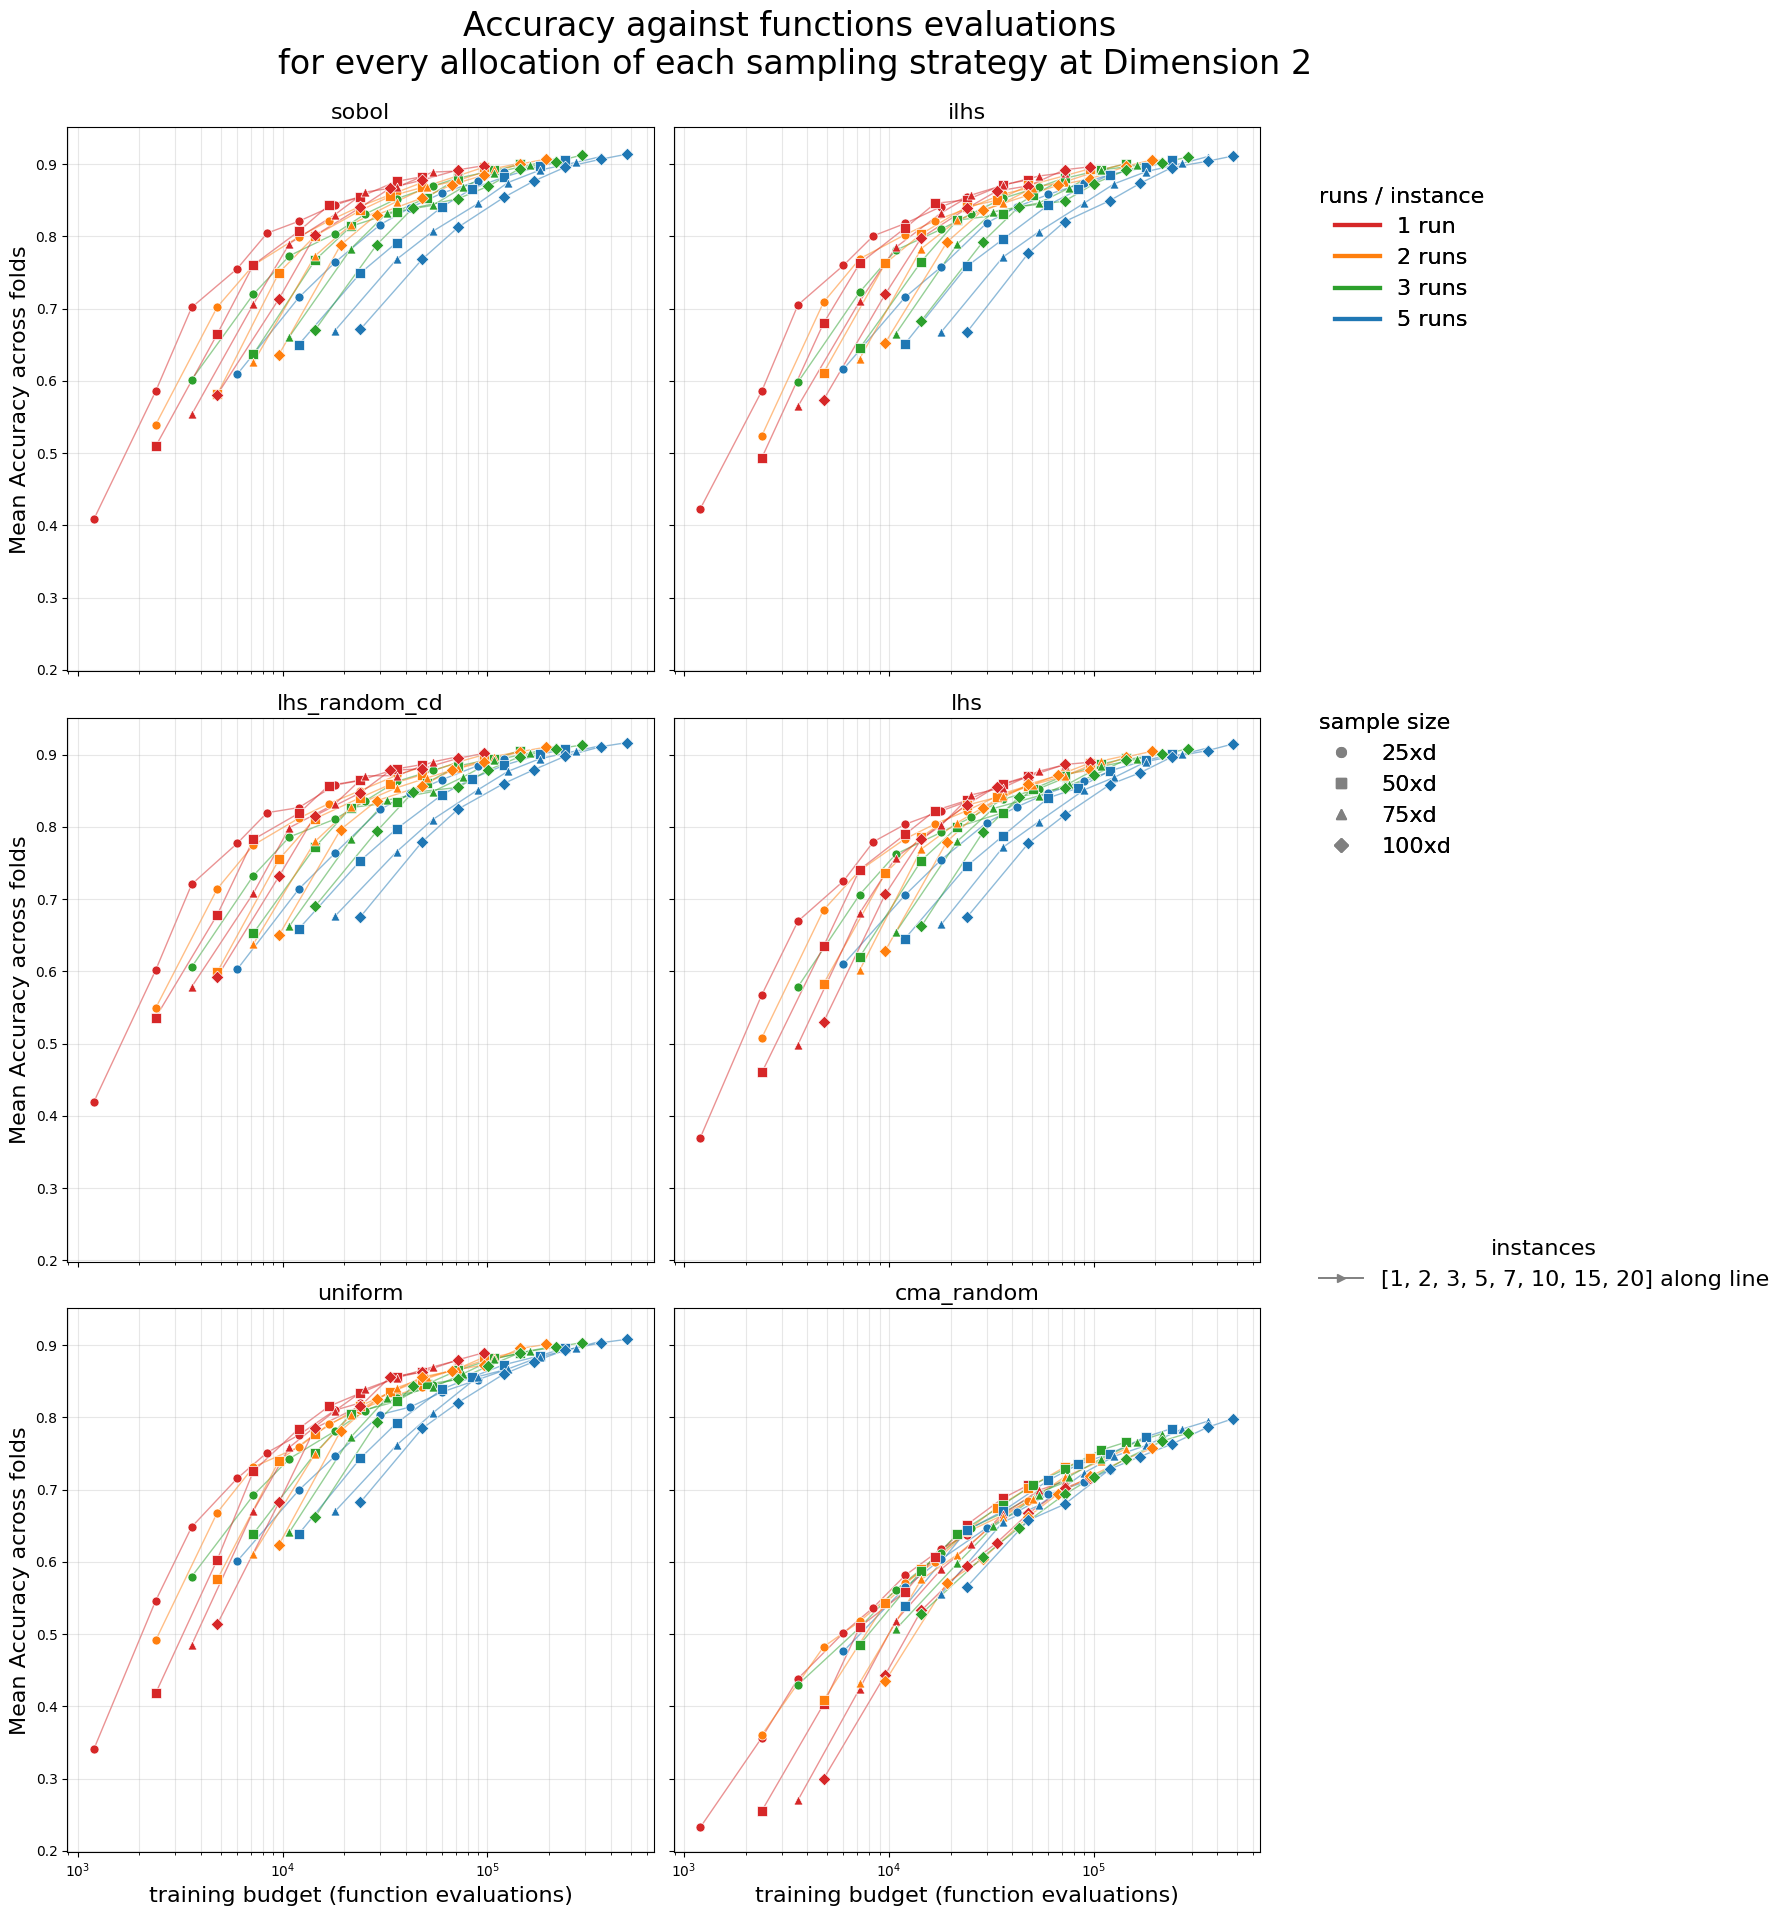

In [41]:
cp.plot_allocation_scatter(df, 2, logx=True, width_per=8, height_per=6.5)        # C10 — within sampler

(<Figure size 1600x1950 with 6 Axes>,
 array([[<Axes: title={'center': 'sobol'}, ylabel='Mean Accuracy across folds'>,
         <Axes: title={'center': 'ilhs'}>],
        [<Axes: title={'center': 'lhs_random_cd'}, ylabel='Mean Accuracy across folds'>,
         <Axes: title={'center': 'lhs'}>],
        [<Axes: title={'center': 'uniform'}, xlabel='training budget (function evaluations)', ylabel='Mean Accuracy across folds'>,
         <Axes: title={'center': 'cma_random'}, xlabel='training budget (function evaluations)'>]],
       dtype=object))

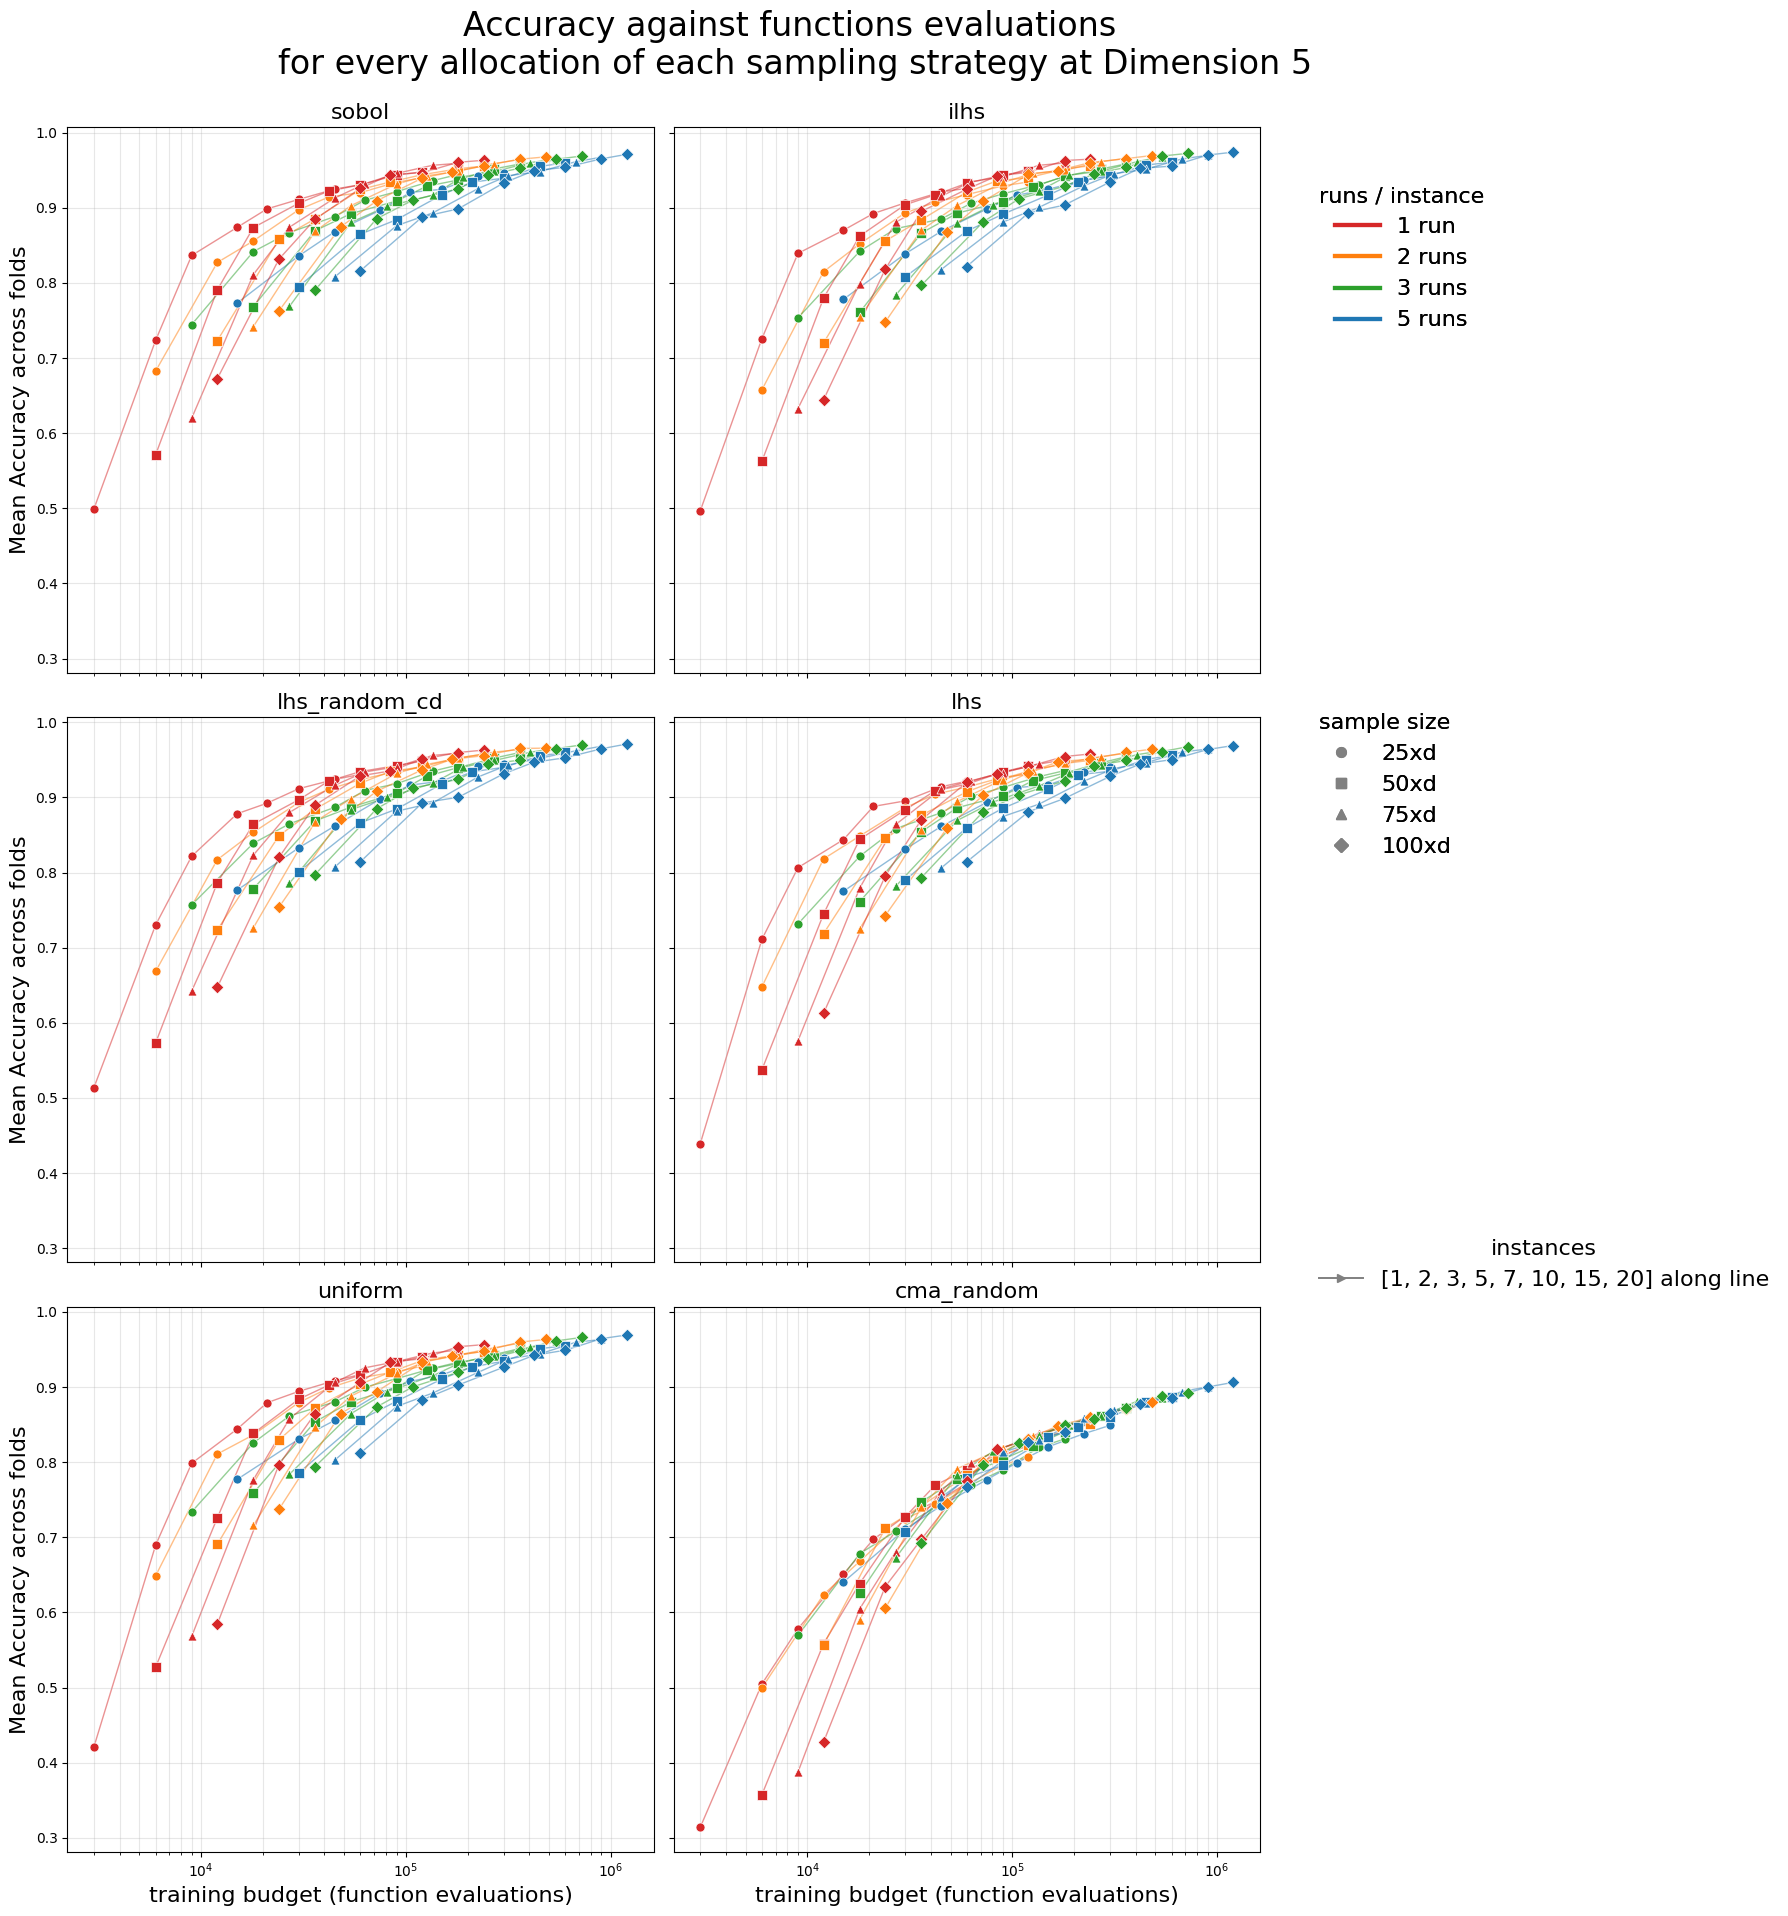

In [42]:
cp.plot_allocation_scatter(df, 5, logx=True, width_per=8, height_per=6.5)        # C10 — within sampler


(<Figure size 1600x1950 with 6 Axes>,
 array([[<Axes: title={'center': 'sobol'}, ylabel='Mean Accuracy across folds'>,
         <Axes: title={'center': 'ilhs'}>],
        [<Axes: title={'center': 'lhs_random_cd'}, ylabel='Mean Accuracy across folds'>,
         <Axes: title={'center': 'lhs'}>],
        [<Axes: title={'center': 'uniform'}, xlabel='training budget (function evaluations)', ylabel='Mean Accuracy across folds'>,
         <Axes: title={'center': 'cma_random'}, xlabel='training budget (function evaluations)'>]],
       dtype=object))

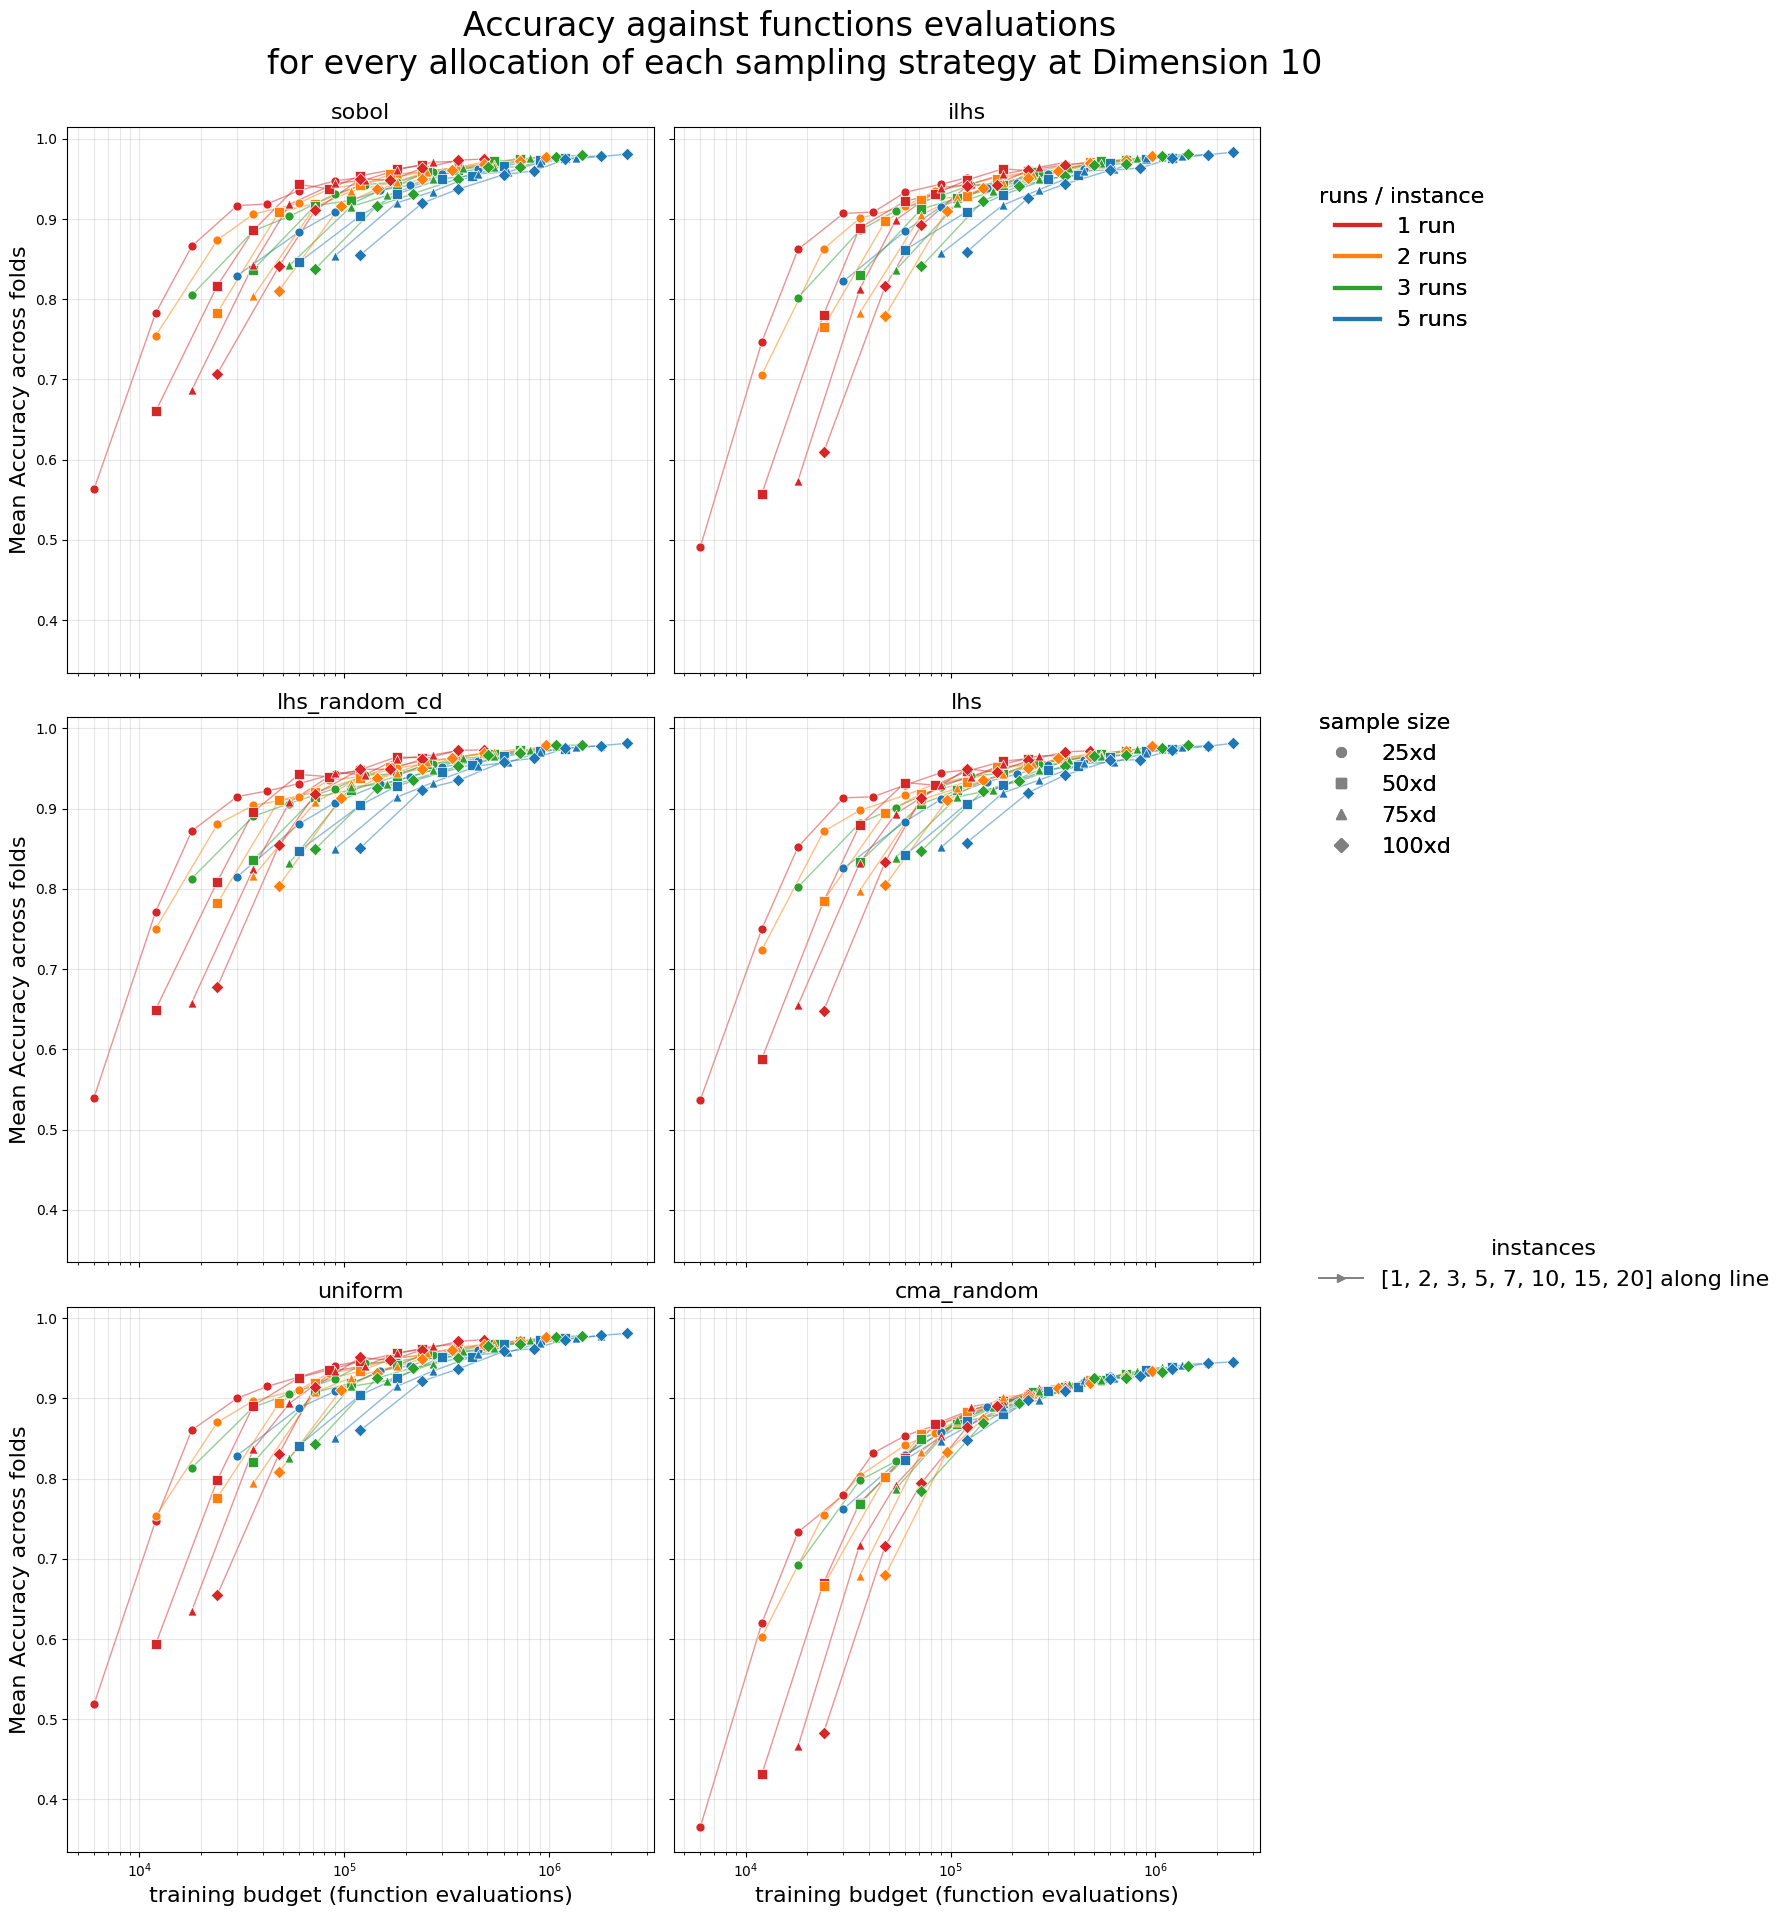

In [43]:
cp.plot_allocation_scatter(df, 10, logx=True, width_per=8, height_per=6.5)        # C10 — within sampler


(<Figure size 900x580 with 1 Axes>,
 <Axes: title={'center': 'Efficient frontier per sampler  [dim 2]\nhorizontal gap = extra budget for the same accuracy'}, xlabel='training budget (function evaluations)', ylabel='acc_all_runs'>)

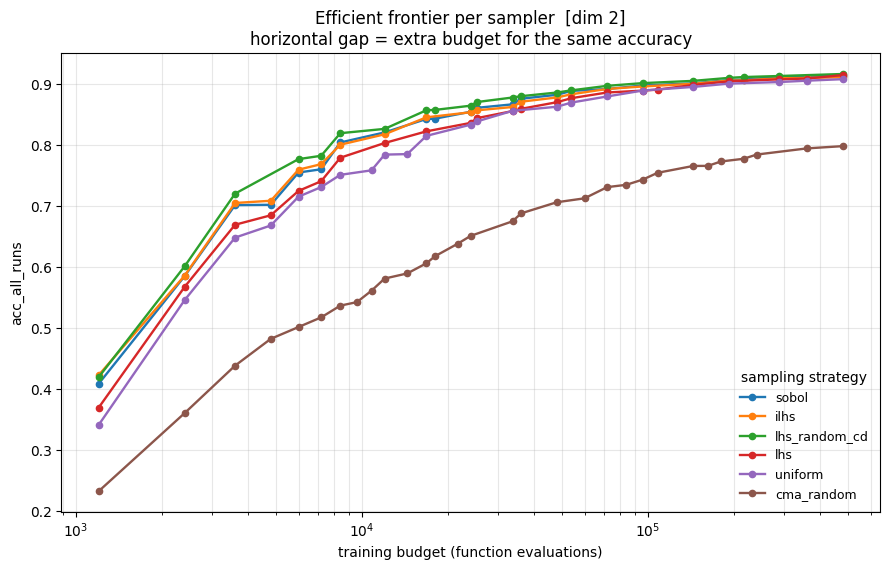

In [44]:
cp.plot_frontier_by_strategy(df, 2, show_cloud=False)      # C11 — between samplers

(<Figure size 900x580 with 1 Axes>,
 <Axes: title={'center': 'Efficient frontier per sampler  [dim 5]\nhorizontal gap = extra budget for the same accuracy'}, xlabel='training budget (function evaluations)', ylabel='acc_all_runs'>)

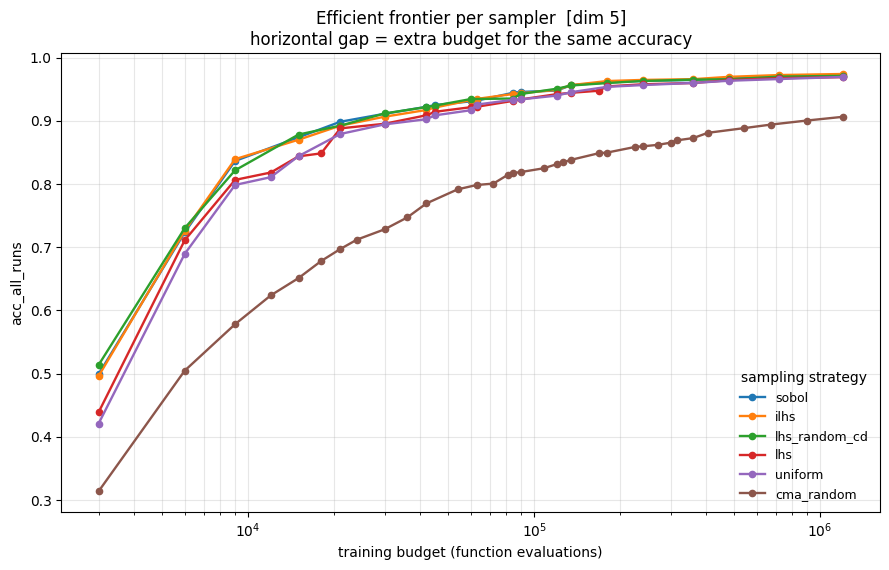

In [45]:
cp.plot_frontier_by_strategy(df, 5, show_cloud=False)      # C11 — between samplers


(<Figure size 900x580 with 1 Axes>,
 <Axes: title={'center': 'Efficient frontier per sampler  [dim 10]\nhorizontal gap = extra budget for the same accuracy'}, xlabel='training budget (function evaluations)', ylabel='acc_all_runs'>)

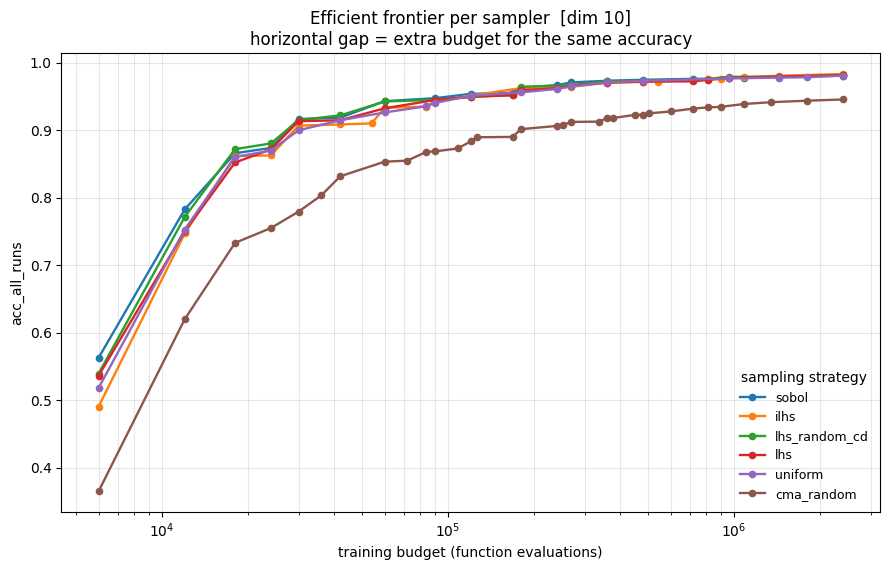

In [46]:
cp.plot_frontier_by_strategy(df, 10, show_cloud=False)      # C11 — between samplers


In [47]:
df.query("dimension==2 and n_runs_train==1")["fold_acc_all_runs_std"].describe()

count    192.000000
mean       0.013556
std        0.008429
min        0.001282
25%        0.007032
50%        0.011052
75%        0.020094
max        0.041668
Name: fold_acc_all_runs_std, dtype: float64

In [48]:
sub = df.query("dimension == 5 and n_instances_train == 3 and strategy != 'cma_random'")
sub.pivot_table(index="size", columns="n_runs_train", values="acc_all_runs", aggfunc="max")

n_runs_train,1,2,3,5
size,,,,
25,0.839267,0.855781,0.872128,0.868594
50,0.873583,0.885163,0.892813,0.891399
75,0.880576,0.903194,0.904163,0.900469
100,0.895087,0.909170,0.912705,0.903552


In [49]:
cp.factor_importance(df.query("n_instances_train == 3 and strategy != 'cma_random'"), dimension=2)

Variance in acc_all_runs explained (dim 2, 80 grid points)
factor                       raw   budget-controlled   levels
strategy                   6.0%              16.6%        5
size                      57.0%              14.9%        4
n_instances_train          0.0%               0.0%        1
n_runs_train              30.6%              50.4%        4
_residual                  6.5%              18.1%

  raw        = includes total budget, so the wide-range factors dominate
  controlled = log(budget) regressed out, so this is the ALLOCATION effect


,factor,eta2_raw,eta2_budget_controlled,n_levels
0,strategy,0.059561,0.165683,5.0
1,size,0.569581,0.149499,4.0
2,n_instances_train,0.000000,0.000000,1.0
3,n_runs_train,0.305829,0.503921,4.0
4,_residual,0.065030,0.180897,NaN


dim 2 — noise against accuracy (640 configurations)

  pooled Spearman rho          : -0.155   <- CONFOUNDED by sample size
  within (size, inst, runs)    : median -0.800, mean -0.697  (n = 128 groups)
  groups with rho > 0          : 5%
  median accuracy spread across strategies within a group: 0.0201

  A negative rho means LESS noise goes with HIGHER accuracy.
  Compare the spread against the SEM (~0.006): if it is of the same order,
  the strategies are not separable within a group whatever the sign of rho.

dim 5 — noise against accuracy (640 configurations)

  pooled Spearman rho          : -0.155   <- CONFOUNDED by sample size
  within (size, inst, runs)    : median -0.800, mean -0.744  (n = 128 groups)
  groups with rho > 0          : 3%
  median accuracy spread across strategies within a group: 0.0113

  A negative rho means LESS noise goes with HIGHER accuracy.
  Compare the spread against the SEM (~0.006): if it is of the same order,
  the strategies are not separable within

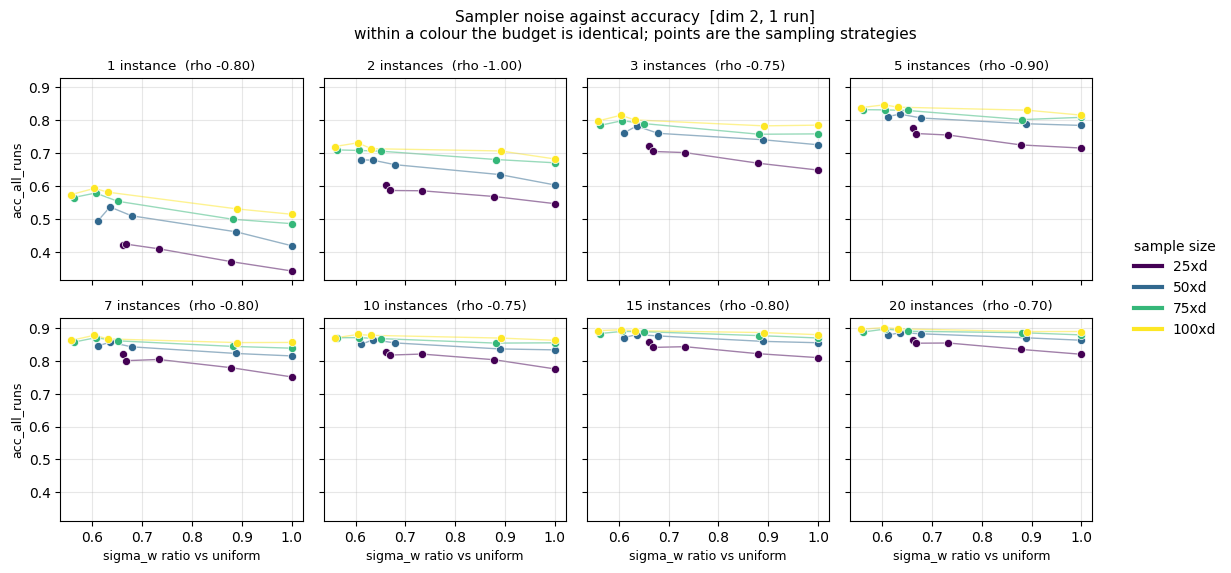

In [50]:
r_all = pd.concat([r, r5, r10], ignore_index=True)

for dim in (2, 5, 10):
    m, summary = cp.noise_vs_accuracy(df, r_all, dim)
    print()

_ = cp.plot_noise_vs_accuracy(df, r_all, dimension=2)

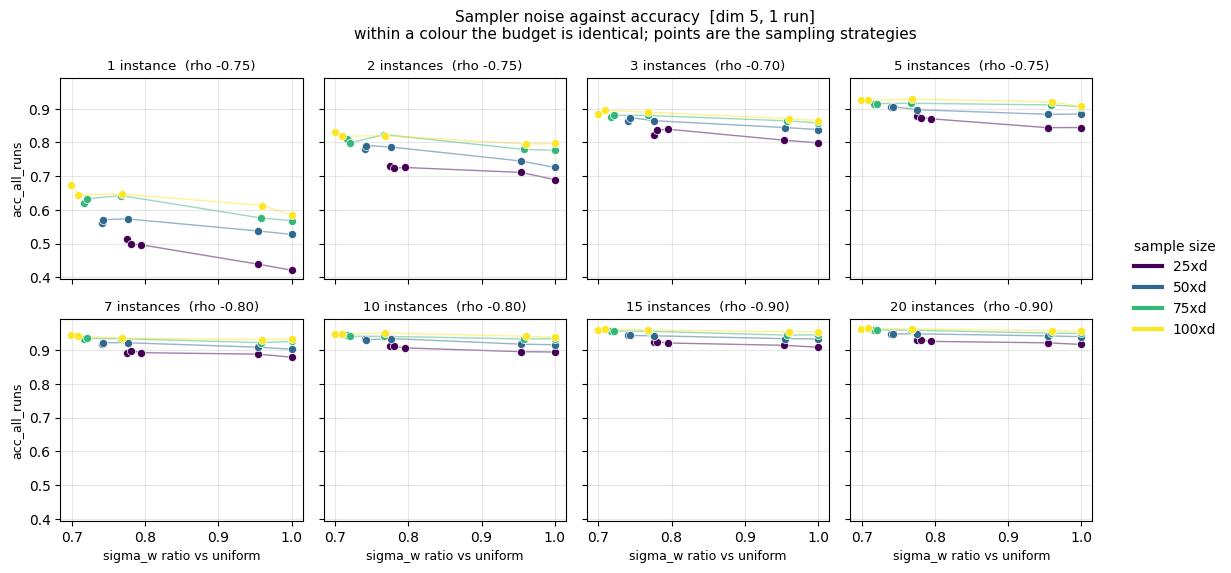

In [51]:
_ = cp.plot_noise_vs_accuracy(df, r_all, dimension=5)


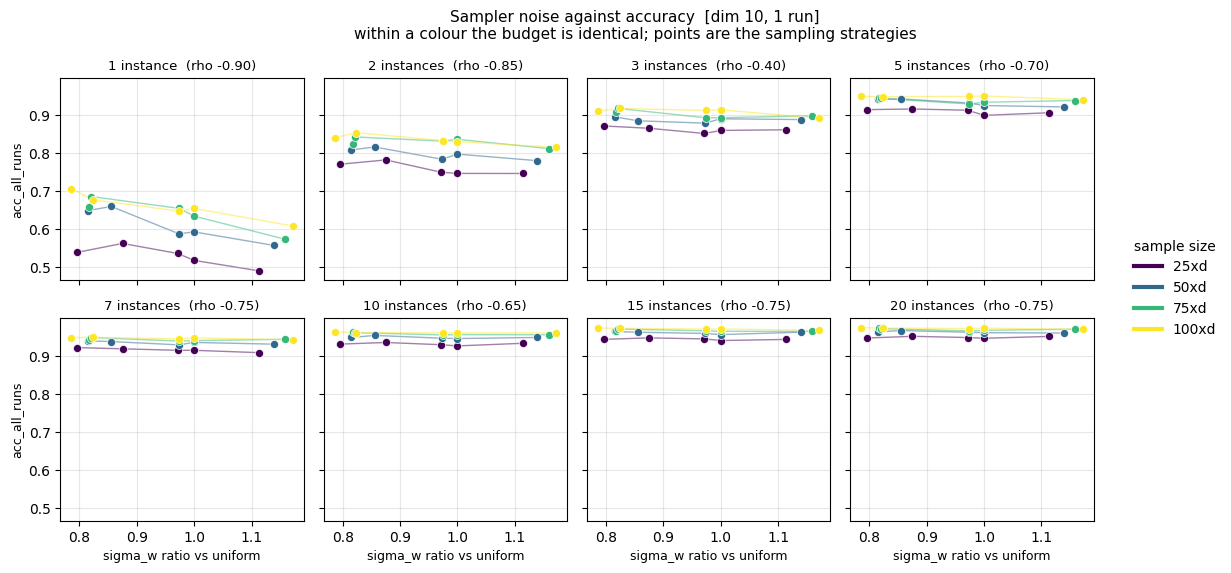

In [52]:
_ = cp.plot_noise_vs_accuracy(df, r_all, dimension=10)


standard error of the reported accuracy (2,304 configs)

  median 0.0044   mean 0.0055   IQR 0.0026–0.0074   max 0.0213
  a difference is interpretable at roughly 2*sqrt(2)*SEM = 0.0124

  by n_instances_train:
           1: 0.0112
           2: 0.0087
           3: 0.0064
           5: 0.0052
           7: 0.0039
          10: 0.0029
          15: 0.0024
          20: 0.0023
standard error of the reported accuracy (2,304 configs)

  median 0.0044   mean 0.0055   IQR 0.0026–0.0074   max 0.0213
  a difference is interpretable at roughly 2*sqrt(2)*SEM = 0.0124

  by dimension:
           2: 0.0050
           5: 0.0039
          10: 0.0038


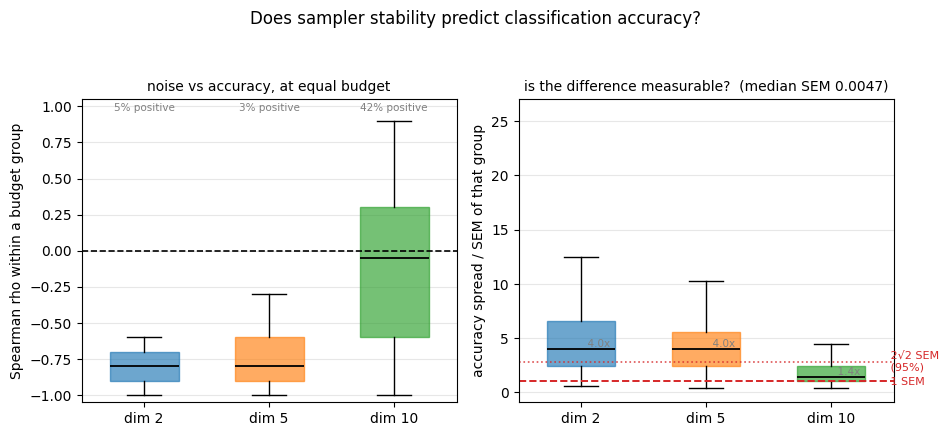

In [53]:
cp.sem_report(df, by="n_instances_train")     # the numbers for your methods section
cp.sem_report(df, by="dimension")
_ = cp.plot_noise_accuracy_summary(df, r_all)  # now uses per-group SEM

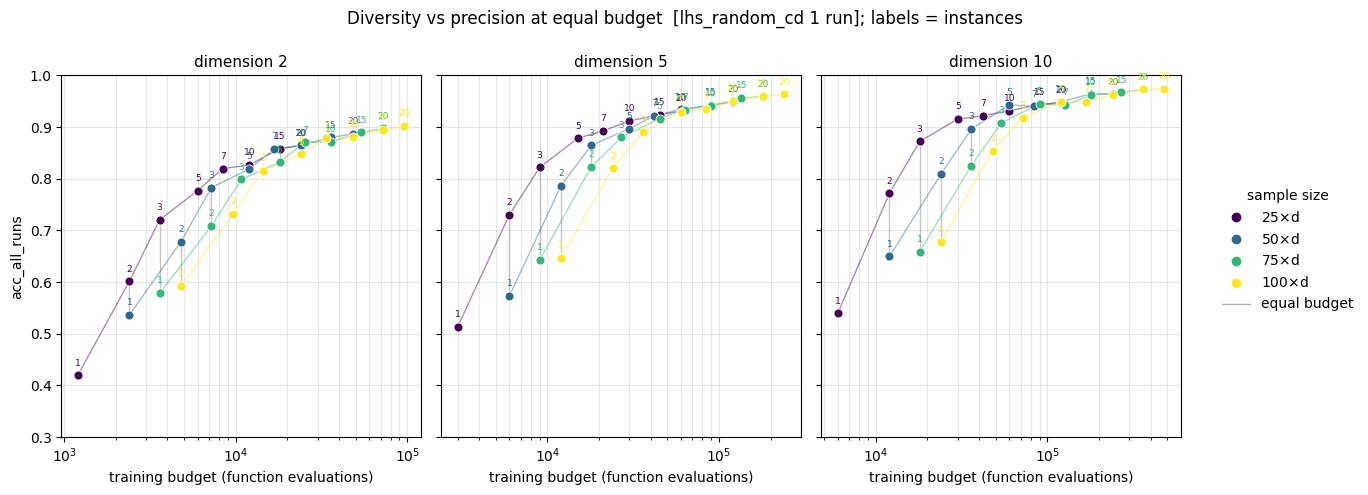

In [54]:
_ = cp.plot_instances_vs_size_grid(df, dimensions=(2, 5, 10),
                                   strategy="lhs_random_cd",
                                   n_runs_train=1, ylim=ylim)

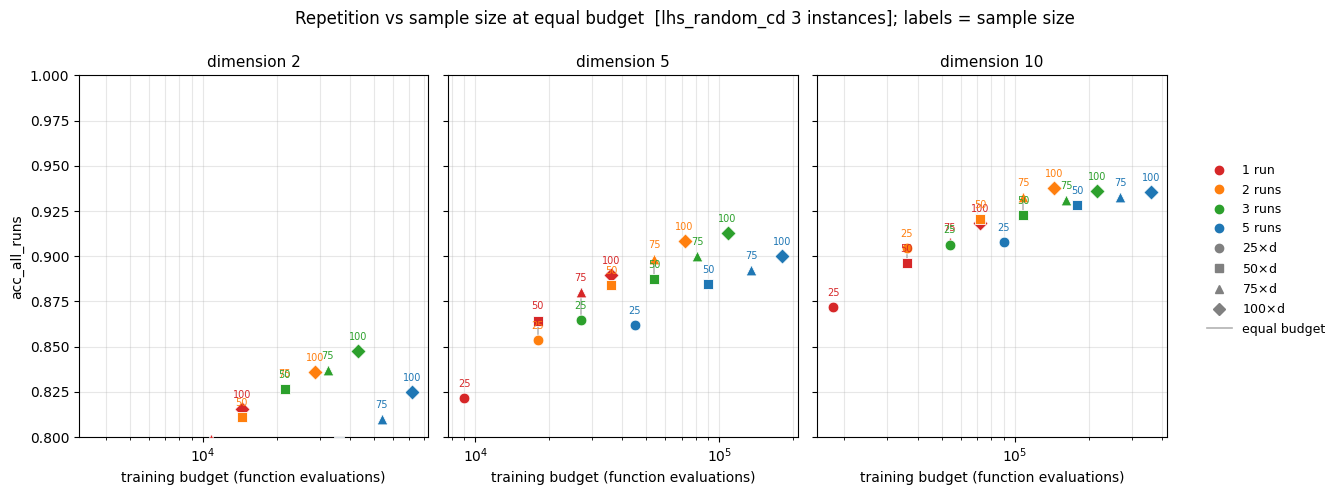

In [55]:
_ = cp.plot_runs_vs_size_grid(df, strategy="lhs_random_cd",
                              n_instances_train=3, ylim=(0.8, 1.0))

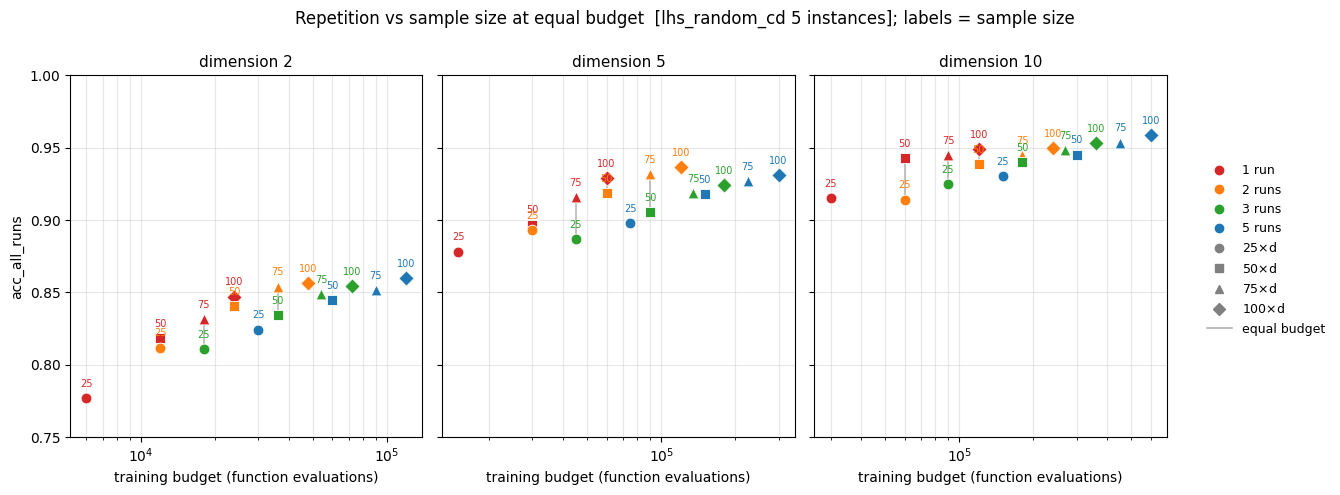

In [56]:
_ = cp.plot_runs_vs_size_grid(df, strategy="lhs_random_cd",
                              n_instances_train=5, ylim=(0.75, 1.0))

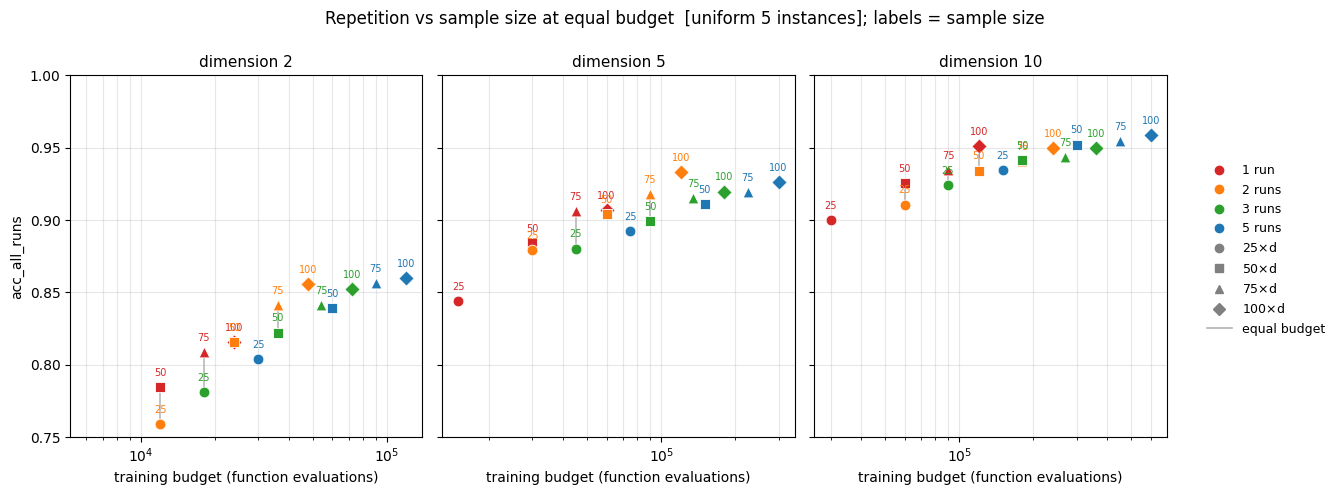

In [57]:
_ = cp.plot_runs_vs_size_grid(df, strategy="uniform",
                              n_instances_train=5, ylim=(0.75, 1.0))

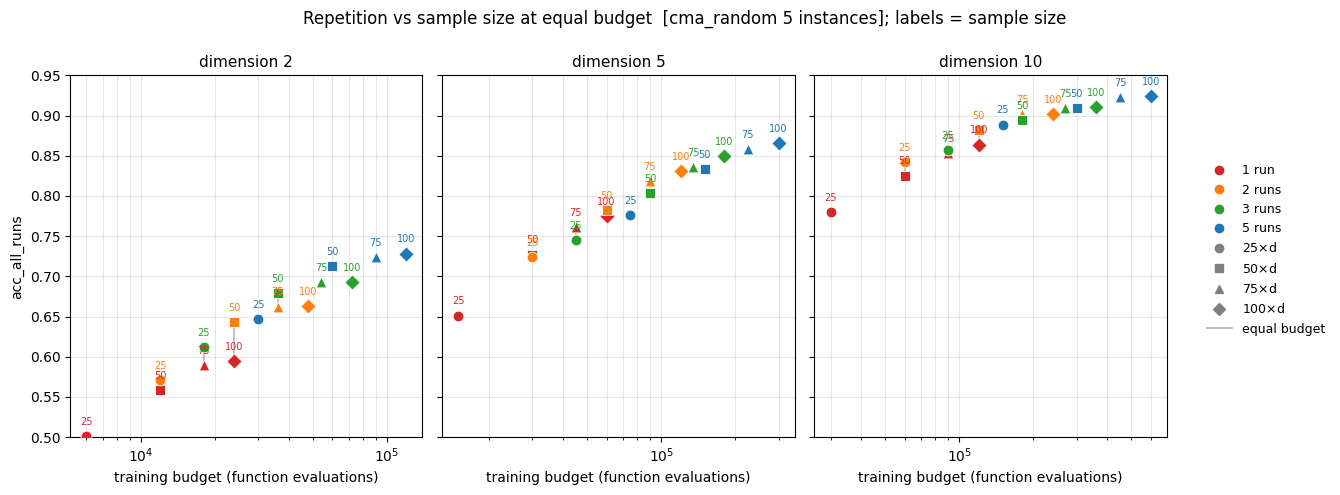

In [58]:
_ = cp.plot_runs_vs_size_grid(df, strategy="cma_random",
                              n_instances_train=5, ylim=(0.5, 0.95))

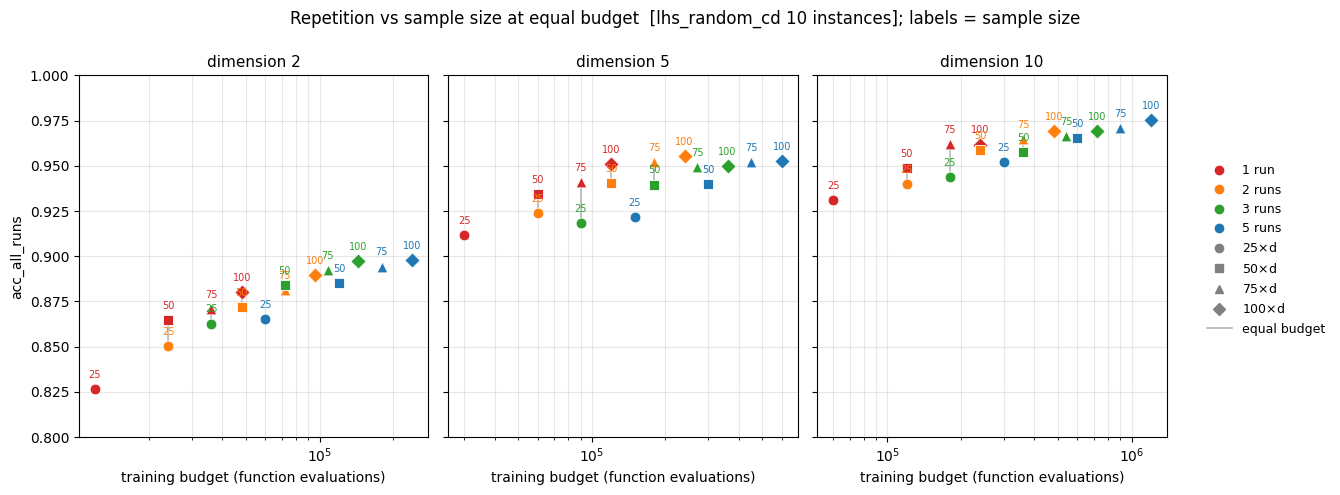

In [59]:
_ = cp.plot_runs_vs_size_grid(df, strategy="lhs_random_cd",
                              n_instances_train=10, ylim=(0.8, 1.0))

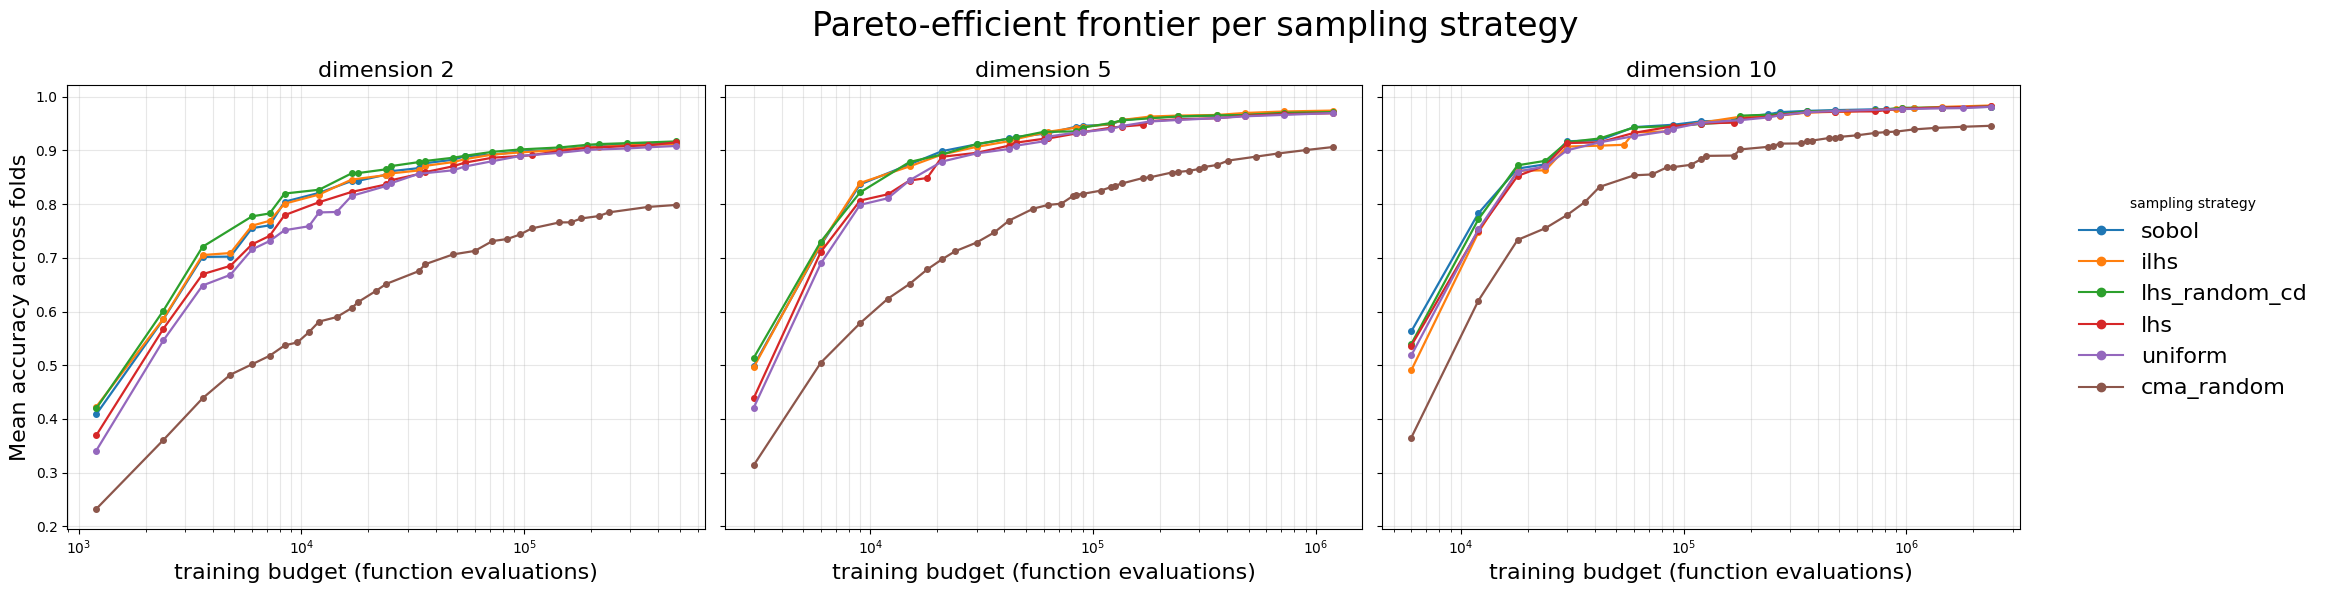

In [60]:
_ = cp.plot_frontier_by_strategy_grid(df, dimensions=(2, 5, 10), width_per=8, height=6)

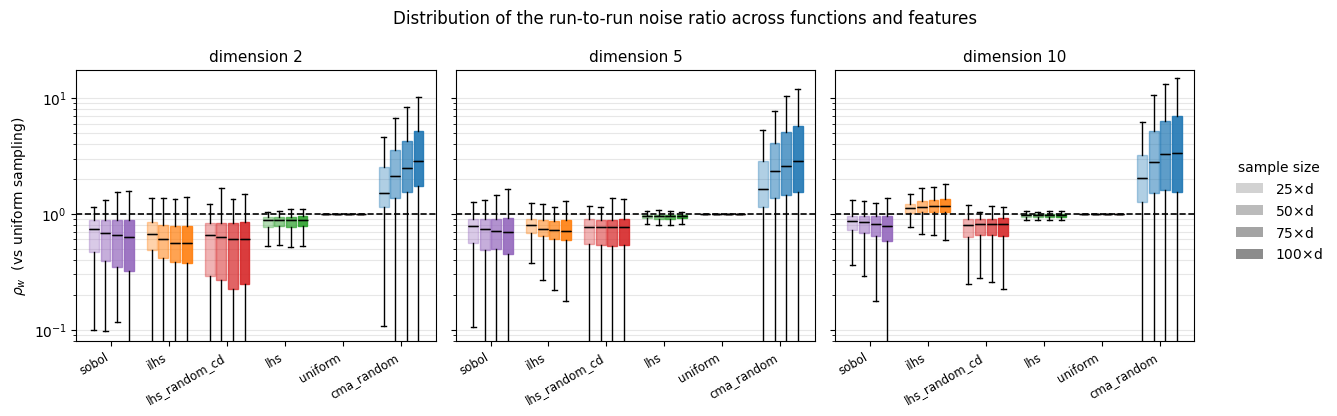

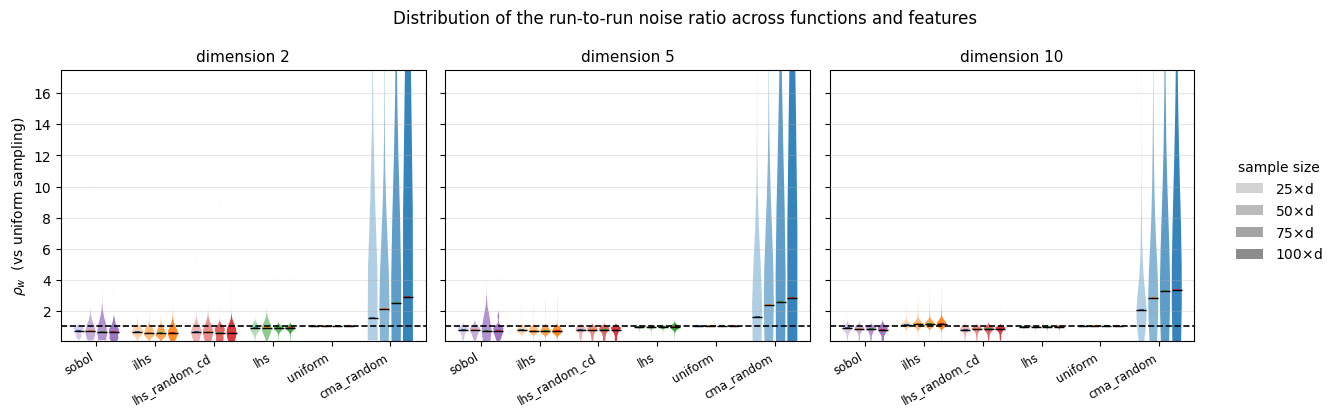

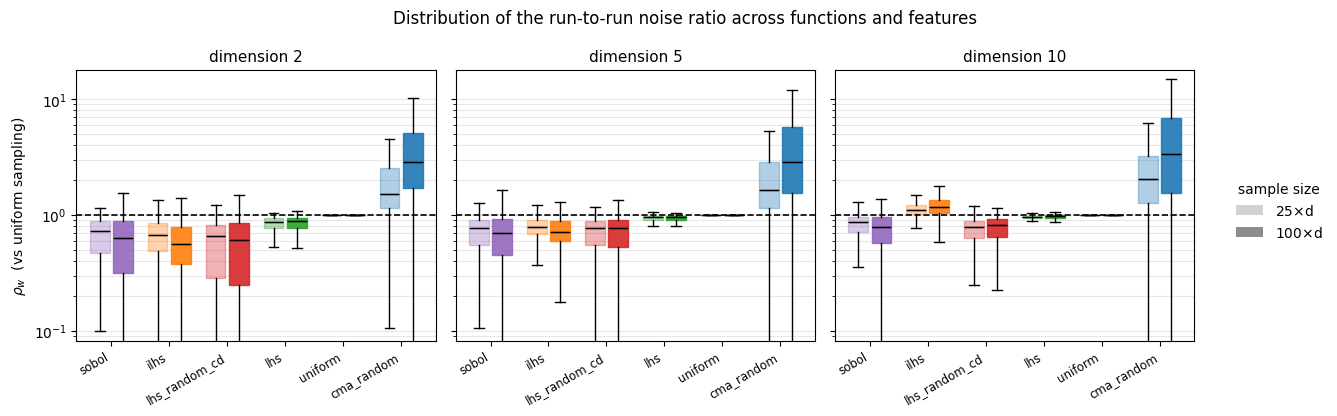

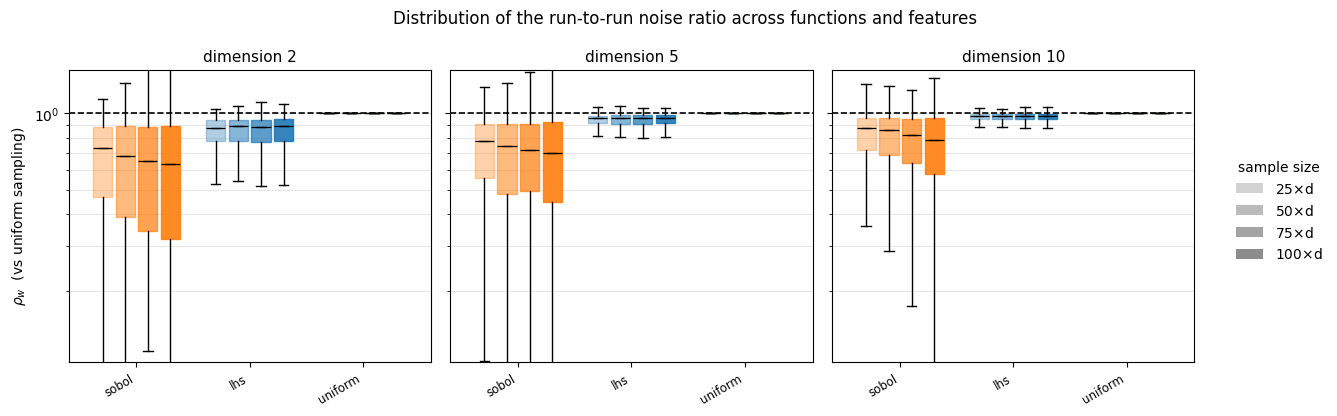

In [61]:
_ = ia.plot_ratio_w_distribution(r_all)                              # all three dimensions
_ = ia.plot_ratio_w_distribution(r_all, kind="violin", logy=False, )               # shape rather than quartiles
_ = ia.plot_ratio_w_distribution(r_all, sizes=[25, 100])             # just the extremes
_ = ia.plot_ratio_w_distribution(r_all, strategies=["sobol", "lhs", "uniform"])

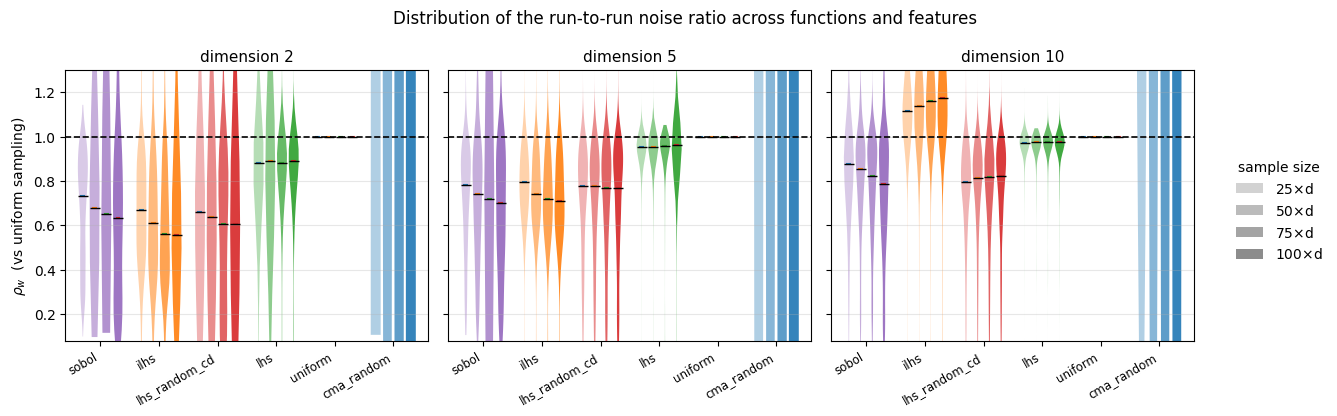

In [62]:
_ = ia.plot_ratio_w_distribution(r_all, kind="violin", logy=False,clip_pct=(1, 60))               # shape rather than quartiles


In [63]:
piv = (r_all.groupby(["dimension", "strategy", "size"])["ratio_w"]
       .median().unstack())
print(piv.round(3).to_string())

size                       25     50     75     100
dimension strategy                                 
2         cma_random     1.526  2.104  2.492  2.866
          ilhs           0.668  0.611  0.563  0.558
          lhs            0.879  0.889  0.882  0.891
          lhs_random_cd  0.661  0.636  0.607  0.604
          sobol          0.733  0.679  0.651  0.632
          uniform        1.000  1.000  1.000  1.000
5         cma_random     1.641  2.350  2.601  2.859
          ilhs           0.795  0.741  0.721  0.709
          lhs            0.954  0.954  0.958  0.960
          lhs_random_cd  0.776  0.776  0.767  0.768
          sobol          0.781  0.743  0.717  0.699
          uniform        1.000  1.000  1.000  1.000
10        cma_random     2.053  2.806  3.256  3.354
          ilhs           1.114  1.139  1.159  1.172
          lhs            0.972  0.973  0.974  0.974
          lhs_random_cd  0.796  0.815  0.817  0.824
          sobol          0.875  0.856  0.821  0.786
          un

In [64]:
d = r_all.query("dimension == 5 and size == 100 and strategy == 'sobol'")
print("by function:", d.groupby("func")["ratio_w"].median().describe()[["min","max"]].round(3).to_dict())
print("by feature :", d.groupby("feature")["ratio_w"].median().describe()[["min","max"]].round(3).to_dict())

by function: {'min': 0.396, 'max': 1.001}
by feature : {'min': 0.156, 'max': 3.162}


<StringArray>
[                 'ela_distr.skewness',                  'ela_distr.kurtosis',
          'ela_meta.lin_simple.adj_r2',       'ela_meta.lin_simple.intercept',
        'ela_meta.lin_simple.coef.min',        'ela_meta.lin_simple.coef.max',
      'ela_meta.lin_w_interact.adj_r2',                  'disp.ratio_mean_02',
                  'disp.ratio_mean_05',                  'disp.ratio_mean_10',
                  'disp.ratio_mean_25',                'disp.ratio_median_02',
                'disp.ratio_median_05',                'disp.ratio_median_10',
                'disp.ratio_median_25',                   'disp.diff_mean_02',
                   'disp.diff_mean_05',                   'disp.diff_mean_10',
                   'disp.diff_mean_25',                 'disp.diff_median_02',
                 'disp.diff_median_05',                 'disp.diff_median_10',
                 'disp.diff_median_25',                  'nbc.nn_nb.sd_ratio',
                'nbc.nn_nb.mean_ratio'

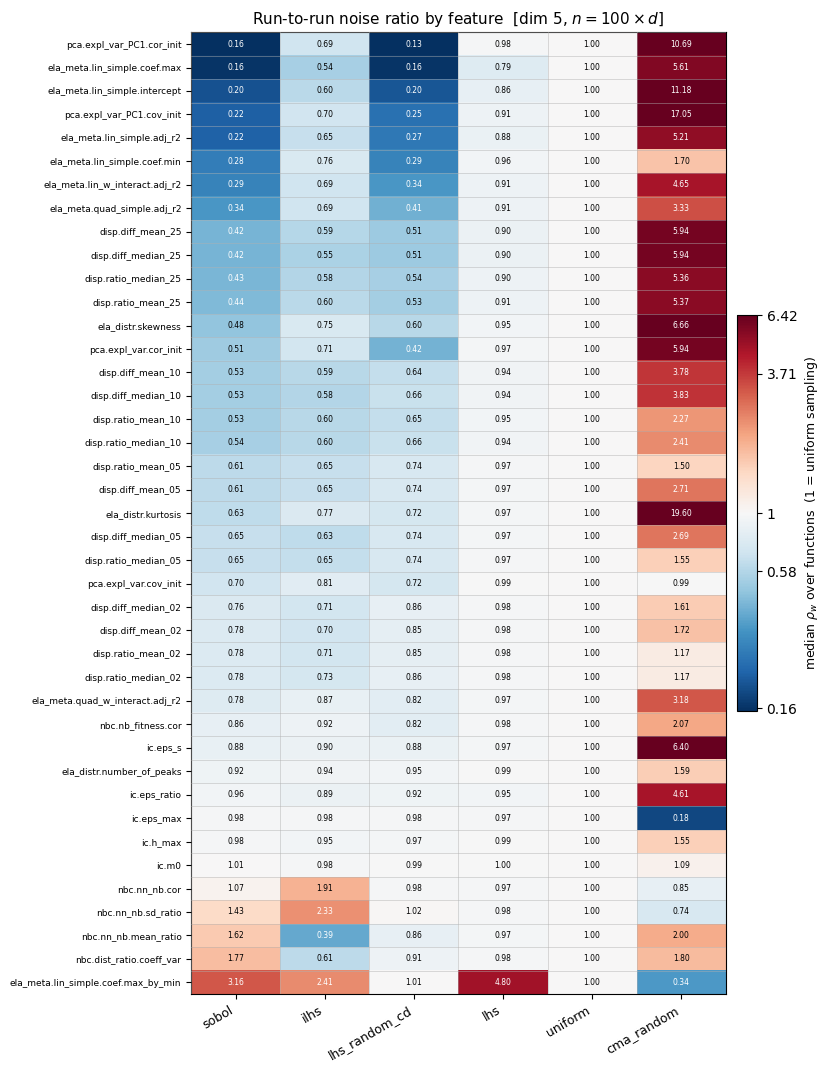

In [65]:

_ = ia.heatmap_ratio_w_by_feature(r_all, 5, 100, annotate=True)   # values in cells

<StringArray>
[                 'ela_distr.skewness',                  'ela_distr.kurtosis',
           'ela_distr.number_of_peaks',          'ela_meta.lin_simple.adj_r2',
       'ela_meta.lin_simple.intercept',        'ela_meta.lin_simple.coef.min',
        'ela_meta.lin_simple.coef.max',      'ela_meta.lin_w_interact.adj_r2',
                  'disp.ratio_mean_25',                'disp.ratio_median_25',
                   'disp.diff_mean_25',                  'nbc.nb_fitness.cor',
                            'ic.h_max',                            'ic.eps_s',
                          'ic.eps_max',                               'ic.m0',
               'pca.expl_var.cov_init',               'pca.expl_var.cor_init',
           'pca.expl_var_PC1.cov_init',           'pca.expl_var_PC1.cor_init',
         'ela_meta.quad_simple.adj_r2',     'ela_meta.quad_w_interact.adj_r2',
                  'disp.ratio_mean_05',                  'disp.ratio_mean_10',
                'disp.ratio_median_05'

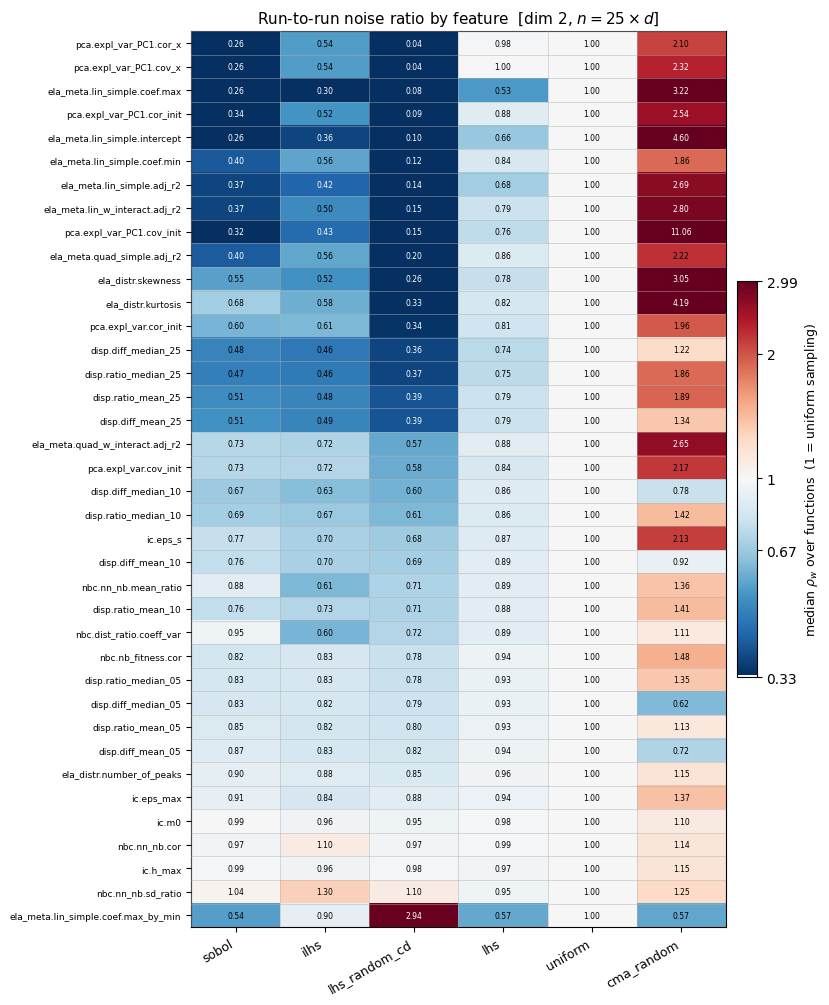

In [66]:
_ = ia.heatmap_ratio_w_by_feature(r_all, 2, 25, annotate=True, sort_by="lhs_random_cd")   # values in cells

<StringArray>
[                 'ela_distr.skewness',                  'ela_distr.kurtosis',
          'ela_meta.lin_simple.adj_r2',       'ela_meta.lin_simple.intercept',
        'ela_meta.lin_simple.coef.min',        'ela_meta.lin_simple.coef.max',
      'ela_meta.lin_w_interact.adj_r2',                  'disp.ratio_mean_02',
                  'disp.ratio_mean_05',                  'disp.ratio_mean_10',
                  'disp.ratio_mean_25',                'disp.ratio_median_05',
                'disp.ratio_median_10',                'disp.ratio_median_25',
                   'disp.diff_mean_02',                   'disp.diff_mean_05',
                   'disp.diff_mean_10',                   'disp.diff_mean_25',
                 'disp.diff_median_05',                 'disp.diff_median_10',
                 'disp.diff_median_25',                  'nbc.nn_nb.sd_ratio',
                'nbc.nn_nb.mean_ratio',            'nbc.dist_ratio.coeff_var',
                  'nbc.nb_fitness.cor'

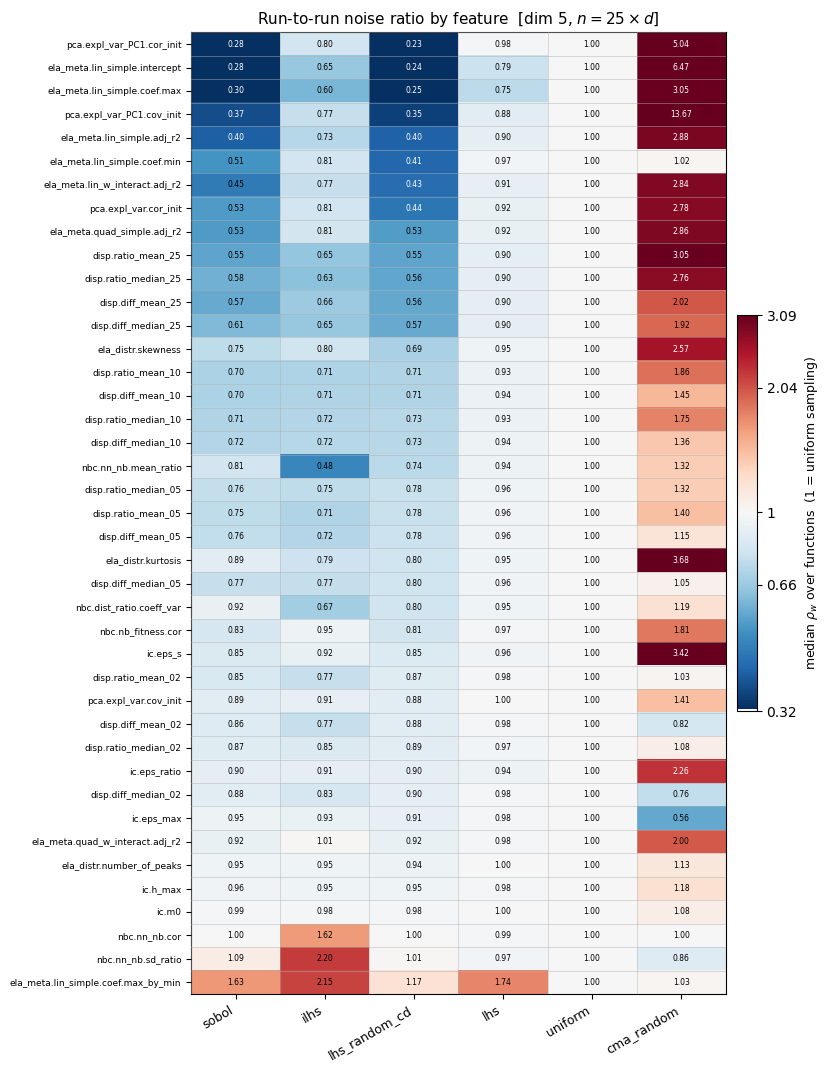

In [67]:
_ = ia.heatmap_ratio_w_by_feature(r_all, 5, 25, annotate=True, sort_by="lhs_random_cd")   # values in cells


<StringArray>
[                 'ela_distr.skewness',                  'ela_distr.kurtosis',
          'ela_meta.lin_simple.adj_r2',       'ela_meta.lin_simple.intercept',
        'ela_meta.lin_simple.coef.min',        'ela_meta.lin_simple.coef.max',
      'ela_meta.lin_w_interact.adj_r2',                  'disp.ratio_mean_02',
                  'disp.ratio_mean_05',                  'disp.ratio_mean_10',
                  'disp.ratio_mean_25',                'disp.ratio_median_02',
                'disp.ratio_median_05',                'disp.ratio_median_10',
                'disp.ratio_median_25',                   'disp.diff_mean_02',
                   'disp.diff_mean_05',                   'disp.diff_mean_10',
                   'disp.diff_mean_25',                 'disp.diff_median_02',
                 'disp.diff_median_05',                 'disp.diff_median_10',
                 'disp.diff_median_25',                  'nbc.nn_nb.sd_ratio',
                'nbc.nn_nb.mean_ratio'

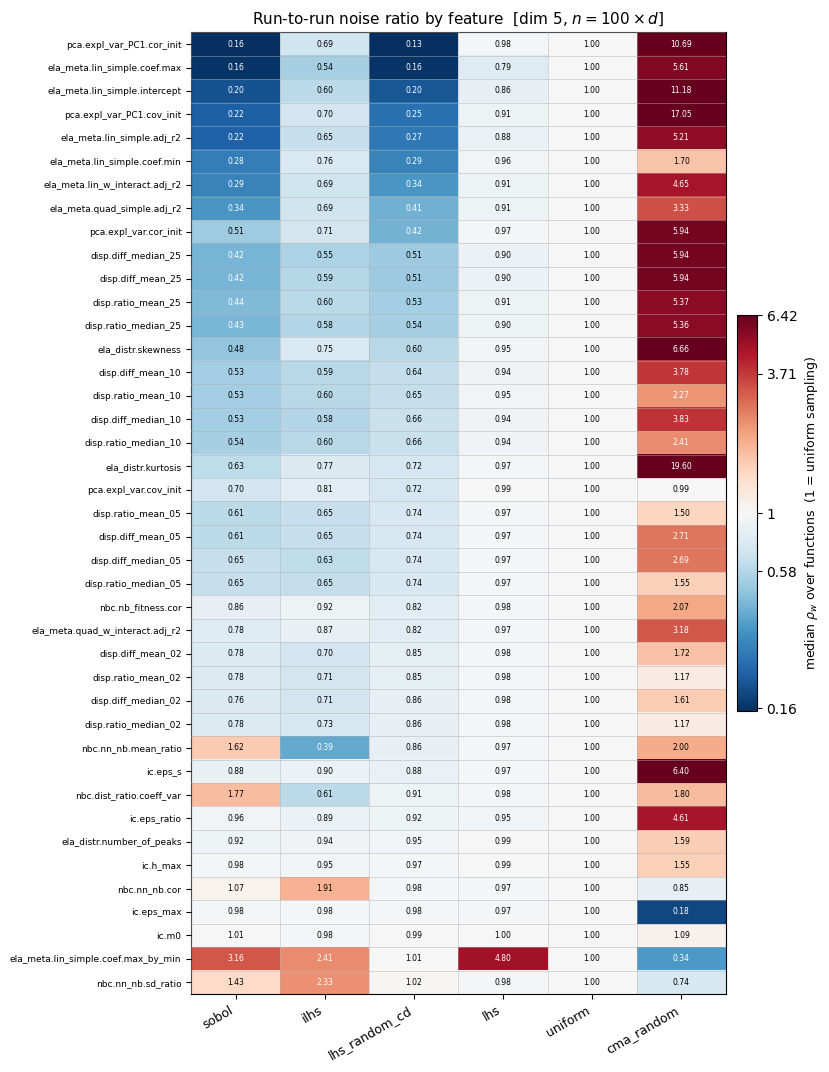

In [68]:
_ = ia.heatmap_ratio_w_by_feature(r_all, 5, 100, annotate=True, sort_by="lhs_random_cd")   # values in cells


<StringArray>
[                 'ela_distr.skewness',          'ela_meta.lin_simple.adj_r2',
       'ela_meta.lin_simple.intercept',        'ela_meta.lin_simple.coef.min',
        'ela_meta.lin_simple.coef.max',      'ela_meta.lin_w_interact.adj_r2',
                  'disp.ratio_mean_02',                  'disp.ratio_mean_05',
                  'disp.ratio_mean_10',                  'disp.ratio_mean_25',
                'disp.ratio_median_02',                'disp.ratio_median_05',
                'disp.ratio_median_10',                'disp.ratio_median_25',
                   'disp.diff_mean_02',                   'disp.diff_mean_05',
                   'disp.diff_mean_10',                   'disp.diff_mean_25',
                 'disp.diff_median_02',                 'disp.diff_median_05',
                 'disp.diff_median_10',                 'disp.diff_median_25',
                  'nbc.nn_nb.sd_ratio',                'nbc.nn_nb.mean_ratio',
                       'nbc.nn_nb.cor'

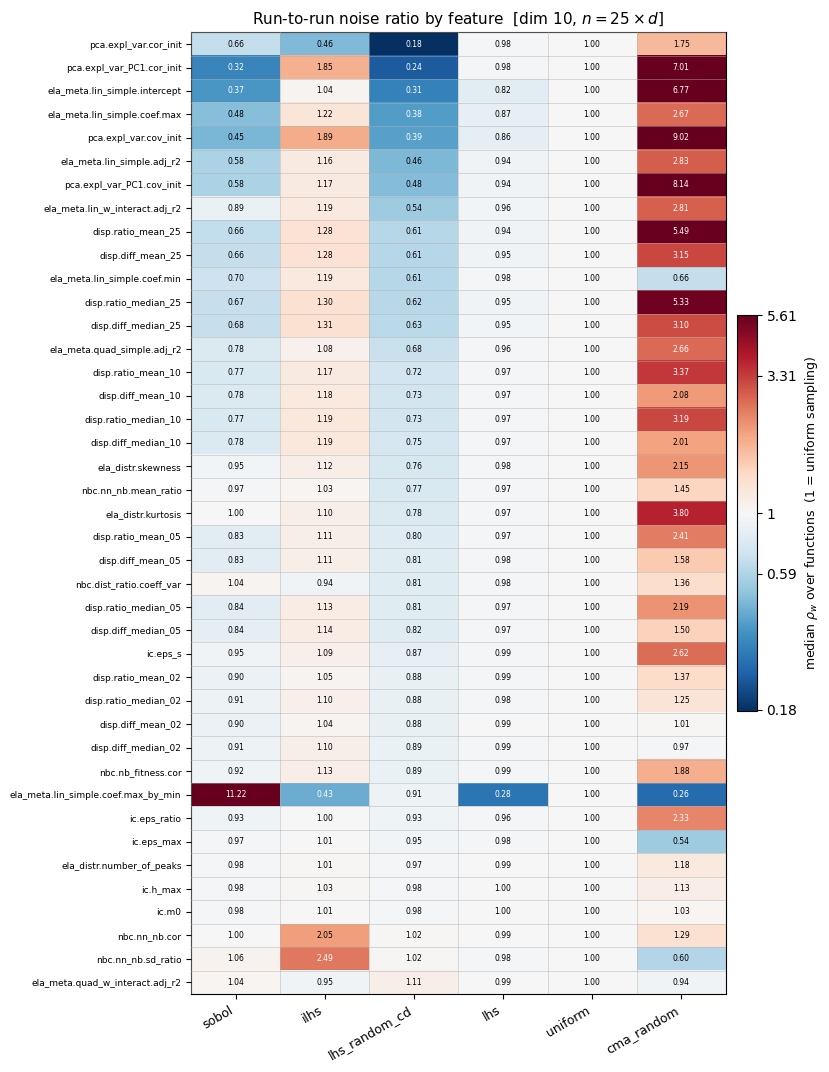

In [69]:
_ = ia.heatmap_ratio_w_by_feature(r_all, 10, 25, annotate=True, sort_by="lhs_random_cd")   # values in cells


<StringArray>
[                 'ela_distr.skewness',                  'ela_distr.kurtosis',
          'ela_meta.lin_simple.adj_r2',       'ela_meta.lin_simple.intercept',
        'ela_meta.lin_simple.coef.min',        'ela_meta.lin_simple.coef.max',
 'ela_meta.lin_simple.coef.max_by_min',      'ela_meta.lin_w_interact.adj_r2',
                  'disp.ratio_mean_02',                  'disp.ratio_mean_05',
                  'disp.ratio_mean_10',                  'disp.ratio_mean_25',
                'disp.ratio_median_02',                'disp.ratio_median_05',
                'disp.ratio_median_10',                'disp.ratio_median_25',
                   'disp.diff_mean_02',                   'disp.diff_mean_05',
                   'disp.diff_mean_10',                   'disp.diff_mean_25',
                 'disp.diff_median_02',                 'disp.diff_median_05',
                 'disp.diff_median_10',                 'disp.diff_median_25',
                  'nbc.nn_nb.sd_ratio'

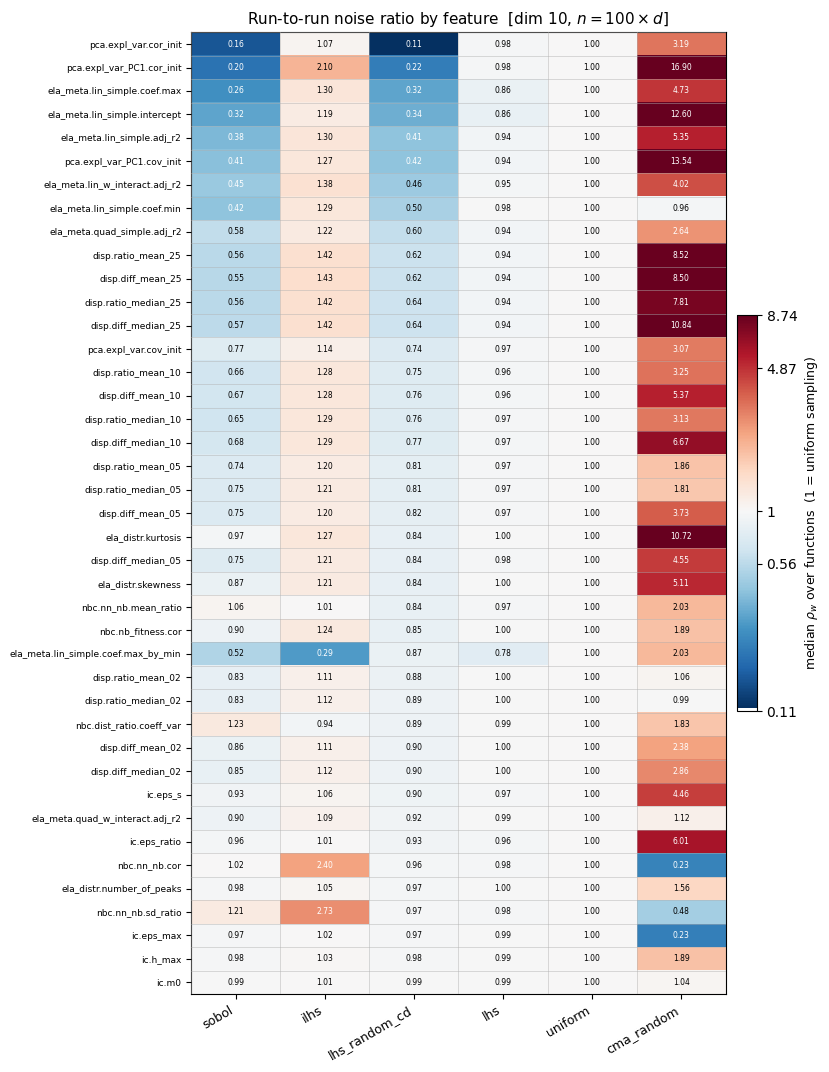

In [70]:
_ = ia.heatmap_ratio_w_by_feature(r_all, 10, 100, annotate=True, sort_by="lhs_random_cd")   # values in cells


In [71]:
tab = ia.prepare(icc_df, verbose=False)
sc  = ia.scope_comparable(tab, mode="all", verbose=False)
for name, fr in [("prepared", tab), ("scoped", sc), ("ratios", r_all)]:
    print(f"{name:10s} {fr.feature.nunique():3d} features")
print("\nlost at scoping:", sorted(set(tab.feature) - set(sc.feature)))
print("lost at ratios :", sorted(set(sc.feature) - set(r_all.feature)))

prepared    40 features
scoped      40 features
ratios      43 features

lost at scoping: []
lost at ratios : ['pca.expl_var.cor_x', 'pca.expl_var.cov_x']


In [72]:
icc_all = pd.concat([icc_df, icc5, icc10], ignore_index=True)   # your three ratio frames
tab = ia.prepare(icc_all, verbose=False)     # all three dims
for d in (2, 5, 10):
    t = set(tab.query("dimension == @d").feature)
    r = set(r_all.query("dimension == @d").feature)
    print(f"dim {d}: prepared {len(t)}, ratios {len(r)}, lost: {sorted(t - r)}")

dim 2: prepared 40, ratios 38, lost: ['pca.expl_var.cor_x', 'pca.expl_var.cov_x']
dim 5: prepared 45, ratios 41, lost: ['pca.expl_var.cor_x', 'pca.expl_var.cov_x', 'pca.expl_var_PC1.cor_x', 'pca.expl_var_PC1.cov_x']
dim 10: prepared 45, ratios 43, lost: ['pca.expl_var.cor_x', 'pca.expl_var.cov_x']


In [73]:
z = tab.query("dimension == 5 and strategy == 'uniform' and "
              "feature == 'pca.expl_var.cor_x'")
print(z[["sigma2_within", "grand_mean", "n_unique_values"]].describe().round(6))

       sigma2_within  grand_mean  n_unique_values
count       3.000000    3.000000        96.000000
mean        0.000013    0.999933         0.062500
std         0.000000    0.000000         0.349812
min         0.000013    0.999933         0.000000
25%         0.000013    0.999933         0.000000
50%         0.000013    0.999933         0.000000
75%         0.000013    0.999933         0.000000
max         0.000013    0.999933         2.000000


In [74]:
d10 = set(r_all.query("dimension == 10").feature)
at100 = set(r_all.query("dimension == 10 and size == 100").feature)
print(sorted(d10 - at100))

['pca.expl_var_PC1.cor_x', 'pca.expl_var_PC1.cov_x']


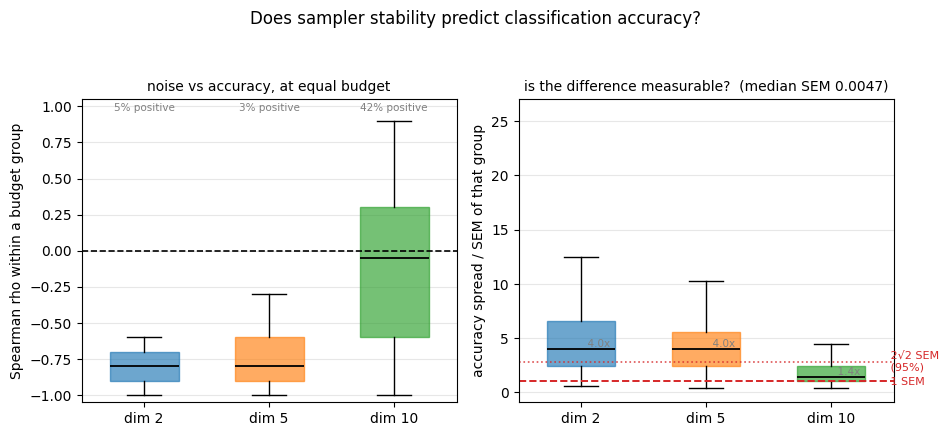

In [75]:
_ = cp.plot_noise_accuracy_summary(df, r_all, dimensions=(2, 5, 10))

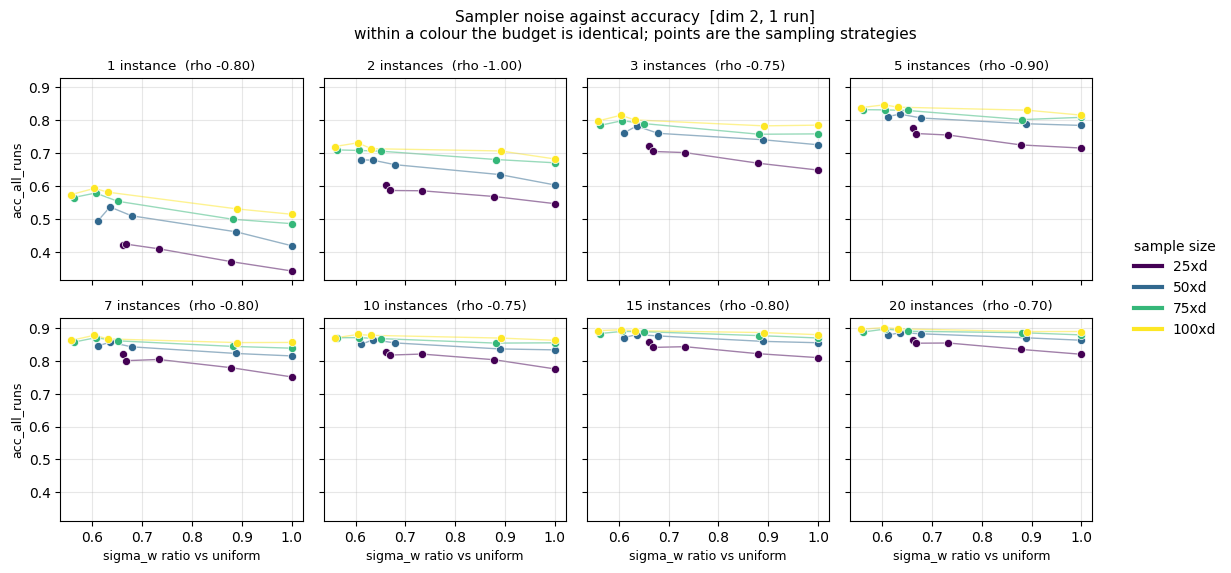

In [76]:
_ = cp.plot_noise_vs_accuracy(df, r_all, dimension=2, n_runs_train=1)


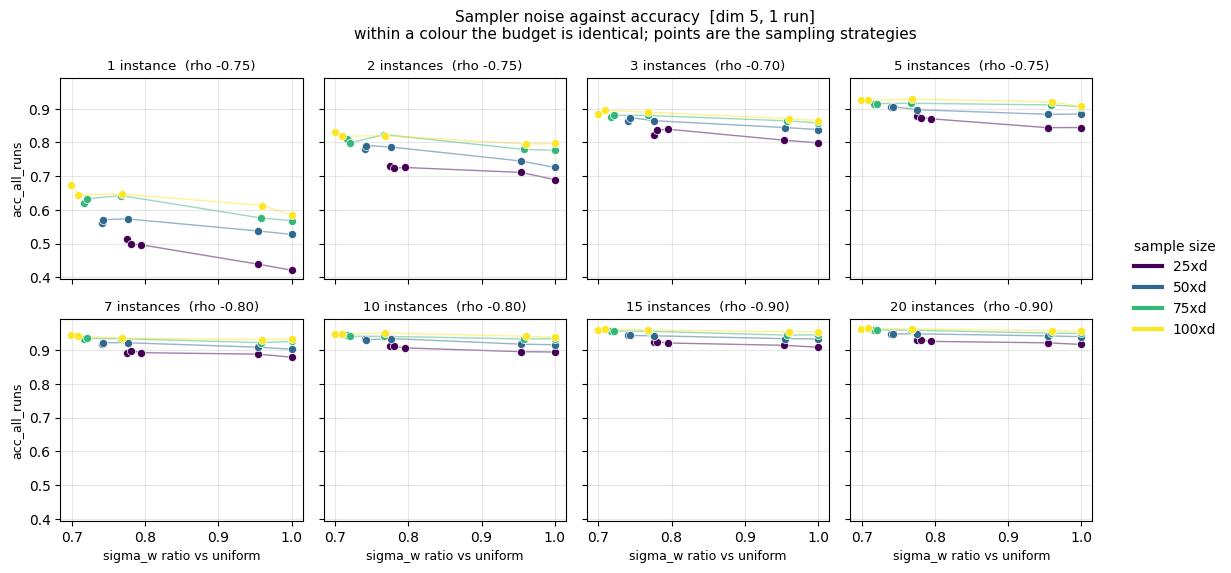

In [77]:
_ = cp.plot_noise_vs_accuracy(df, r_all, dimension=5, n_runs_train=1)


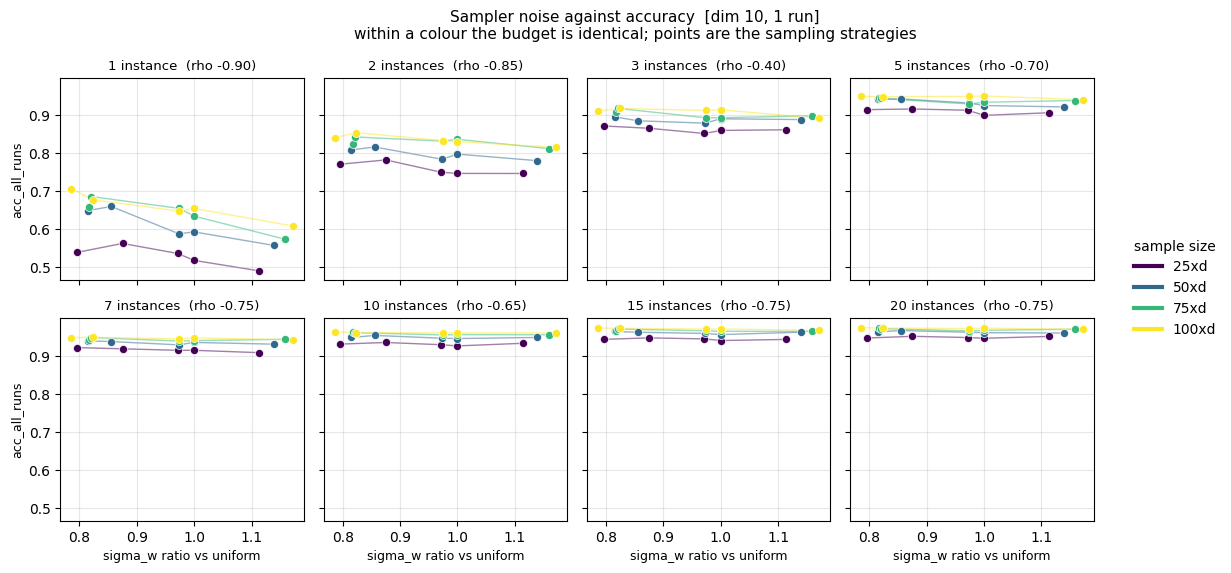

In [78]:
_ = cp.plot_noise_vs_accuracy(df, r_all, dimension=10, n_runs_train=1)


Text(921.7369281045751, 0.5, 'Accuracy spread')

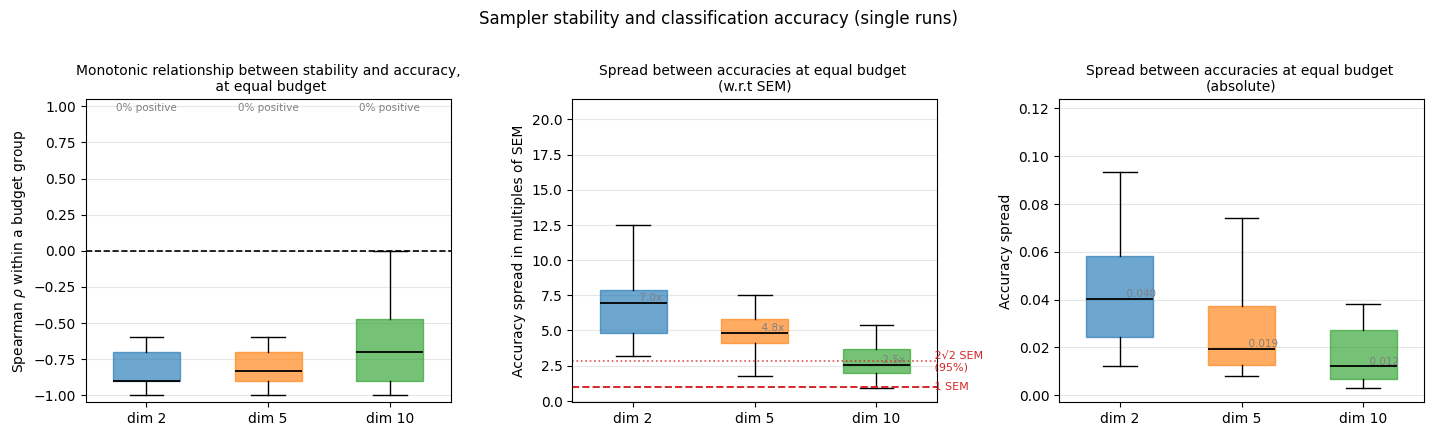

In [79]:
import matplotlib.pyplot as plt
f, ax = cp.plot_noise_accuracy_summary(df, r_all, n_runs_train=1,
                                       title="Sampler stability and classification accuracy (single runs)", scale="sem", show_absolute=True)
ax[0].set_title("Monotonic relationship between stability and accuracy,\n at equal budget", fontsize=10)
ax[0].set_ylabel(r"Spearman $\rho$ within a budget group")
ax[1].set_title("Spread between accuracies at equal budget \n(w.r.t SEM)", fontsize=10)
ax[1].set_ylabel("Accuracy spread in multiples of SEM")
ax[2].set_title("Spread between accuracies at equal budget \n(absolute)", fontsize=10)
ax[2].set_ylabel("Accuracy spread")

In [80]:
_, summ = cp.noise_vs_accuracy(df, r_all, 2, verbose=False)
summ = summ[summ.n_runs_train == 1]
summ["budget"] = 24 * summ.n_instances_train * summ.n_runs_train * summ["size"] * 2
print(summ.sort_values("budget")[["budget","rho","acc_spread"]].to_string(index=False))

 budget  rho  acc_spread
   1200 -0.9    0.081576
   2400 -1.0    0.055420
   2400 -0.7    0.117969
   3600 -1.0    0.072073
   3600 -0.9    0.093288
   4800 -0.7    0.078813
   4800 -1.0    0.076642
   6000 -1.0    0.061604
   7200 -0.9    0.057059
   7200 -1.0    0.039323
   8400 -0.9    0.068271
   9600 -0.9    0.049146
  10800 -0.6    0.041340
  12000 -0.9    0.051031
  12000 -0.9    0.034330
  14400 -0.6    0.032333
  16800 -0.9    0.041986
  18000 -0.9    0.030146
  18000 -0.9    0.047806
  24000 -0.9    0.044017
  24000 -0.7    0.031458
  24000 -0.7    0.031069
  25200 -0.7    0.031854
  33600 -0.6    0.022243
  36000 -0.7    0.024938
  36000 -0.8    0.016656
  48000 -0.7    0.017691
  48000 -0.7    0.023326
  54000 -0.7    0.020010
  72000 -0.9    0.015083
  72000 -0.7    0.018056
  96000 -0.6    0.012253


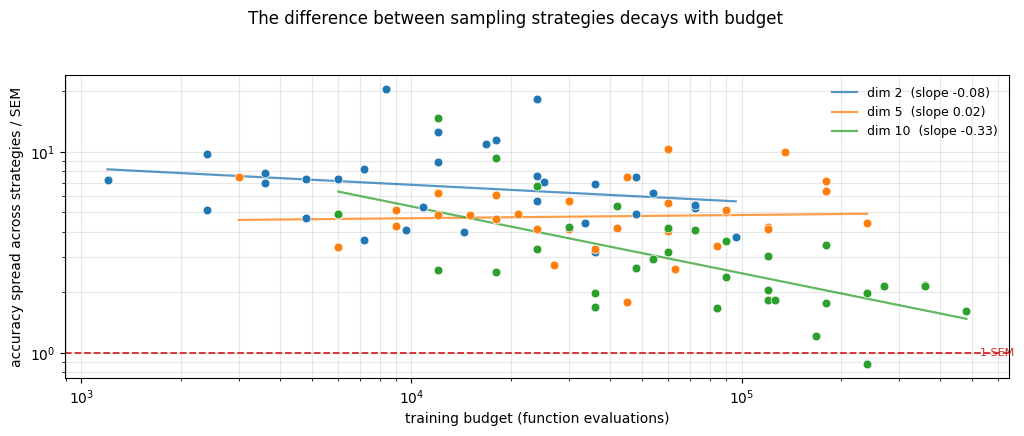

In [81]:
f, ax = cp.plot_spread_vs_budget(df, r_all, n_runs_train=1, scale="sem", show_rho=False)


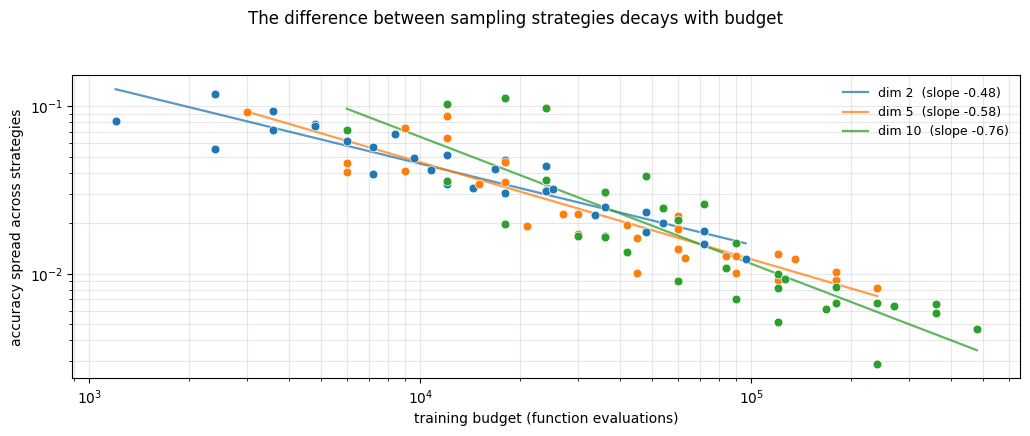

In [82]:
_ = cp.plot_spread_vs_budget(df, r_all, n_runs_train=1, normalise=False, show_rho=False)

Text(0.5, 14.52222222222222, 'Training budget (function evaluations)')

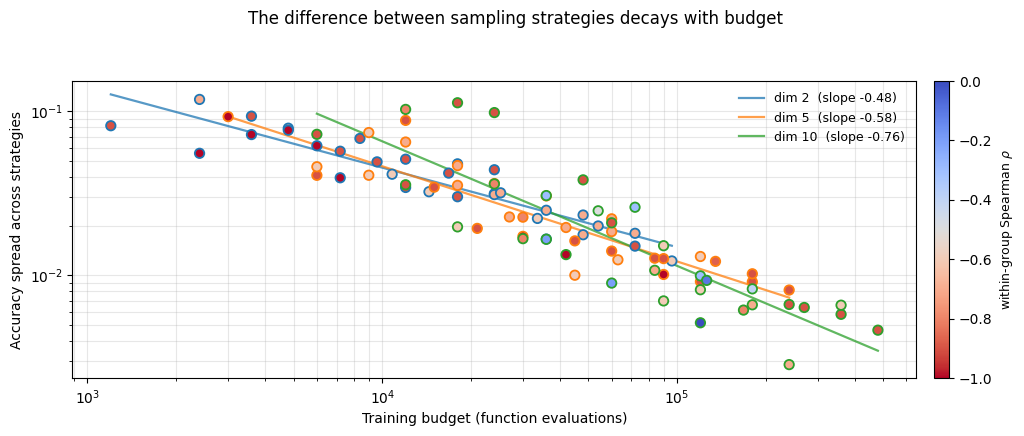

In [83]:
f, ax = cp.plot_spread_vs_budget(
    df, r_all,
    n_runs_train=1,
    normalise=False,
    show_rho=True,
    title="The difference between sampling strategies decays with budget")

ax.set_ylabel("Accuracy spread across strategies")
ax.set_xlabel("Training budget (function evaluations)")

In [84]:
import numpy as np, pandas as pd

dsem = cp.add_sem(df)
keys = ["dimension", "size", "n_instances_train", "n_runs_train"]
gsem = (dsem[dsem.strategy != "cma_random"]
        .groupby(keys)["sem_all_runs"].median().rename("sem").reset_index())

rows = []
for d in (2, 5, 10):
    _, s = cp.noise_vs_accuracy(df, r_all, d, verbose=False)
    s["dimension"] = d
    rows.append(s)
S = (pd.concat(rows, ignore_index=True)
     # .query("n_runs_train == 1")
     .merge(gsem, on=keys, how="left"))
S["spread_in_sem"] = S["acc_spread"] / S["sem"]

print(S.groupby("dimension")[["rho", "acc_spread", "spread_in_sem"]]
      .median().round(3).to_string())
print("\n% of groups with rho > 0:")
print((S.groupby("dimension")["rho"].apply(lambda x: (x > 0).mean() * 100)).round(1).to_string())

            rho  acc_spread  spread_in_sem
dimension                                 
2         -0.80       0.020          3.971
5         -0.80       0.011          4.023
10        -0.05       0.007          1.415

% of groups with rho > 0:
dimension
2      5.5
5      3.1
10    42.2


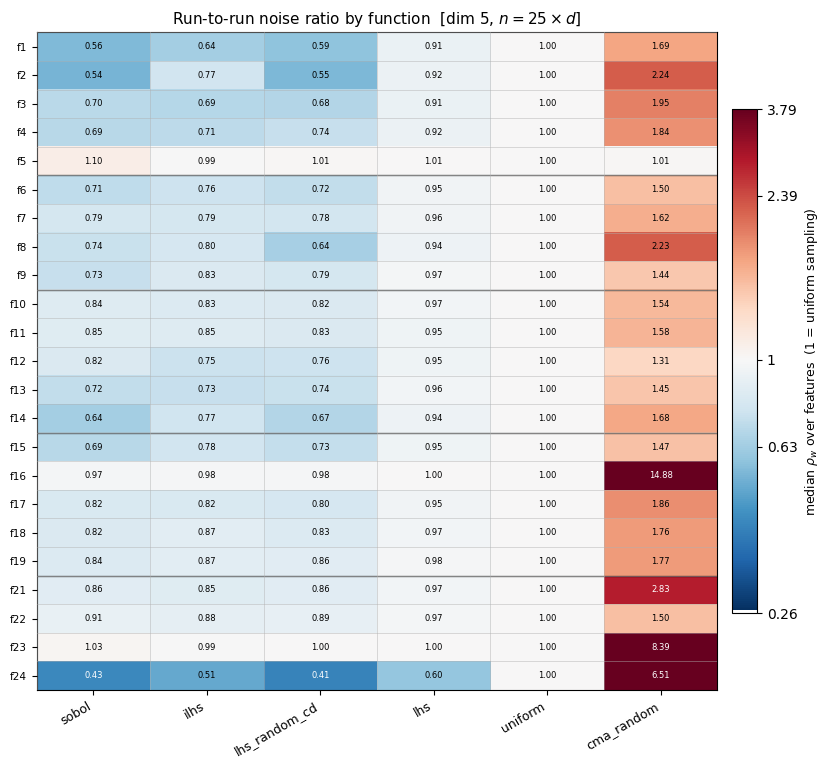

In [85]:
_ = ia.heatmap_ratio_w_by_function(r_all, dimension=5, size=25)

In [86]:
import numpy as np, pandas as pd

dsem = cp.add_sem(df)
keys = ["dimension", "size", "n_instances_train", "n_runs_train"]
gsem = (dsem[dsem.strategy != "cma_random"]
        .groupby(keys)["sem_all_runs"].median().rename("sem").reset_index())

rows = []
for d in (2, 5, 10):
    _, s = cp.noise_vs_accuracy(df, r_all, d, verbose=False)
    s["dimension"] = d
    rows.append(s)

S = (pd.concat(rows, ignore_index=True)
     .query("n_runs_train == 1")
     .merge(gsem, on=keys, how="left"))
S["spread_in_sem"] = S["acc_spread"] / S["sem"]
S["budget"] = (24 * S["n_instances_train"] * S["n_runs_train"]
               * S["size"] * S["dimension"])

for d in (2, 5, 10):
    g = S[S.dimension == d]
    lx = np.log10(g["budget"])
    raw  = np.polyfit(lx, np.log10(g["acc_spread"]), 1)[0]
    sem  = np.polyfit(lx, np.log10(g["sem"]), 1)[0]
    norm = np.polyfit(lx, np.log10(g["spread_in_sem"]), 1)[0]
    print(f"dim {d:>2}: raw {raw:+.2f}  sem {sem:+.2f}  normalised {norm:+.2f}"
          f"  (raw-sem = {raw-sem:+.2f})")

dim  2: raw -0.48  sem -0.40  normalised -0.08  (raw-sem = -0.08)
dim  5: raw -0.58  sem -0.60  normalised +0.02  (raw-sem = +0.02)
dim 10: raw -0.76  sem -0.43  normalised -0.33  (raw-sem = -0.33)


In [87]:
MAX = {d: f"/Users/leekaijen/t7ssd/featELA/dim{d}featELA/max/ela_classification_subsample_modified.h5"
       for d in (2, 5, 10)}
out, pivot = cp.ceiling_table(MAX)


dim 2 — maximum attainable (20 inst x 30 runs @ 100xd, 2,880,000 fevals)

strategy              acc  +/- fold  consistency
lhs                0.9198    0.0037       0.9198
lhs_random_cd      0.9193    0.0077       0.9193
uniform            0.9182    0.0032       0.9182
sobol              0.9168    0.0076       0.9168
ilhs               0.9148    0.0070       0.9148
cma_random         0.8397    0.0016       0.8397
  space-filling spread: 0.0050 (max fold sd 0.0077)

dim 5 — maximum attainable (20 inst x 30 runs @ 100xd, 7,200,000 fevals)

strategy              acc  +/- fold  consistency
ilhs               0.9756    0.0024       0.9756
uniform            0.9709    0.0031       0.9709
sobol              0.9704    0.0035       0.9704
lhs                0.9702    0.0033       0.9702
lhs_random_cd      0.9692    0.0043       0.9692
cma_random         0.9368    0.0008       0.9368
  space-filling spread: 0.0064 (max fold sd 0.0043)

dim 10 — maximum attainable (20 inst x 30 runs @ 100xd, 14,

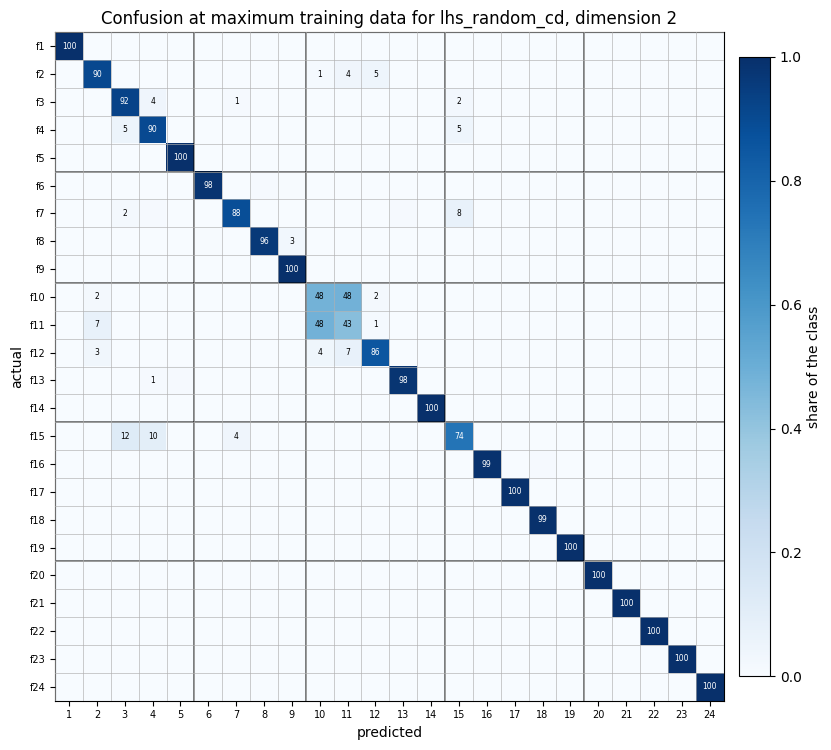

In [88]:
f, ax = cp.plot_confusion(MAX[2], "sobol_100",
                          n_inst=20, n_runs=30,
                          protocol="all_runs",
                          title="Confusion at maximum training data for lhs_random_cd, dimension 2")

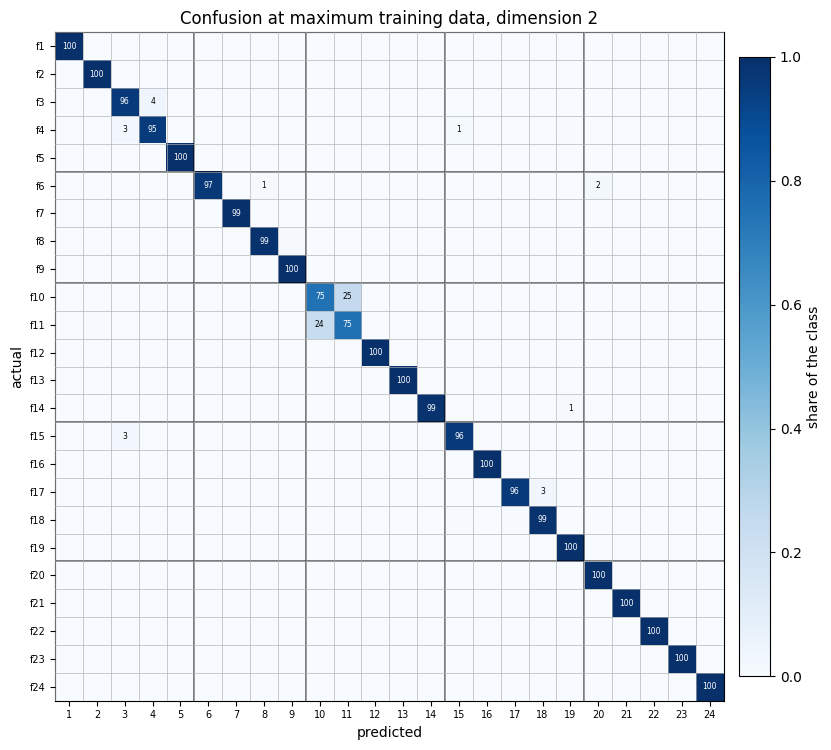

In [89]:
f, ax = cp.plot_confusion(MAX[5], "lhs_random_cd_100",
                          n_inst=20, n_runs=30,
                          protocol="all_runs",
                          title="Confusion at maximum training data, dimension 2")

In [90]:
import h5py
with h5py.File(MAX[2]) as h:
    print(list(h.keys()))                    # config names
    print(list(h["lhs_random_cd_100"]))      # subkeys — expect inst_20_runs_30

['cma_random_100', 'ilhs_100', 'lhs_100', 'lhs_random_cd_100', 'sobol_100', 'uniform_100']
['inst_20_runs_30', 'kept_feature_groups', 'kept_features', 'omitted_features']


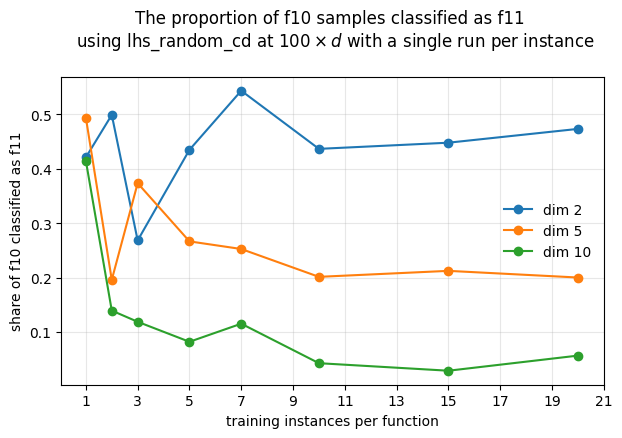

In [91]:
import numpy as np, matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
for dim, path in PATHS.items():
    xs, ys = [], []
    for ni in (1, 2, 3, 5, 7, 10, 15, 20):
        p = cp.load_predictions(path, "lhs_random_cd_100", ni, 5)
        y, pr = p["true_labels"], p["pred_runs"]
        yr, pred = np.repeat(y, pr.shape[1]), pr.ravel()
        m = yr == 9
        xs.append(ni); ys.append((pred[m] == 10).mean())
    ax.plot(xs, ys, marker="o", label=f"dim {dim}")
ax.set_title("The proportion of f10 samples classified as f11 \n using lhs_random_cd at " r"$100 \times d$ with a single run per instance""\n")
ax.set_xlabel("training instances per function")
ax.set_ylabel("share of f10 classified as f11")
ax.set_xticks(np.arange(1, 22, 2))
ax.legend(frameon=False); ax.grid(alpha=0.3)

Text(0.5, 0.98, 'Accuracy against budget for every allocation of each sampling strategy at Dimension 2\n')

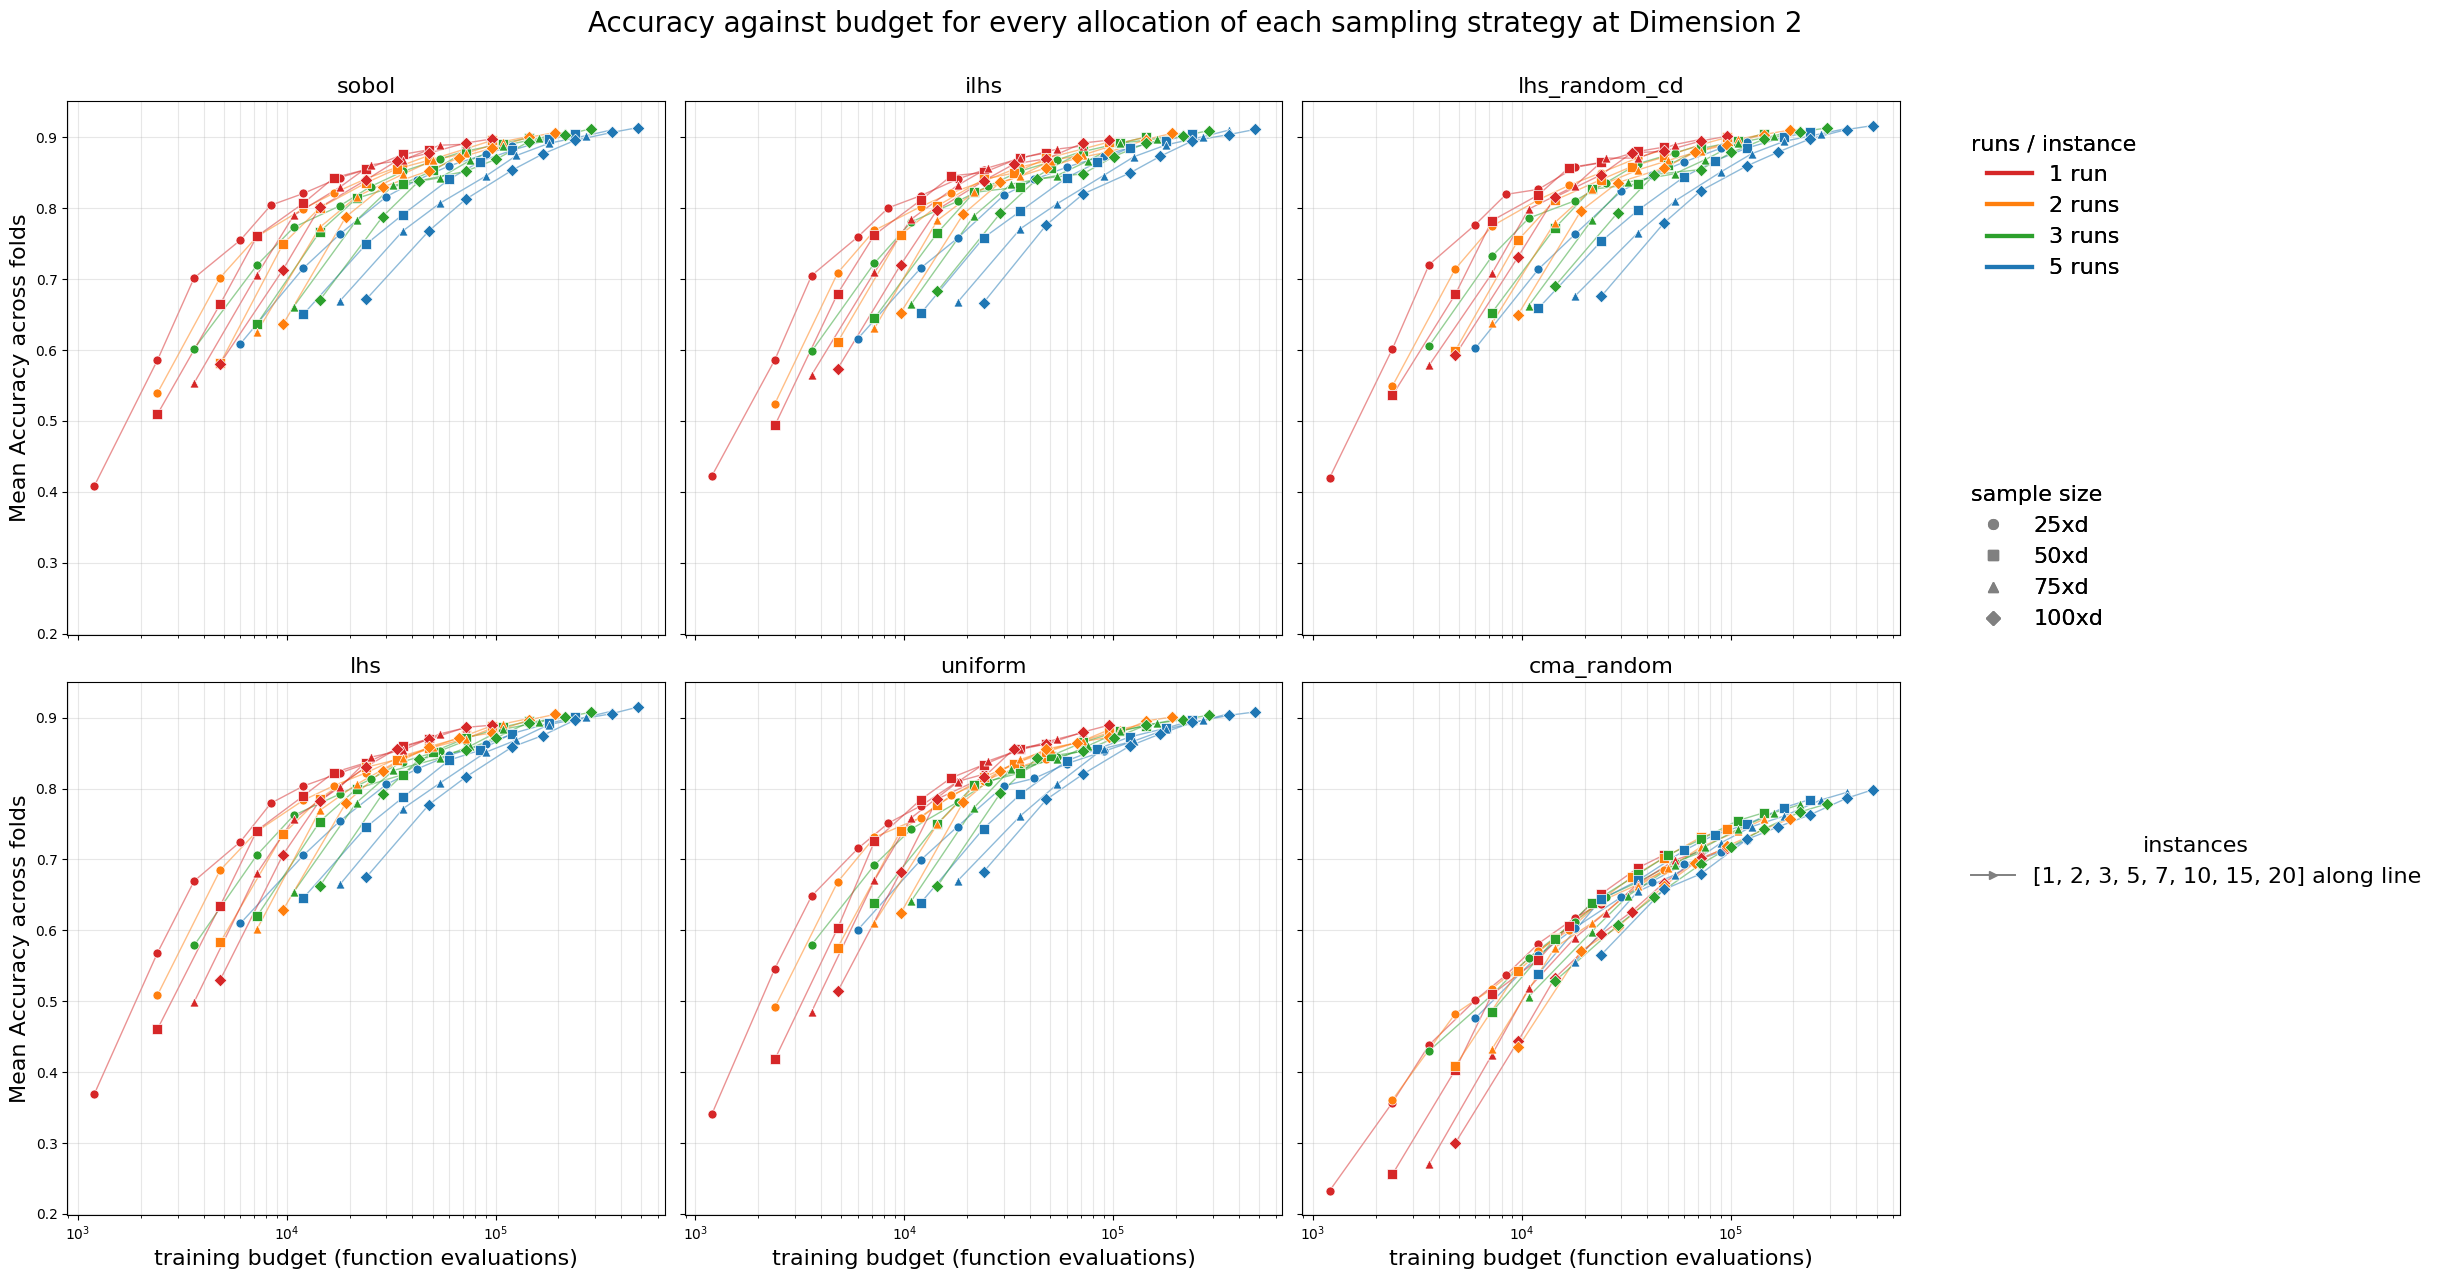

In [92]:
f, r = cp.plot_allocation_scatter(df, 2, logx=True, width_per=8, height_per=6.5, ncols=3)        # C10 — within sampler

f.suptitle("Accuracy against budget for every allocation of each sampling strategy at Dimension 2\n", fontsize=20)


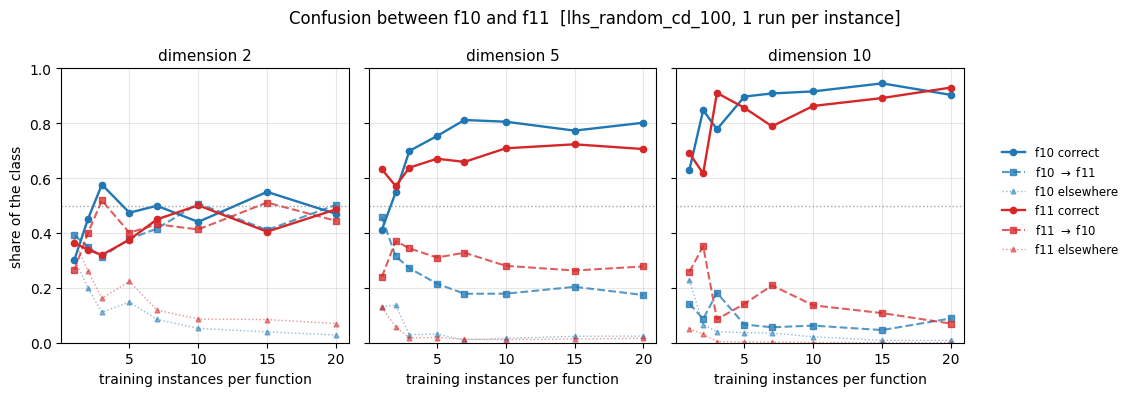

In [93]:
f, ax = cp.plot_confusion_pair_grid(PATHS, config_key="lhs_random_cd_100",
                                    a=10, b=11, n_runs=1)

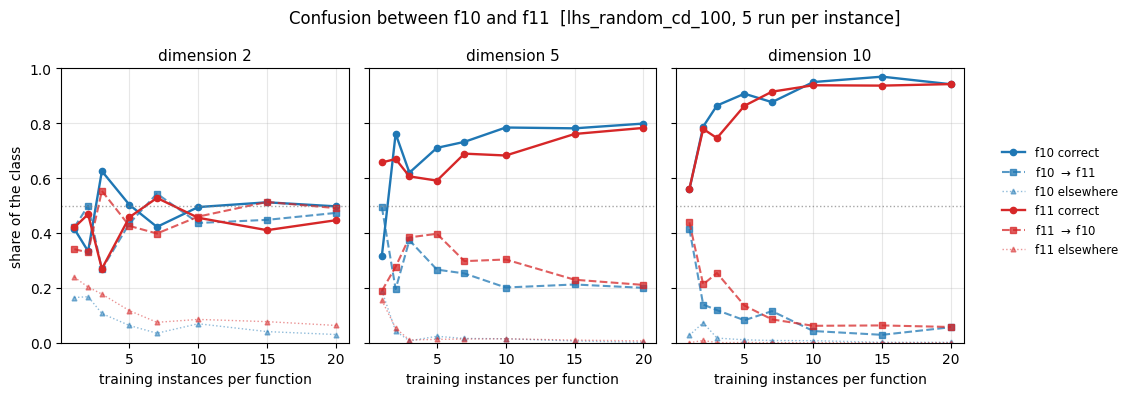

In [94]:
f, ax = cp.plot_confusion_pair_grid(PATHS, config_key="lhs_random_cd_100",
                                    a=10, b=11, n_runs=5)

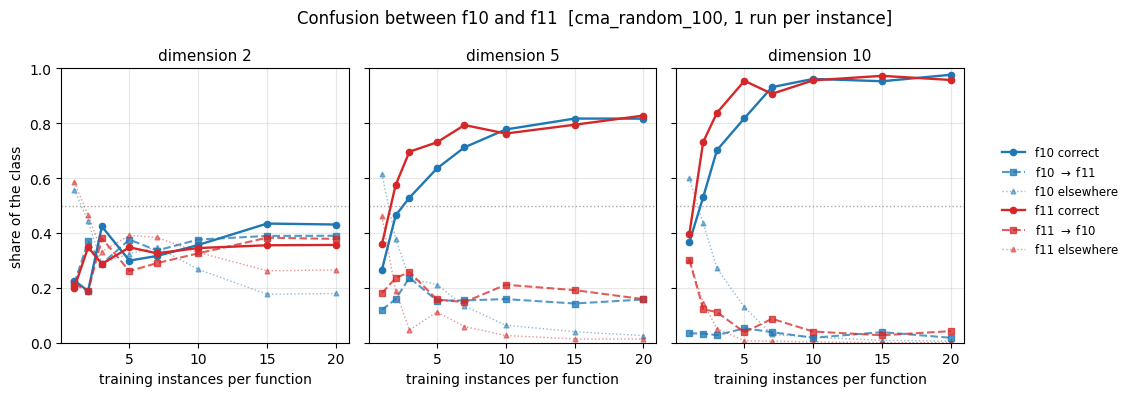

In [95]:
f, ax = cp.plot_confusion_pair_grid(PATHS, config_key="cma_random_100",
                                    a=10, b=11, n_runs=1)

In [96]:
d = df.query("dimension == 5 and strategy != 'cma_random'").copy()
d["tier"] = pd.qcut(np.log10(d.n_feval_train), 4,
                    labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (most expensive)"])
for t, g in d.groupby("tier", observed=True):
    print(f"\n{t}  ({len(g)} settings, {g.n_feval_train.min():,}–{g.n_feval_train.max():,} fevals)")
    cp.factor_importance(g, dimension=5, control_budget=True)


Q1 (cheapest)  (180 settings, 3,000–36,000 fevals)
Variance in acc_all_runs explained (dim 5, 180 grid points)
factor                       raw   budget-controlled   levels
strategy                   1.1%               3.1%        5
size                       0.9%              37.4%        4
n_instances_train         56.8%              51.7%        6
n_runs_train               2.5%               4.1%        4
_residual                 38.7%               3.7%

  raw        = includes total budget, so the wide-range factors dominate
  controlled = log(budget) regressed out, so this is the ALLOCATION effect

Q2  (170 settings, 42,000–90,000 fevals)
Variance in acc_all_runs explained (dim 5, 170 grid points)
factor                       raw   budget-controlled   levels
strategy                   2.1%               2.5%        5
size                       5.5%               7.9%        4
n_instances_train         84.8%              83.5%        8
n_runs_train              60.6%           

In [97]:
d = df.query("dimension == 5 and strategy != 'cma_random'").copy()
cp.factor_importance(d, dimension=5, control_budget=True)

Variance in acc_all_runs explained (dim 5, 640 grid points)
factor                       raw   budget-controlled   levels
strategy                   0.4%               1.3%        5
size                       4.4%               5.8%        4
n_instances_train         77.0%              43.7%        8
n_runs_train               5.7%              10.4%        4
_residual                 12.5%              38.8%

  raw        = includes total budget, so the wide-range factors dominate
  controlled = log(budget) regressed out, so this is the ALLOCATION effect


,factor,eta2_raw,eta2_budget_controlled,n_levels
0,strategy,0.004168,0.012978,5.0
1,size,0.044025,0.058255,4.0
2,n_instances_train,0.769680,0.436663,8.0
3,n_runs_train,0.057342,0.103615,4.0
4,_residual,0.124785,0.388490,NaN


In [98]:
FACT3 = ["size", "n_instances_train", "n_runs_train"]

for name, sub in [("space-filling", df[df.strategy != "cma_random"]),
                  ("cma_random",    df[df.strategy == "cma_random"])]:
    print(f"\n=== {name} ===")
    cp.factor_importance(sub, dimension=5, factors=FACT3)



=== space-filling ===
Variance in acc_all_runs explained (dim 5, 640 grid points)
factor                       raw   budget-controlled   levels
size                       4.4%               5.8%        4
n_instances_train         77.0%              43.7%        8
n_runs_train               5.7%              10.4%        4
_residual                 12.9%              40.1%

  raw        = includes total budget, so the wide-range factors dominate
  controlled = log(budget) regressed out, so this is the ALLOCATION effect

=== cma_random ===
Variance in acc_all_runs explained (dim 5, 128 grid points)
factor                       raw   budget-controlled   levels
size                      10.9%               2.5%        4
n_instances_train         60.0%              33.0%        8
n_runs_train              19.3%               3.2%        4
_residual                  9.8%              61.3%

  raw        = includes total budget, so the wide-range factors dominate
  controlled = log(budget) r

In [99]:
sub = df[df.strategy != "cma_random"]
t = cp.factor_importance_2way(sub, dimension=5)

Variance in acc_all_runs explained, budget-controlled (dim 5, 640 settings)
  budget term accounts for 67.9% of the variance; the shares below divide the remaining 32.1%

  main effects
    n_instances_train                   43.7%
    n_runs_train                        10.4%
    size                                 5.8%
    strategy                             1.3%

  two-way interactions
    n_instances_train x n_runs_train    33.3%
    size x n_instances_train             1.6%
    size x n_runs_train                  0.9%
    strategy x n_runs_train              0.4%
    strategy x n_instances_train         0.3%
    strategy x size                      0.1%

  3-way and higher, plus noise         2.1%


In [100]:
sub = df[df.strategy == "cma_random"]
t = cp.factor_importance_2way(sub, dimension=5, factors=FACT3)

Variance in acc_all_runs explained, budget-controlled (dim 5, 128 settings)
  budget term accounts for 83.9% of the variance; the shares below divide the remaining 16.1%

  main effects
    n_instances_train                   33.0%
    n_runs_train                         3.2%
    size                                 2.5%

  two-way interactions
    n_instances_train x n_runs_train    57.3%
    size x n_instances_train             2.6%
    size x n_runs_train                  0.6%

  3-way and higher, plus noise         0.8%


In [101]:
FACT3 = ["size", "n_instances_train", "n_runs_train"]
cp.factor_importance_2way(df[df.strategy != "cma_random"], 5, factors=FACT3)

Variance in acc_all_runs explained, budget-controlled (dim 5, 640 settings)
  budget term accounts for 67.9% of the variance; the shares below divide the remaining 32.1%

  main effects
    n_instances_train                   43.7%
    n_runs_train                        10.4%
    size                                 5.8%

  two-way interactions
    n_instances_train x n_runs_train    33.3%
    size x n_instances_train             1.6%
    size x n_runs_train                  0.9%

  3-way and higher, plus noise         4.2%


,term,kind,share
0,size,main,0.058255
1,n_instances_train,main,0.436663
2,n_runs_train,main,0.103615
3,size x n_instances_train,2-way,0.016498
4,size x n_runs_train,2-way,0.009348
5,n_instances_train x n_runs_train,2-way,0.333404
6,"3-way and higher, plus noise",residual,0.042217


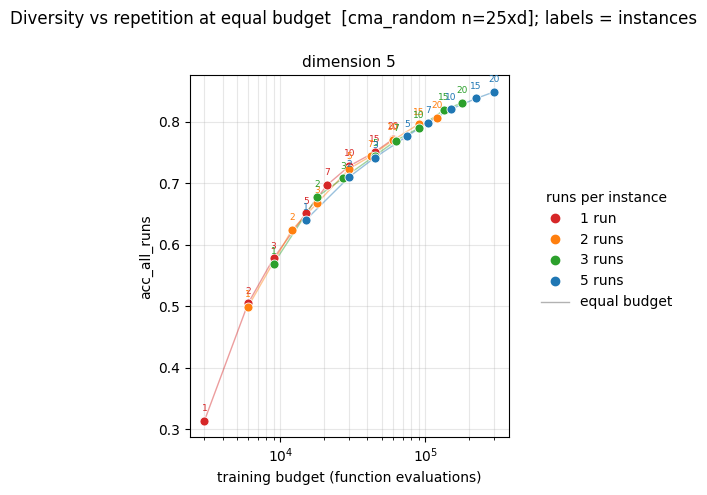

In [102]:
f, ax = cp.plot_instances_vs_runs_grid(df, dimensions=(5,),
                                       strategy="cma_random", size=25)

In [103]:
for dim in (2, 5, 10):
    sub = df.query("dimension == @dim and strategy != 'cma_random'")
    x, y = np.log(sub.n_feval_train), sub.acc_all_runs
    lin  = np.corrcoef(x, y)[0, 1] ** 2
    quad = 1 - np.sum((y - np.polyval(np.polyfit(x, y, 2), x))**2) / np.sum((y - y.mean())**2)
    print(f"dim {dim:>2}: linear R² {lin:.3f}   quadratic {quad:.3f}   "
          f"curvature adds {quad-lin:.3f}")

dim  2: linear R² 0.746   quadratic 0.842   curvature adds 0.096
dim  5: linear R² 0.679   quadratic 0.820   curvature adds 0.141
dim 10: linear R² 0.626   quadratic 0.798   curvature adds 0.171


In [104]:
x, y = np.log(sub.n_feval_train), sub.acc_all_runs
lin  = np.corrcoef(x, y)[0,1]**2
quad = 1 - np.sum((y - np.polyval(np.polyfit(x, y, 2), x))**2) / np.sum((y - y.mean())**2)
print(f"linear R² {lin:.3f}   quadratic R² {quad:.3f}   curvature adds {quad-lin:.3f}")

linear R² 0.626   quadratic R² 0.798   curvature adds 0.171


In [105]:
sub = df[df.strategy != "cma_random"]

for deg in (1, 2):
    print(f"--- budget term of degree {deg} ---")
    cp.factor_importance_2way(sub, dimension=5, budget_degree=deg)
    print()

--- budget term of degree 1 ---
Variance in acc_all_runs explained, budget-controlled (dim 5, 640 settings)
  budget term accounts for 67.9% of the variance; the shares below divide the remaining 32.1%

  main effects
    n_instances_train                   43.7%
    n_runs_train                        10.4%
    size                                 5.8%
    strategy                             1.3%

  two-way interactions
    n_instances_train x n_runs_train    33.3%
    size x n_instances_train             1.6%
    size x n_runs_train                  0.9%
    strategy x n_runs_train              0.4%
    strategy x n_instances_train         0.3%
    strategy x size                      0.1%

  3-way and higher, plus noise         2.1%

--- budget term of degree 2 ---
Variance in acc_all_runs explained, budget-controlled, degree 2 (dim 5, 640 settings)
  budget term accounts for 82.0% of the variance; the shares below divide the remaining 18.0%

  main effects
    n_instances_train   

In [106]:
for dim in (2, 5, 10):
    print(f"--- dim {dim} ---")
    cp.factor_importance_2way(df[df.strategy != "cma_random"], dimension=dim)
    print()

--- dim 2 ---
Variance in acc_all_runs explained, budget-controlled (dim 2, 640 settings)
  budget term accounts for 74.6% of the variance; the shares below divide the remaining 25.4%

  main effects
    n_instances_train                   50.5%
    n_runs_train                        19.9%
    size                                 5.7%
    strategy                             2.9%

  two-way interactions
    n_instances_train x n_runs_train    13.5%
    size x n_instances_train             2.9%
    size x n_runs_train                  1.5%
    strategy x n_runs_train              0.8%
    strategy x size                      0.6%
    strategy x n_instances_train         0.3%

  3-way and higher, plus noise         1.5%

--- dim 5 ---
Variance in acc_all_runs explained, budget-controlled (dim 5, 640 settings)
  budget term accounts for 67.9% of the variance; the shares below divide the remaining 32.1%

  main effects
    n_instances_train                   43.7%
    n_runs_train        

In [107]:
cp.factor_importance_2way(
    df.query("n_instances_train <= 3 and strategy != 'cma_random'"), dimension=5)

Variance in acc_all_runs explained, budget-controlled (dim 5, 240 settings)
  budget term accounts for 66.1% of the variance; the shares below divide the remaining 33.9%

  main effects
    n_instances_train                   34.2%
    size                                12.9%
    n_runs_train                         8.9%
    strategy                             2.3%

  two-way interactions
    n_instances_train x n_runs_train    33.9%
    size x n_runs_train                  2.9%
    strategy x n_runs_train              1.4%
    size x n_instances_train             1.0%
    strategy x n_instances_train         0.2%
    strategy x size                      0.1%

  3-way and higher, plus noise         2.4%


,term,kind,share
0,strategy,main,0.022575
1,size,main,0.128507
2,n_instances_train,main,0.342140
3,n_runs_train,main,0.088705
4,strategy x size,2-way,0.000680
5,strategy x n_instances_train,2-way,0.001724
6,strategy x n_runs_train,2-way,0.014094
7,size x n_instances_train,2-way,0.009704
8,size x n_runs_train,2-way,0.029297
9,n_instances_train x n_runs_train,2-way,0.338650


In [108]:
for dim in (2, 5, 10):
    print(f"--- dim {dim}, instances <= 3 ---")
    cp.factor_importance_2way(
        df.query("n_instances_train <= 3 and strategy != 'cma_random'"),
        dimension=dim)
    print()

--- dim 2, instances <= 3 ---
Variance in acc_all_runs explained, budget-controlled (dim 2, 240 settings)
  budget term accounts for 69.4% of the variance; the shares below divide the remaining 30.6%

  main effects
    n_instances_train                   49.7%
    n_runs_train                        21.6%
    size                                 6.0%
    strategy                             4.0%

  two-way interactions
    n_instances_train x n_runs_train    10.6%
    size x n_runs_train                  3.3%
    strategy x n_runs_train              2.1%
    size x n_instances_train             0.7%
    strategy x size                      0.4%
    strategy x n_instances_train         0.2%

  3-way and higher, plus noise         1.4%

--- dim 5, instances <= 3 ---
Variance in acc_all_runs explained, budget-controlled (dim 5, 240 settings)
  budget term accounts for 66.1% of the variance; the shares below divide the remaining 33.9%

  main effects
    n_instances_train                 

In [109]:
import numpy as np, pandas as pd

for ni in (1, 3, 5, 20):
    d = df.query("dimension == 5 and strategy == 'lhs_random_cd' "
                 "and n_instances_train == @ni")
    print(f"\n--- {ni} instance(s), dim 5 ---")
    for b, g in d.groupby("n_feval_train"):
        if len(g) > 1:
            g = g.sort_values("n_runs_train")
            desc = "  vs  ".join(f"{int(r.n_runs_train)}run@{int(r['size'])}xd "
                                 f"{r.acc_all_runs:.3f}" for _, r in g.iterrows())
            spread = g.acc_all_runs.max() - g.acc_all_runs.min()
            print(f"  {int(b):>8,}: {desc}   (spread {spread:.3f})")


--- 1 instance(s), dim 5 ---
     6,000: 1run@50xd 0.573  vs  2run@25xd 0.668   (spread 0.095)
     9,000: 1run@75xd 0.642  vs  3run@25xd 0.757   (spread 0.115)
    12,000: 1run@100xd 0.647  vs  2run@50xd 0.724   (spread 0.076)
    18,000: 2run@75xd 0.726  vs  3run@50xd 0.778   (spread 0.052)

--- 3 instance(s), dim 5 ---
    18,000: 1run@50xd 0.864  vs  2run@25xd 0.854   (spread 0.011)
    27,000: 1run@75xd 0.880  vs  3run@25xd 0.865   (spread 0.015)
    36,000: 1run@100xd 0.890  vs  2run@50xd 0.884   (spread 0.005)
    54,000: 2run@75xd 0.898  vs  3run@50xd 0.887   (spread 0.011)

--- 5 instance(s), dim 5 ---
    30,000: 1run@50xd 0.897  vs  2run@25xd 0.893   (spread 0.004)
    45,000: 1run@75xd 0.916  vs  3run@25xd 0.887   (spread 0.029)
    60,000: 1run@100xd 0.929  vs  2run@50xd 0.919   (spread 0.010)
    90,000: 2run@75xd 0.932  vs  3run@50xd 0.906   (spread 0.026)

--- 20 instance(s), dim 5 ---
   120,000: 1run@50xd 0.948  vs  2run@25xd 0.940   (spread 0.008)
   180,000: 1run@7